<a href="https://colab.research.google.com/github/naminipla1920-ui/Private/blob/main/Copia_de_AI_transportation_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Data Loading and Initial Inspection**

## 1.1 January Sample and Dataset Structure

In [ ]:
import pandas as pd

columns_needed = [
    "date",
    "LineNumber",
    "route_id",
    "TransportMode",
    "direction_id",
    "trip_id",
    "VehicleID",
    "stop_sequence",
    "dist_traveled",
    "observed_stop_id",
    "observed_StopAreaID",
    "scheduled_arrival_time_sfm",
    "observed_arrival_time_sfm",
    "observed_arrival_delay",
    "scheduled_departure_time_sfm",
    "observed_departure_time_sfm",
    "observed_departure_delay"
]

df = pd.read_csv(
    "gtfs_rt_202401.csv.gz",
    sep=";",
    compression="gzip",
    usecols=columns_needed
)

print(df.shape)
display(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'gtfs_rt_202401.csv.gz'

In [ ]:
# Dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Date coverage
print("First date:", df["date"].min())
print("Last date:", df["date"].max())

# Data types
df.info()

## 1.2 Missing-Value Inspection

In [ ]:
missing = pd.DataFrame({
    "Missing": df.isna().sum(),
    "Missing_%": (df.isna().mean() * 100).round(2)
})

display(missing.sort_values("Missing_%", ascending=False))

In [ ]:
arrival_missing_match = (
    df["observed_arrival_time_sfm"].isna()
    == df["observed_arrival_delay"].isna()
).mean()

departure_missing_match = (
    df["observed_departure_time_sfm"].isna()
    == df["observed_departure_delay"].isna()
).mean()

print(f"Arrival missingness matches: {arrival_missing_match:.2%}")
print(f"Departure missingness matches: {departure_missing_match:.2%}")

# **2. Full-Year Descriptive Analysis**

## 2.1 Full-Year Processing

In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount("/content/drive")

# Existing project folder in My Drive
PROJECT_PATH = "/content/drive/MyDrive/Project AI in Transportation"

# Create folders for project outputs
MONTHLY_PATH = f"{PROJECT_PATH}/descriptive_results/monthly"
TABLE_PATH = f"{PROJECT_PATH}/descriptive_results/tables"
PLOT_PATH = f"{PROJECT_PATH}/descriptive_results/plots"
MODEL_PATH = f"{PROJECT_PATH}/models"

os.makedirs(MONTHLY_PATH, exist_ok=True)
os.makedirs(TABLE_PATH, exist_ok=True)
os.makedirs(PLOT_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

print("Project folders created successfully.")
print("Monthly summaries:", MONTHLY_PATH)
print("Final tables:", TABLE_PATH)
print("Plots:", PLOT_PATH)
print("Models:", MODEL_PATH)

Mounted at /content/drive
Project folders created successfully.
Monthly summaries: /content/drive/MyDrive/Project AI in Transportation/descriptive_results/monthly
Final tables: /content/drive/MyDrive/Project AI in Transportation/descriptive_results/tables
Plots: /content/drive/MyDrive/Project AI in Transportation/descriptive_results/plots
Models: /content/drive/MyDrive/Project AI in Transportation/models


In [ ]:
# FULL-YEAR DESCRIPTIVE ANALYSIS SETUP

import pandas as pd
import numpy as np
import gc
import os

# Monthly raw GTFS-RT files stored in Colab
files = [
    f"/content/gtfs_rt_2024{month:02d}.csv.gz"
    for month in range(1, 13)
]

# Columns required for descriptive analysis
columns_needed = [
    "date",
    "LineNumber",
    "route_id",
    "TransportMode",
    "trip_id",
    "VehicleID",
    "observed_stop_id",
    "observed_StopAreaID",
    "scheduled_arrival_time_sfm",
    "observed_arrival_delay",
    "observed_departure_delay"
]

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

print("Setup complete.")

# Check which monthly files Colab can see
for file in files:
    status = "FOUND" if os.path.exists(file) else "MISSING"
    print(status, os.path.basename(file))

Setup complete.
MISSING gtfs_rt_202401.csv.gz
MISSING gtfs_rt_202402.csv.gz
MISSING gtfs_rt_202403.csv.gz
MISSING gtfs_rt_202404.csv.gz
MISSING gtfs_rt_202405.csv.gz
MISSING gtfs_rt_202406.csv.gz
MISSING gtfs_rt_202407.csv.gz
MISSING gtfs_rt_202408.csv.gz
MISSING gtfs_rt_202409.csv.gz
MISSING gtfs_rt_202410.csv.gz
MISSING gtfs_rt_202411.csv.gz
MISSING gtfs_rt_202412.csv.gz


In [ ]:
# Process all months sequentially

for month_number, file in enumerate(files, start=1):

    month_name = pd.Timestamp(
        year=2024,
        month=month_number,
        day=1
    ).strftime("%B")

    print(f"\nProcessing {month_name} ({month_number:02d}/12)")

    # Check source file

    if not os.path.exists(file):
        print(f"File not found: {file}")
        print("Skipping this month.")
        continue

    # Create folder for this month's results

    month_folder = f"{MONTHLY_PATH}/{month_number:02d}_{month_name}"
    os.makedirs(month_folder, exist_ok=True)

    completion_file = f"{month_folder}/COMPLETED.txt"

    # Skip month if already successfully processed

    if os.path.exists(completion_file):
        print(f"{month_name} already processed. Skipping.")
        continue

    # Load one month

    df_month = pd.read_csv(
        file,
        sep=";",
        compression="gzip",
        usecols=columns_needed
    )

    print(f"Loaded {len(df_month):,} rows")

    # Feature creation

    df_month["arrival_delay_min"] = (
        df_month["observed_arrival_delay"] / 60
    )

    df_month["departure_delay_min"] = (
        df_month["observed_departure_delay"] / 60
    )

    df_month["date_dt"] = pd.to_datetime(
        df_month["date"].astype(str),
        format="%Y%m%d",
        errors="coerce"
    )

    df_month["weekday"] = (
        df_month["date_dt"].dt.day_name()
    )

    df_month["scheduled_hour"] = (
        df_month["scheduled_arrival_time_sfm"] // 3600
    )

    df_month["scheduled_hour_clock"] = (
        df_month["scheduled_hour"] % 24
    )

    # Overall monthly summary

    delay = df_month["arrival_delay_min"].dropna()

    monthly_summary = pd.DataFrame([{
        "month": month_number,
        "month_name": month_name,
        "total_rows": len(df_month),
        "valid_delay_observations": delay.count(),
        "mean_delay": delay.mean(),
        "median_delay": delay.median(),
        "std_delay": delay.std(),
        "p90_delay": delay.quantile(0.90),
        "p95_delay": delay.quantile(0.95),
        "p99_delay": delay.quantile(0.99),
        "min_delay": delay.min(),
        "max_delay": delay.max()
    }])

    # Transport mode delay summary

    mode_summary = (
        df_month
        .groupby("TransportMode")["arrival_delay_min"]
        .agg(
            observations="count",
            mean="mean",
            median="median",
            std="std"
        )
        .reset_index()
    )

    mode_percentiles = (
        df_month
        .groupby("TransportMode")["arrival_delay_min"]
        .quantile([0.90, 0.95, 0.99])
        .unstack()
        .reset_index()
        .rename(columns={
            0.90: "p90",
            0.95: "p95",
            0.99: "p99"
        })
    )

    mode_summary = mode_summary.merge(
        mode_percentiles,
        on="TransportMode"
    )

    mode_summary["month"] = month_number

    # Transport mode composition using all rows

    mode_composition = (
        df_month["TransportMode"]
        .value_counts(dropna=False)
        .rename_axis("TransportMode")
        .reset_index(name="total_rows")
    )

    mode_composition["percentage"] = (
        100
        * mode_composition["total_rows"]
        / len(df_month)
    )

    mode_composition["month"] = month_number
    mode_composition["month_name"] = month_name

    # Hourly summary

    hourly_summary = (
        df_month
        .groupby("scheduled_hour_clock")["arrival_delay_min"]
        .agg(
            observations="count",
            mean="mean",
            median="median"
        )
        .reset_index()
    )

    hourly_summary["month"] = month_number

    # Weekday summary

    weekday_summary = (
        df_month
        .groupby("weekday")["arrival_delay_min"]
        .agg(
            observations="count",
            mean="mean",
            median="median"
        )
        .reset_index()
    )

    weekday_summary["month"] = month_number

    # Transport mode by hour

    mode_hour_summary = (
        df_month
        .groupby(
            ["TransportMode", "scheduled_hour_clock"]
        )["arrival_delay_min"]
        .agg(
            observations="count",
            mean="mean",
            median="median"
        )
        .reset_index()
    )

    mode_hour_summary["month"] = month_number

    # Transport mode by weekday

    mode_weekday_summary = (
        df_month
        .groupby(
            ["TransportMode", "weekday"]
        )["arrival_delay_min"]
        .agg(
            observations="count",
            mean="mean",
            median="median"
        )
        .reset_index()
    )

    mode_weekday_summary["month"] = month_number

    # Route summary

    route_summary = (
        df_month
        .groupby(
            ["TransportMode", "route_id"]
        )["arrival_delay_min"]
        .agg(
            observations="count",
            mean="mean",
            median="median",
            std="std"
        )
        .reset_index()
    )

    route_p95 = (
        df_month
        .groupby(
            ["TransportMode", "route_id"]
        )["arrival_delay_min"]
        .quantile(0.95)
        .reset_index(name="p95")
    )

    route_summary = route_summary.merge(
        route_p95,
        on=["TransportMode", "route_id"]
    )

    route_summary["month"] = month_number

    # Stop summary

    stop_summary = (
        df_month
        .groupby(
            ["TransportMode", "observed_StopAreaID"]
        )["arrival_delay_min"]
        .agg(
            observations="count",
            mean="mean",
            median="median",
            std="std"
        )
        .reset_index()
    )

    stop_p95 = (
        df_month
        .groupby(
            ["TransportMode", "observed_StopAreaID"]
        )["arrival_delay_min"]
        .quantile(0.95)
        .reset_index(name="p95")
    )

    stop_summary = stop_summary.merge(
        stop_p95,
        on=["TransportMode", "observed_StopAreaID"]
    )

    stop_summary["month"] = month_number

    # General missingness

    missing_summary = pd.DataFrame({
        "column": df_month.columns,
        "missing": df_month.isna().sum().values,
        "missing_percent": (
            df_month.isna().mean().values * 100
        )
    })

    missing_summary["month"] = month_number

    # Missing arrival delay by transport mode

    missing_by_mode = (
        df_month
        .groupby("TransportMode")["arrival_delay_min"]
        .agg(
            total_rows="size",
            valid_delay="count",
            missing_delay=lambda x: x.isna().sum()
        )
        .reset_index()
    )

    missing_by_mode["missing_percent"] = (
        100
        * missing_by_mode["missing_delay"]
        / missing_by_mode["total_rows"]
    )

    missing_by_mode["month"] = month_number

    # Missing arrival delay by hour

    missing_by_hour = (
        df_month
        .groupby("scheduled_hour_clock")["arrival_delay_min"]
        .agg(
            total_rows="size",
            valid_delay="count",
            missing_delay=lambda x: x.isna().sum()
        )
        .reset_index()
    )

    missing_by_hour["missing_percent"] = (
        100
        * missing_by_hour["missing_delay"]
        / missing_by_hour["total_rows"]
    )

    missing_by_hour["month"] = month_number

    # Missing arrival delay by weekday

    missing_by_weekday = (
        df_month
        .groupby("weekday")["arrival_delay_min"]
        .agg(
            total_rows="size",
            valid_delay="count",
            missing_delay=lambda x: x.isna().sum()
        )
        .reset_index()
    )

    missing_by_weekday["missing_percent"] = (
        100
        * missing_by_weekday["missing_delay"]
        / missing_by_weekday["total_rows"]
    )

    missing_by_weekday["month"] = month_number

    # Save results to Google Drive

    monthly_summary.to_csv(
        f"{month_folder}/overall_summary.csv",
        index=False
    )

    mode_summary.to_csv(
        f"{month_folder}/mode_summary.csv",
        index=False
    )

    mode_composition.to_csv(
        f"{month_folder}/mode_composition.csv",
        index=False
    )

    hourly_summary.to_csv(
        f"{month_folder}/hourly_summary.csv",
        index=False
    )

    weekday_summary.to_csv(
        f"{month_folder}/weekday_summary.csv",
        index=False
    )

    mode_hour_summary.to_csv(
        f"{month_folder}/mode_hour_summary.csv",
        index=False
    )

    mode_weekday_summary.to_csv(
        f"{month_folder}/mode_weekday_summary.csv",
        index=False
    )

    route_summary.to_csv(
        f"{month_folder}/route_summary.csv",
        index=False
    )

    stop_summary.to_csv(
        f"{month_folder}/stop_summary.csv",
        index=False
    )

    missing_summary.to_csv(
        f"{month_folder}/missing_summary.csv",
        index=False
    )

    missing_by_mode.to_csv(
        f"{month_folder}/missing_by_mode.csv",
        index=False
    )

    missing_by_hour.to_csv(
        f"{month_folder}/missing_by_hour.csv",
        index=False
    )

    missing_by_weekday.to_csv(
        f"{month_folder}/missing_by_weekday.csv",
        index=False
    )

    # Mark month complete only after all files are saved

    with open(completion_file, "w") as f:
        f.write(
            f"{month_name} 2024 completed successfully."
        )

    print(f"{month_name} summaries saved successfully.")

    # Free RAM

    del df_month
    del delay
    del monthly_summary
    del mode_summary
    del mode_percentiles
    del mode_composition
    del hourly_summary
    del weekday_summary
    del mode_hour_summary
    del mode_weekday_summary
    del route_summary
    del route_p95
    del stop_summary
    del stop_p95
    del missing_summary
    del missing_by_mode
    del missing_by_hour
    del missing_by_weekday

    gc.collect()

    print(f"{month_name} removed from RAM.")

print("\nFULL-YEAR PROCESSING FINISHED")


Processing January (01/12)
January already processed. Skipping.

Processing February (02/12)
February already processed. Skipping.

Processing March (03/12)
March already processed. Skipping.

Processing April (04/12)
April already processed. Skipping.

Processing May (05/12)
May already processed. Skipping.

Processing June (06/12)
File not found: /content/gtfs_rt_202406.csv.gz
Skipping this month.

Processing July (07/12)
File not found: /content/gtfs_rt_202407.csv.gz
Skipping this month.

Processing August (08/12)
File not found: /content/gtfs_rt_202408.csv.gz
Skipping this month.

Processing September (09/12)
File not found: /content/gtfs_rt_202409.csv.gz
Skipping this month.

Processing October (10/12)
File not found: /content/gtfs_rt_202410.csv.gz
Skipping this month.

Processing November (11/12)
File not found: /content/gtfs_rt_202411.csv.gz
Skipping this month.

Processing December (12/12)
File not found: /content/gtfs_rt_202412.csv.gz
Skipping this month.

FULL-YEAR PROCESSIN

In [ ]:
completed_months = []

for month_number in range(1, 13):

    month_name = pd.Timestamp(
        year=2024,
        month=month_number,
        day=1
    ).strftime("%B")

    completion_file = (
        f"{MONTHLY_PATH}/"
        f"{month_number:02d}_{month_name}/"
        f"COMPLETED.txt"
    )

    if os.path.exists(completion_file):
        status = "COMPLETED"
        completed_months.append(month_number)
    else:
        status = "MISSING"

    print(f"{month_number:02d} {month_name}: {status}")

print()
print(f"Completed: {len(completed_months)}/12 months")

01 January: COMPLETED
02 February: COMPLETED
03 March: COMPLETED
04 April: COMPLETED
05 May: COMPLETED
06 June: COMPLETED
07 July: COMPLETED
08 August: COMPLETED
09 September: COMPLETED
10 October: COMPLETED
11 November: COMPLETED
12 December: COMPLETED

Completed: 12/12 months


## 2.2 Combined Summary Tables

In [ ]:
# COMBINE ALL MONTHLY SUMMARY TABLES

summary_files = {
    "overall": "overall_summary.csv",
    "mode": "mode_summary.csv",
    "mode_composition": "mode_composition.csv",
    "hourly": "hourly_summary.csv",
    "weekday": "weekday_summary.csv",
    "mode_hour": "mode_hour_summary.csv",
    "mode_weekday": "mode_weekday_summary.csv",
    "route": "route_summary.csv",
    "stop": "stop_summary.csv",
    "missing": "missing_summary.csv",
    "missing_mode": "missing_by_mode.csv",
    "missing_hour": "missing_by_hour.csv",
    "missing_weekday": "missing_by_weekday.csv"
}

# CREATE EMPTY LISTS FOR EACH SUMMARY TYPE

combined = {
    name: [] for name in summary_files
}

# LOAD EACH MONTH'S SAVED SUMMARY FILES

for month_number in range(1, 13):

    month_name = pd.Timestamp(
        year=2024,
        month=month_number,
        day=1
    ).strftime("%B")

    month_folder = (
        f"{MONTHLY_PATH}/"
        f"{month_number:02d}_{month_name}"
    )

    for summary_name, filename in summary_files.items():

        path = f"{month_folder}/{filename}"

        if os.path.exists(path):

            temp = pd.read_csv(path)

            if "month" not in temp.columns:
                temp["month"] = month_number

            if "month_name" not in temp.columns:
                temp["month_name"] = month_name

            combined[summary_name].append(temp)

        else:
            print(f"WARNING: Missing {path}")

# COMBINE JANUARY–DECEMBER

monthly_summary_2024 = pd.concat(
    combined["overall"],
    ignore_index=True
)

mode_summary_2024 = pd.concat(
    combined["mode"],
    ignore_index=True
)

mode_composition_2024 = pd.concat(
    combined["mode_composition"],
    ignore_index=True
)

hourly_summary_2024 = pd.concat(
    combined["hourly"],
    ignore_index=True
)

weekday_summary_2024 = pd.concat(
    combined["weekday"],
    ignore_index=True
)

mode_hour_summary_2024 = pd.concat(
    combined["mode_hour"],
    ignore_index=True
)

mode_weekday_summary_2024 = pd.concat(
    combined["mode_weekday"],
    ignore_index=True
)

route_summary_2024 = pd.concat(
    combined["route"],
    ignore_index=True
)

stop_summary_2024 = pd.concat(
    combined["stop"],
    ignore_index=True
)

missing_summary_2024 = pd.concat(
    combined["missing"],
    ignore_index=True
)

missing_by_mode_2024 = pd.concat(
    combined["missing_mode"],
    ignore_index=True
)

missing_by_hour_2024 = pd.concat(
    combined["missing_hour"],
    ignore_index=True
)

missing_by_weekday_2024 = pd.concat(
    combined["missing_weekday"],
    ignore_index=True
)

# SAVE COMBINED FULL-YEAR TABLES TO GOOGLE DRIVE

monthly_summary_2024.to_csv(
    f"{TABLE_PATH}/monthly_summary_2024.csv",
    index=False
)

mode_summary_2024.to_csv(
    f"{TABLE_PATH}/mode_summary_2024.csv",
    index=False
)

mode_composition_2024.to_csv(
    f"{TABLE_PATH}/mode_composition_2024.csv",
    index=False
)

hourly_summary_2024.to_csv(
    f"{TABLE_PATH}/hourly_summary_2024.csv",
    index=False
)

weekday_summary_2024.to_csv(
    f"{TABLE_PATH}/weekday_summary_2024.csv",
    index=False
)

mode_hour_summary_2024.to_csv(
    f"{TABLE_PATH}/mode_hour_summary_2024.csv",
    index=False
)

mode_weekday_summary_2024.to_csv(
    f"{TABLE_PATH}/mode_weekday_summary_2024.csv",
    index=False
)

route_summary_2024.to_csv(
    f"{TABLE_PATH}/route_summary_2024.csv",
    index=False
)

stop_summary_2024.to_csv(
    f"{TABLE_PATH}/stop_summary_2024.csv",
    index=False
)

missing_summary_2024.to_csv(
    f"{TABLE_PATH}/missing_summary_2024.csv",
    index=False
)

missing_by_mode_2024.to_csv(
    f"{TABLE_PATH}/missing_by_mode_2024.csv",
    index=False
)

missing_by_hour_2024.to_csv(
    f"{TABLE_PATH}/missing_by_hour_2024.csv",
    index=False
)

missing_by_weekday_2024.to_csv(
    f"{TABLE_PATH}/missing_by_weekday_2024.csv",
    index=False
)

# CONFIRM RESULTS

print("All monthly summary tables combined successfully.")
print("All combined full-year tables saved to Google Drive.")

print("\nTable shapes:")
print("Monthly summary:       ", monthly_summary_2024.shape)
print("Mode summary:          ", mode_summary_2024.shape)
print("Mode composition:      ", mode_composition_2024.shape)
print("Hourly summary:        ", hourly_summary_2024.shape)
print("Weekday summary:       ", weekday_summary_2024.shape)
print("Mode × Hour:           ", mode_hour_summary_2024.shape)
print("Mode × Weekday:        ", mode_weekday_summary_2024.shape)
print("Route summary:         ", route_summary_2024.shape)
print("Stop summary:          ", stop_summary_2024.shape)
print("Missing summary:       ", missing_summary_2024.shape)
print("Missing by mode:       ", missing_by_mode_2024.shape)
print("Missing by hour:       ", missing_by_hour_2024.shape)
print("Missing by weekday:    ", missing_by_weekday_2024.shape)

All monthly summary tables combined successfully.
All combined full-year tables saved to Google Drive.

Table shapes:
Monthly summary:        (12, 12)
Mode summary:           (60, 10)
Mode composition:       (60, 5)
Hourly summary:         (288, 6)
Weekday summary:        (84, 6)
Mode × Hour:            (1369, 7)
Mode × Weekday:         (420, 7)
Route summary:          (10462, 9)
Stop summary:           (72838, 9)
Missing summary:        (204, 5)
Missing by mode:        (60, 7)
Missing by hour:        (288, 7)
Missing by weekday:     (84, 7)


## 2.3 Monthly Delay Patterns

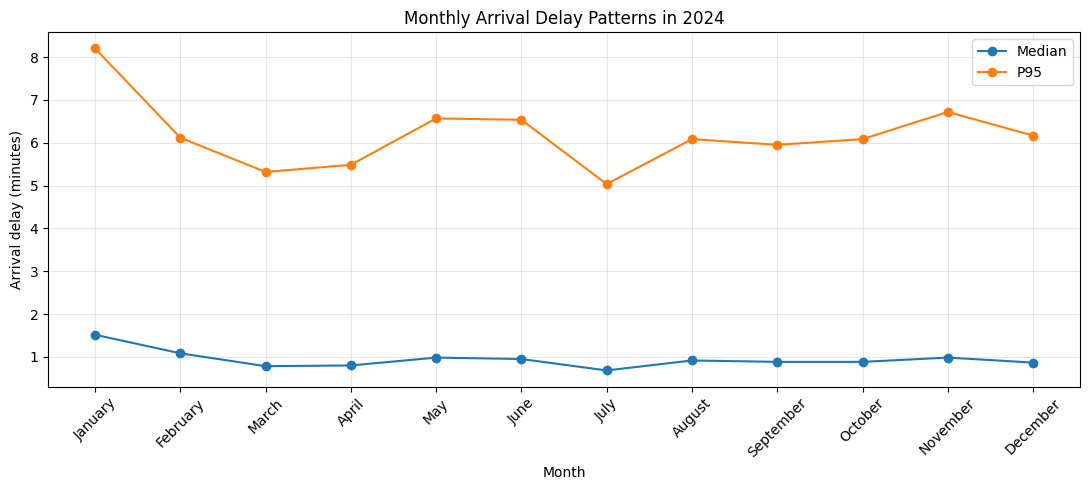

In [ ]:
# Monthly arrival delay patterns

import matplotlib.pyplot as plt

month_order = [
    "January", "February", "March",
    "April", "May", "June",
    "July", "August", "September",
    "October", "November", "December"
]

plot_data = (
    monthly_summary_2024
    .set_index("month_name")
    .reindex(month_order)
    .reset_index()
)

plt.figure(figsize=(11, 5))

plt.plot(
    plot_data["month_name"],
    plot_data["median_delay"],
    marker="o",
    label="Median"
)

plt.plot(
    plot_data["month_name"],
    plot_data["p95_delay"],
    marker="o",
    label="P95"
)

plt.xlabel("Month")
plt.ylabel("Arrival delay (minutes)")
plt.title("Monthly Arrival Delay Patterns in 2024")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{PLOT_PATH}/monthly_arrival_delay_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Monthly arrival-delay patterns varied across 2024. January showed the highest median and upper-tail delays, while July showed the lowest. The P95 varied more strongly across months than the median, indicating that larger delays exhibit greater temporal variation than typical delays.

These results suggest that expected delay conditions change throughout the year, supporting the inclusion of temporal context in the subsequent anomaly-detection analysis.

## 2.4 Transport Mode Composition and Delay Patterns

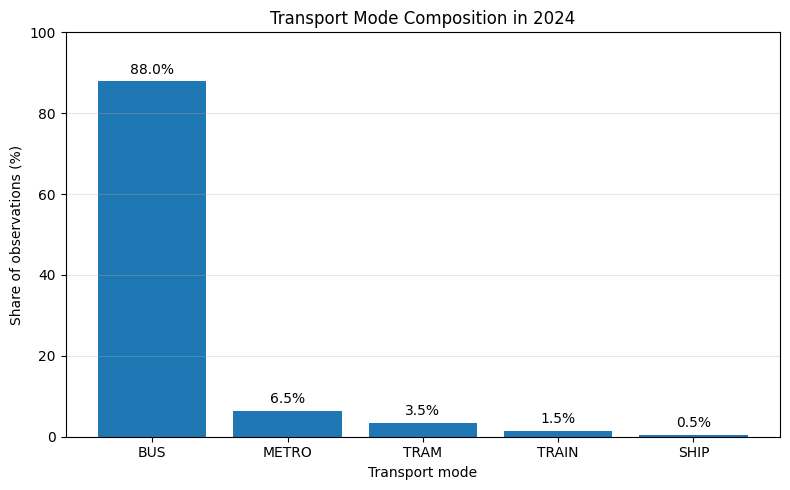

In [ ]:
# Full-year transport mode composition

mode_composition_plot = (
    mode_composition_2024
    .groupby("TransportMode", as_index=False)
    .agg(total_rows=("total_rows", "sum"))
)

mode_composition_plot["percentage"] = (
    100
    * mode_composition_plot["total_rows"]
    / mode_composition_plot["total_rows"].sum()
)

mode_composition_plot = mode_composition_plot.sort_values(
    "percentage",
    ascending=False
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    mode_composition_plot["TransportMode"],
    mode_composition_plot["percentage"]
)

plt.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in mode_composition_plot["percentage"]
    ],
    padding=3
)

plt.xlabel("Transport mode")
plt.ylabel("Share of observations (%)")
plt.title("Transport Mode Composition in 2024")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{PLOT_PATH}/transport_mode_composition_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

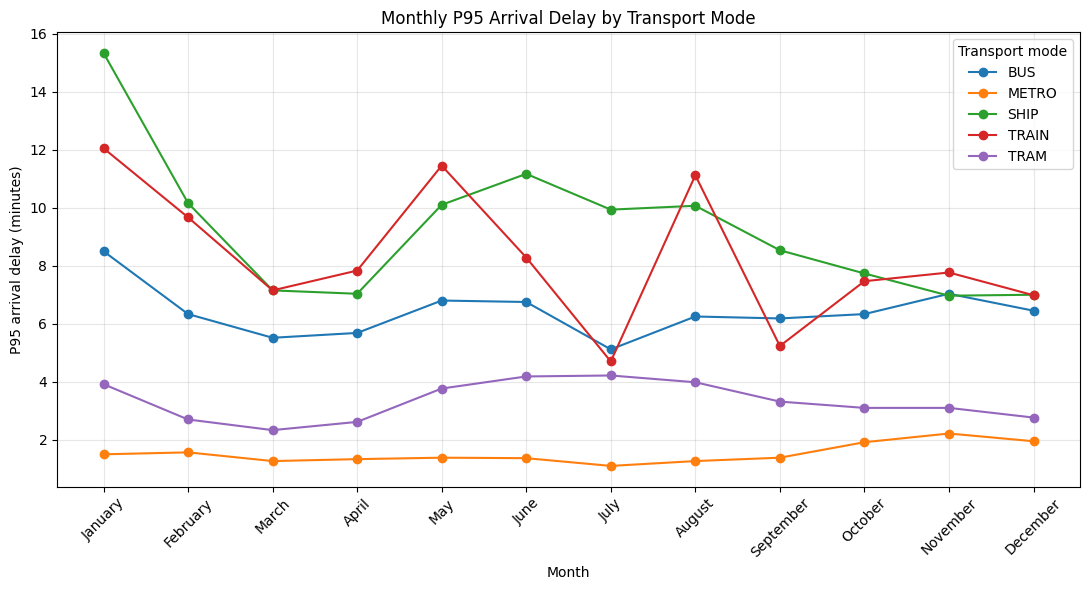

In [ ]:
# Monthly P95 arrival delay by transport mode

mode_p95_plot = (
    mode_summary_2024
    .pivot(
        index="month_name",
        columns="TransportMode",
        values="p95"
    )
    .reindex(month_order)
)

plt.figure(figsize=(11, 6))

for mode in mode_p95_plot.columns:
    plt.plot(
        mode_p95_plot.index,
        mode_p95_plot[mode],
        marker="o",
        label=mode
    )

plt.xlabel("Month")
plt.ylabel("P95 arrival delay (minutes)")
plt.title("Monthly P95 Arrival Delay by Transport Mode")
plt.xticks(rotation=45)
plt.legend(title="Transport mode")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{PLOT_PATH}/monthly_p95_delay_by_mode.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

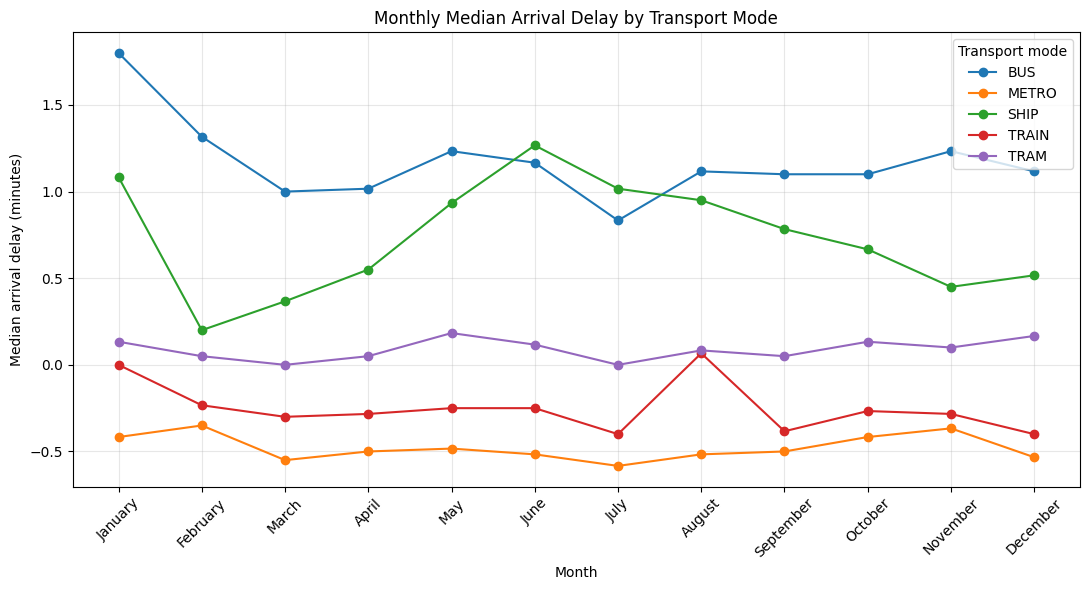

In [ ]:
# Monthly median arrival delay by transport mode

mode_median_plot = (
    mode_summary_2024
    .pivot(
        index="month_name",
        columns="TransportMode",
        values="median"
    )
    .reindex(month_order)
)

plt.figure(figsize=(11, 6))

for mode in mode_median_plot.columns:
    plt.plot(
        mode_median_plot.index,
        mode_median_plot[mode],
        marker="o",
        label=mode
    )

plt.xlabel("Month")
plt.ylabel("Median arrival delay (minutes)")
plt.title("Monthly Median Arrival Delay by Transport Mode")
plt.xticks(rotation=45)
plt.legend(title="Transport mode")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{PLOT_PATH}/monthly_median_delay_by_mode.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The dataset is strongly dominated by bus observations, which account for approximately 87–90% of trip-stop observations across the year. Metro represents the second-largest share, while tram, train, and ship observations occur substantially less frequently. Consequently, network-wide delay statistics are likely to be strongly influenced by bus operations.

Delay behavior also differs substantially between transport modes. Bus services generally exhibit positive median delays, while metro, train, and tram services tend to have median delays close to or below zero. Differences are even more pronounced in the upper tail, with train and ship services showing larger and more variable P95 delays.

These differences indicate that a single network-wide delay threshold would not adequately represent abnormal behavior across all transport modes. Transport mode should therefore be considered when defining expected operational conditions for anomaly detection.

## 2.5 Hour-of-Day and Weekday Patterns

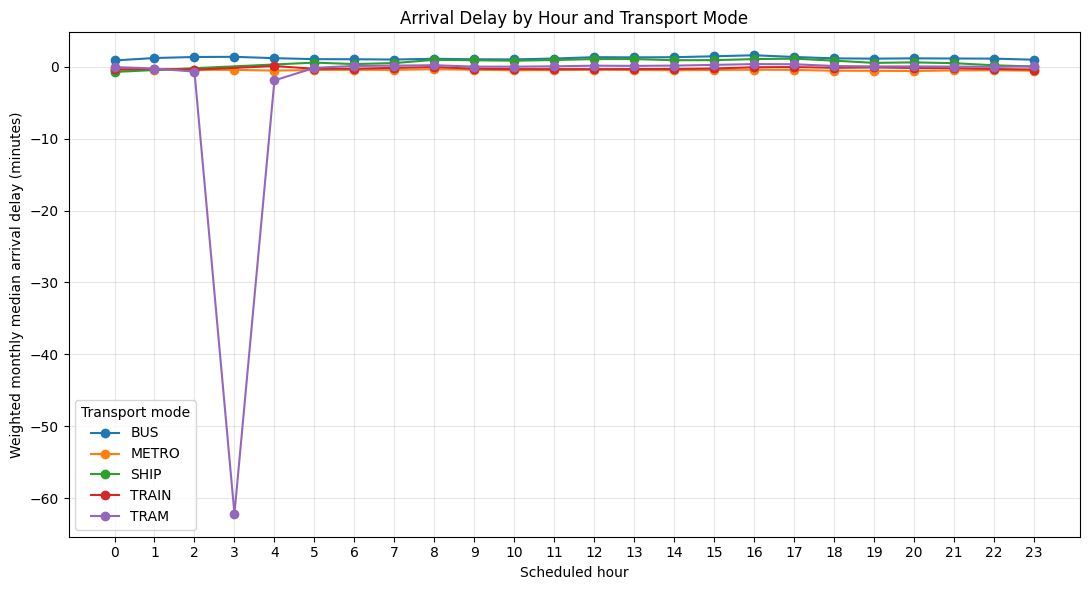

In [ ]:
# Hour-of-day delay patterns by transport mode

hour_mode_plot = mode_hour_summary_2024.copy()

hour_mode_plot["weighted_median"] = (
    hour_mode_plot["median"]
    * hour_mode_plot["observations"]
)

hour_mode_plot = (
    hour_mode_plot
    .groupby(
        ["TransportMode", "scheduled_hour_clock"],
        as_index=False
    )
    .agg(
        weighted_median_sum=("weighted_median", "sum"),
        observations=("observations", "sum")
    )
)

hour_mode_plot["weighted_median_delay"] = (
    hour_mode_plot["weighted_median_sum"]
    / hour_mode_plot["observations"]
)

plt.figure(figsize=(11, 6))

for mode in sorted(
    hour_mode_plot["TransportMode"].dropna().unique()
):
    temp = hour_mode_plot[
        hour_mode_plot["TransportMode"] == mode
    ]

    plt.plot(
        temp["scheduled_hour_clock"],
        temp["weighted_median_delay"],
        marker="o",
        label=mode
    )

plt.xlabel("Scheduled hour")
plt.ylabel("Weighted monthly median arrival delay (minutes)")
plt.title("Arrival Delay by Hour and Transport Mode")
plt.xticks(range(0, 24))
plt.legend(title="Transport mode")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{PLOT_PATH}/hourly_delay_by_mode.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Inspect unusual TRAM value at 03:00

tram_3am = mode_hour_summary_2024[
    (mode_hour_summary_2024["TransportMode"] == "TRAM")
    & (mode_hour_summary_2024["scheduled_hour_clock"] == 3)
].copy()

display(
    tram_3am[
        [
            "month",
            "scheduled_hour_clock",
            "observations",
            "median"
        ]
    ].sort_values("month")
)

,month,scheduled_hour_clock,observations,median
322,3,3.0,1,-62.166667


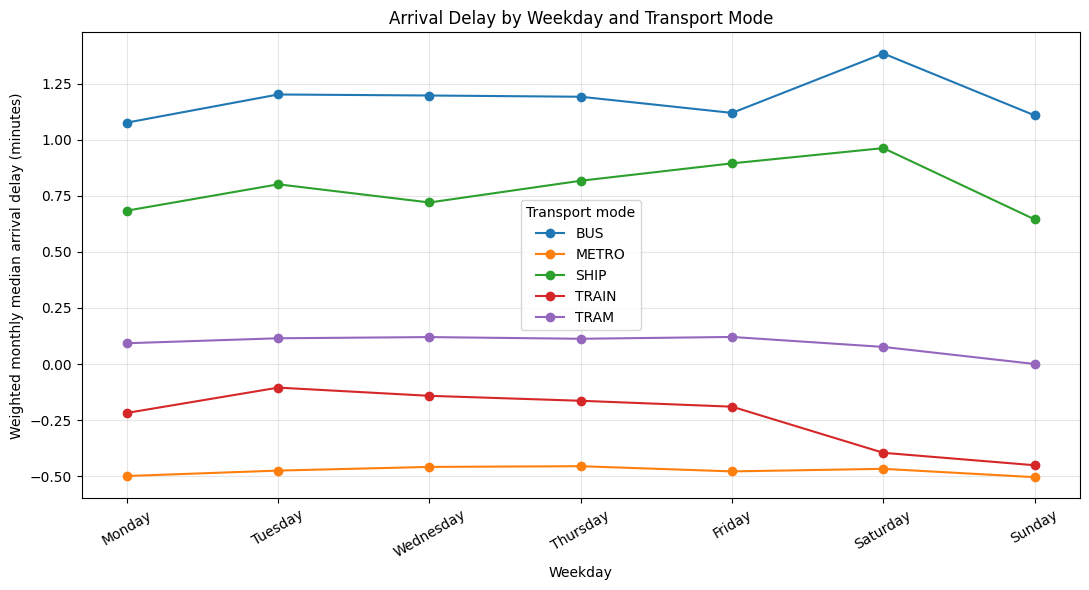

In [ ]:
# Weekday delay patterns by transport mode

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_mode_plot = mode_weekday_summary_2024.copy()

weekday_mode_plot["weighted_median"] = (
    weekday_mode_plot["median"]
    * weekday_mode_plot["observations"]
)

weekday_mode_plot = (
    weekday_mode_plot
    .groupby(
        ["TransportMode", "weekday"],
        as_index=False
    )
    .agg(
        weighted_median_sum=("weighted_median", "sum"),
        observations=("observations", "sum")
    )
)

weekday_mode_plot["weighted_median_delay"] = (
    weekday_mode_plot["weighted_median_sum"]
    / weekday_mode_plot["observations"]
)

weekday_mode_plot["weekday"] = pd.Categorical(
    weekday_mode_plot["weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_mode_plot = weekday_mode_plot.sort_values("weekday")

plt.figure(figsize=(11, 6))

for mode in sorted(
    weekday_mode_plot["TransportMode"].dropna().unique()
):
    temp = weekday_mode_plot[
        weekday_mode_plot["TransportMode"] == mode
    ]

    plt.plot(
        temp["weekday"],
        temp["weighted_median_delay"],
        marker="o",
        label=mode
    )

plt.xlabel("Weekday")
plt.ylabel("Weighted monthly median arrival delay (minutes)")
plt.title("Arrival Delay by Weekday and Transport Mode")
plt.xticks(rotation=30)
plt.legend(title="Transport mode")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{PLOT_PATH}/weekday_delay_by_mode.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Arrival-delay patterns varied by hour of day and transport mode. Bus services generally showed positive median delays, metro services remained comparatively stable with slightly negative median delays, and train and tram services were generally closer to zero. Ship services showed greater hourly variation.

An unusually large negative value was observed for tram services at 03:00. Further inspection showed that this mode-hour combination contained only one observation, meaning that the corresponding median is not representative of typical tram operation. The observation was retained during exploratory analysis rather than removed, since the purpose of this stage is to identify and document unusual characteristics of the data.

Weekday variation was less pronounced than the differences between transport modes. Overall, the results indicate that expected operational behavior depends on both transport mode and temporal context. Hour of day and weekday are therefore potentially useful contextual features for subsequent anomaly detection.

## 2.6 Route-Level Patterns

In [ ]:
# Inspect route observation counts

route_support = (
    route_summary_2024
    .groupby(["TransportMode", "route_id"], as_index=False)
    .agg(
        observations=("observations", "sum")
    )
)

display(route_support["observations"].describe())

display(
    route_support
    .sort_values("observations")
    .head(20)
)

,observations
count,6.490000e+02
mean,2.950293e+05
std,3.968374e+05
min,0.000000e+00
25%,2.743500e+04
50%,1.319040e+05
75%,4.143140e+05
max,2.644282e+06


,TransportMode,route_id,observations
591,SHIP,9011006094100000,0
592,SHIP,9011006094300000,0
411,BUS,9011001073100000,0
372,BUS,9011001068900000,0
179,BUS,9011001048900000,0
576,BUS,9011005097200000,0
575,BUS,9011005097100000,0
574,BUS,9011005095900000,0
562,BUS,9011002099400000,0
563,BUS,9011002099500000,0


In [ ]:
# Inspect routes with low numbers of valid delay observations

positive_route_support = route_support[
    route_support["observations"] > 0
].copy()

display(
    positive_route_support["observations"].describe(
        percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

display(
    positive_route_support
    .sort_values("observations")
    .head(20)
)

,observations
count,6.210000e+02
mean,3.083318e+05
std,4.006042e+05
min,2.100000e+01
1%,1.714000e+02
5%,2.098000e+03
10%,7.345000e+03
25%,3.879700e+04
50%,1.434670e+05
75%,4.342640e+05


,TransportMode,route_id,observations
358,BUS,9011001066900000,21
324,BUS,9011001064000000,22
557,BUS,9011001098700000-40B,72
335,BUS,9011001064800000-648Z,84
548,BUS,9011001098600000-43E,87
552,BUS,9011001098600000-43T,146
553,BUS,9011001098600000-43X,170
556,BUS,9011001098700000,177
644,TRAM,9011001002800000-28V,200
546,BUS,9011001098600000-43C,208


In [ ]:
# Calculate route-level delay patterns

route_plot = route_summary_2024.copy()

route_plot["weighted_p95"] = (
    route_plot["p95"]
    * route_plot["observations"]
)

route_plot = (
    route_plot
    .groupby(
        ["TransportMode", "route_id"],
        as_index=False
    )
    .agg(
        observations=("observations", "sum"),
        weighted_p95_sum=("weighted_p95", "sum")
    )
)

route_plot["weighted_monthly_p95"] = (
    route_plot["weighted_p95_sum"]
    / route_plot["observations"]
)

route_plot = route_plot[
    route_plot["observations"] > 0
].copy()

display(
    route_plot
    .sort_values("weighted_monthly_p95", ascending=False)
    .head(20)
)

,TransportMode,route_id,observations,weighted_p95_sum,weighted_monthly_p95
324,BUS,9011001064000000,22,2.058100e+03,93.550000
335,BUS,9011001064800000-648Z,84,6.396600e+03,76.150000
529,BUS,9011001095500000,25062,1.151007e+06,45.926373
358,BUS,9011001066900000,21,9.474500e+02,45.116667
617,SHIP,9011008002800000,11500,5.007194e+05,43.540820
620,SHIP,9011008003100000,3384,1.304987e+05,38.563443
593,SHIP,9011008000200000,4595,1.498100e+05,32.602826
548,BUS,9011001098600000-43E,87,2.721225e+03,31.278448
341,BUS,9011001065300000-653V,289,8.853173e+03,30.633818
515,BUS,9011001090800000,38479,1.065525e+06,27.691085


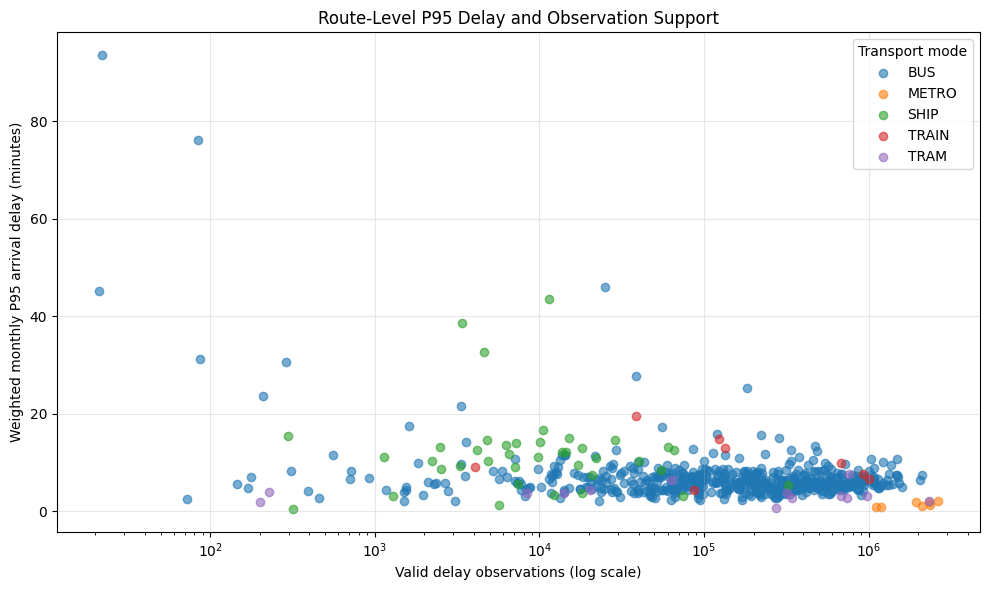

In [ ]:
# Route support and upper-tail delay

plt.figure(figsize=(10, 6))

for mode in sorted(route_plot["TransportMode"].dropna().unique()):
    temp = route_plot[
        route_plot["TransportMode"] == mode
    ]

    plt.scatter(
        temp["observations"],
        temp["weighted_monthly_p95"],
        alpha=0.6,
        label=mode
    )

plt.xscale("log")

plt.xlabel("Valid delay observations (log scale)")
plt.ylabel("Weighted monthly P95 arrival delay (minutes)")
plt.title("Route-Level P95 Delay and Observation Support")
plt.legend(title="Transport mode")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{PLOT_PATH}/route_p95_vs_observations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Route-level upper-tail delays varied substantially across the network. The most extreme weighted monthly P95 values were primarily associated with routes having relatively few valid delay observations, indicating that route-level statistics can become unstable when based on limited data. As the number of observations increased, P95 values became more concentrated.

However, relatively high P95 delays were also observed for some routes with substantial numbers of observations, suggesting that large upper-tail delays are not exclusively a consequence of small sample sizes. Differences between transport modes were also visible.

These results highlight the importance of considering observation support when interpreting route-level delay statistics. No routes were removed during this exploratory analysis; observation counts were examined alongside delay measures to distinguish potentially sparse estimates from more consistently observed operational patterns.

## 2.7 Stop-Level Patterns

In [ ]:
# Inspect stop-area observation counts

stop_support = (
    stop_summary_2024
    .groupby(
        ["TransportMode", "observed_StopAreaID"],
        as_index=False
    )
    .agg(
        observations=("observations", "sum")
    )
)

display(stop_support["observations"].describe())

display(
    stop_support
    .sort_values("observations")
    .head(20)
)

,observations
count,6221.000000
mean,30778.658094
std,46435.083023
min,0.000000
25%,4264.000000
50%,16208.000000
75%,39379.000000
max,720420.000000


,TransportMode,observed_StopAreaID,observations
0,BUS,9021001004301000,0
10,BUS,9021001004319000,0
4688,BUS,9021001073224000,0
6125,TRAM,9021001004491000,0
6117,TRAM,9021001004411000,0
6118,TRAM,9021001004421000,0
6119,TRAM,9021001004431000,0
4687,BUS,9021001073217000,0
6049,SHIP,9021001039641000,0
4600,BUS,9021001070801000,0


In [ ]:
# Inspect stop areas with valid delay observations

positive_stop_support = stop_support[
    stop_support["observations"] > 0
].copy()

display(
    positive_stop_support["observations"].describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

display(
    positive_stop_support
    .sort_values("observations")
    .head(20)
)

,observations
count,6049.000000
mean,31653.832369
std,46795.627139
min,3.000000
1%,95.000000
5%,717.000000
10%,1636.800000
25%,4780.000000
50%,17139.000000
75%,40438.000000


,TransportMode,observed_StopAreaID,observations
3924,BUS,9021001065109000,3
3925,BUS,9021001065111000,3
3939,BUS,9021001065139000,3
3926,BUS,9021001065113000,3
3942,BUS,9021001065145000,3
3933,BUS,9021001065127000,3
3936,BUS,9021001065133000,3
3928,BUS,9021001065117000,3
3929,BUS,9021001065119000,3
3940,BUS,9021001065141000,4


In [ ]:
# Calculate stop-area delay patterns

stop_plot = stop_summary_2024.copy()

stop_plot["weighted_p95"] = (
    stop_plot["p95"]
    * stop_plot["observations"]
)

stop_plot = (
    stop_plot
    .groupby(
        ["TransportMode", "observed_StopAreaID"],
        as_index=False
    )
    .agg(
        observations=("observations", "sum"),
        weighted_p95_sum=("weighted_p95", "sum")
    )
)

stop_plot["weighted_monthly_p95"] = (
    stop_plot["weighted_p95_sum"]
    / stop_plot["observations"]
)

stop_plot = stop_plot[
    stop_plot["observations"] > 0
].copy()

display(
    stop_plot
    .sort_values("weighted_monthly_p95", ascending=False)
    .head(20)
)

,TransportMode,observed_StopAreaID,observations,weighted_p95_sum,weighted_monthly_p95
5829,SHIP,9021001000184000,1188,138348.595000,116.455046
2710,BUS,9021001059510000,20,1871.000000,93.550000
5830,SHIP,9021001000185000,715,58787.685000,82.220538
5848,SHIP,9021001000218000,269,21487.573333,79.879455
5849,SHIP,9021001000219000,619,49339.551667,79.708484
2711,BUS,9021001059520000,80,6092.000000,76.150000
2489,BUS,9021001052711000,1159,69189.325000,59.697433
2487,BUS,9021001052709000,1159,68103.471667,58.760545
2460,BUS,9021001052358000,1159,67792.861667,58.492547
5939,SHIP,9021001000542000,589,31379.200000,53.275382


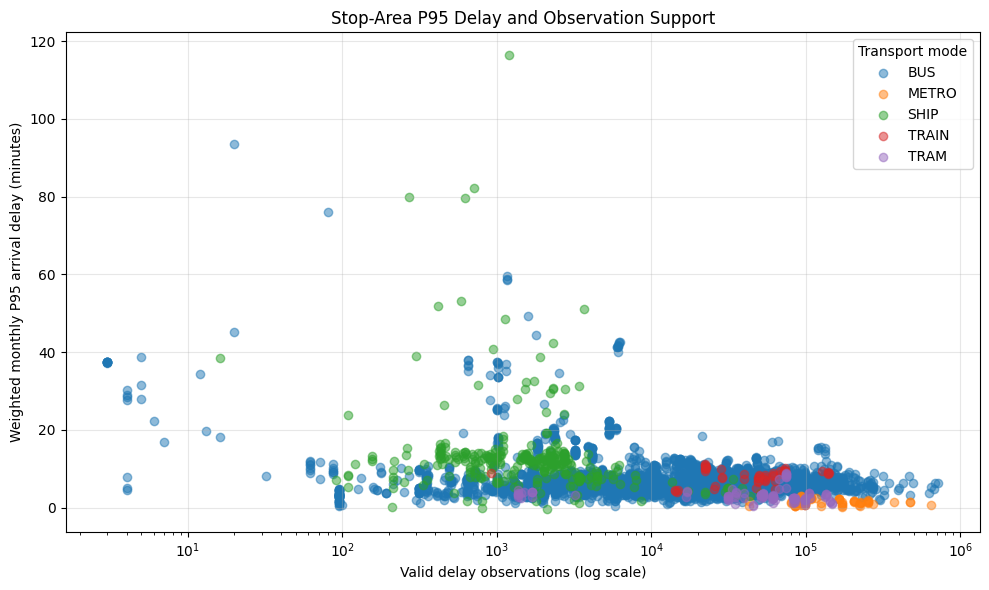

In [ ]:
# Stop-area support and upper-tail delay

plt.figure(figsize=(10, 6))

for mode in sorted(stop_plot["TransportMode"].dropna().unique()):
    temp = stop_plot[
        stop_plot["TransportMode"] == mode
    ]

    plt.scatter(
        temp["observations"],
        temp["weighted_monthly_p95"],
        alpha=0.5,
        label=mode
    )

plt.xscale("log")

plt.xlabel("Valid delay observations (log scale)")
plt.ylabel("Weighted monthly P95 arrival delay (minutes)")
plt.title("Stop-Area P95 Delay and Observation Support")
plt.legend(title="Transport mode")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{PLOT_PATH}/stop_area_p95_vs_observations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Stop-area delay patterns showed substantial variation across the network. The most extreme weighted monthly P95 values were generally observed among stop areas with relatively small numbers of valid delay observations, indicating that estimates based on limited data should be interpreted cautiously. As observation support increased, P95 values generally became more concentrated.

However, elevated upper-tail delays were also present at several stop areas with hundreds or thousands of observations, indicating that high P95 values cannot be attributed solely to sparse data. Differences between transport modes were also visible, with ship stop areas showing particularly large variation in upper-tail delays.

These findings reinforce the importance of considering both spatial context and observation support when interpreting operational delay patterns. No stop areas were removed during this exploratory analysis. Stop-area context may therefore provide useful information for the subsequent anomaly-detection models.

## 2.8 Missing Real-Time Information

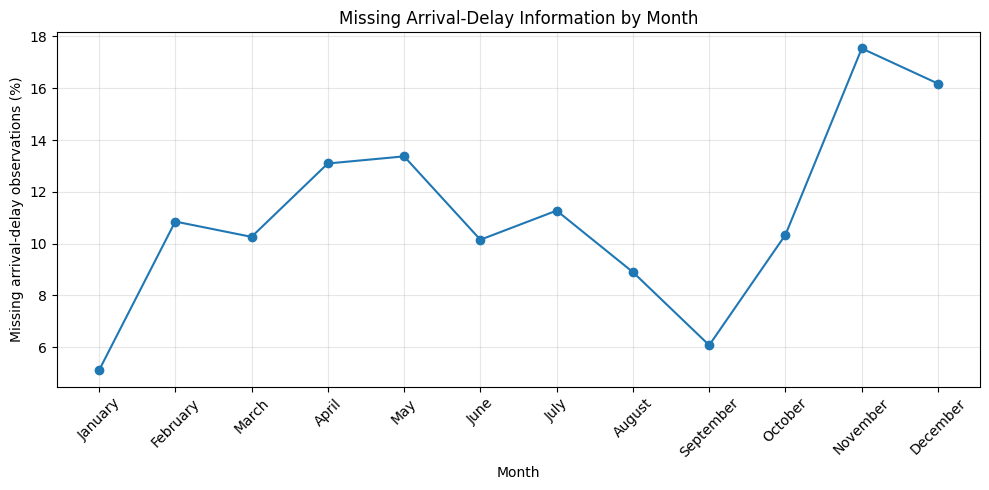

In [ ]:
# Missing arrival-delay information by month

missing_month_plot = monthly_summary_2024.copy()

missing_month_plot["missing_delay_percent"] = (
    100
    * (
        missing_month_plot["total_rows"]
        - missing_month_plot["valid_delay_observations"]
    )
    / missing_month_plot["total_rows"]
)

plt.figure(figsize=(10, 5))

plt.plot(
    missing_month_plot["month_name"],
    missing_month_plot["missing_delay_percent"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Missing arrival-delay observations (%)")
plt.title("Missing Arrival-Delay Information by Month")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{PLOT_PATH}/missing_arrival_delay_by_month.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

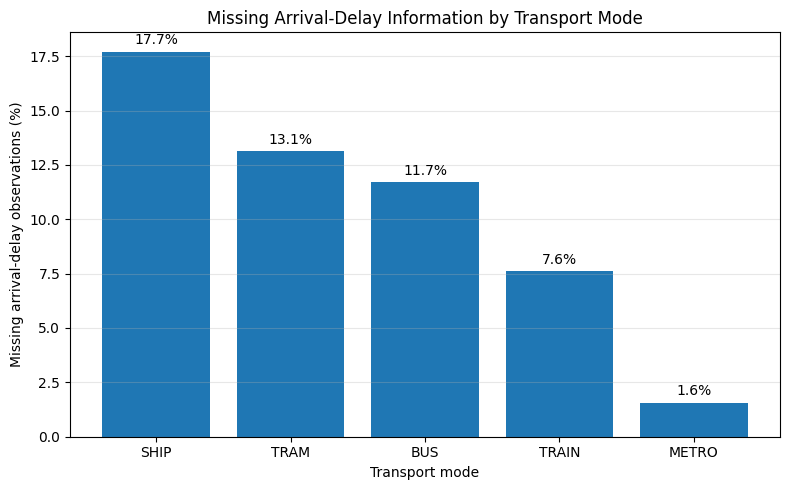

In [ ]:
# Missing arrival-delay information by transport mode

missing_mode_plot = (
    missing_by_mode_2024
    .groupby("TransportMode", as_index=False)
    .agg(
        total_rows=("total_rows", "sum"),
        missing_delay=("missing_delay", "sum")
    )
)

missing_mode_plot["missing_percent"] = (
    100
    * missing_mode_plot["missing_delay"]
    / missing_mode_plot["total_rows"]
)

missing_mode_plot = missing_mode_plot.sort_values(
    "missing_percent",
    ascending=False
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    missing_mode_plot["TransportMode"],
    missing_mode_plot["missing_percent"]
)

plt.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in missing_mode_plot["missing_percent"]
    ],
    padding=3
)

plt.xlabel("Transport mode")
plt.ylabel("Missing arrival-delay observations (%)")
plt.title("Missing Arrival-Delay Information by Transport Mode")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{PLOT_PATH}/missing_arrival_delay_by_mode.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Missing arrival-delay information varied substantially across both time and transport mode. Monthly missingness ranged from approximately 5% in January to more than 17% in November, indicating that the availability of real-time delay information was not constant throughout the year.

Missingness also differed considerably between transport modes. Ship services had the highest proportion of missing arrival-delay observations (17.7%), followed by tram (13.1%) and bus (11.7%). Train services had a lower missingness rate of 7.6%, while metro services had substantially less missing information at 1.6%.

These patterns indicate that missing real-time information is systematic rather than uniformly distributed across the dataset. Missing delay values should therefore not be interpreted as zero delay or automatically removed. Instead, missingness should be preserved and considered explicitly during feature engineering and model diagnostics, particularly when comparing anomaly patterns across transport modes and time periods.

## 2.9 Implications for Anomaly Detection


The exploratory analysis shows that operational delay behavior is strongly context-dependent. Delay distributions vary across months, transport modes, hours of the day, routes, and stop areas. In particular, transport modes exhibit substantially different typical and upper-tail delay levels, making a single network-wide delay threshold inappropriate for identifying unusual operational conditions.

The route- and stop-level analyses also showed that the reliability of descriptive delay statistics depends on observation support. Extreme upper-tail values were more common among sparsely observed groups, although elevated delays were also present in groups with substantial numbers of observations. Spatial context and observation support should therefore be considered when constructing and interpreting anomaly indicators.

Real-time information availability also varied substantially across months and transport modes. Missing delay observations should not be treated as zero delay, since this would conflate unavailable real-time information with on-time operation. Missingness should instead be retained as potentially informative operational context.

Based on these findings, the subsequent modeling analysis will focus on bus services. Two modeling scopes will be compared: a model specialized to a single bus line and a model trained across multiple bus lines. This design allows the analysis to investigate whether a line-specific representation of normal operation differs from a broader representation learned across heterogeneous bus routes.

#**3. ServiceAlert Analysis and Incident Reconstruction**

## 3.1 ServiceAlert Data Inspection

In [ ]:
# Load ServiceAlert data
alerts_path = "/content/service_alerts_2024.parquet"

alerts = pd.read_parquet(alerts_path)

print("Shape:", alerts.shape)
print("\nColumns:")
print(alerts.columns.tolist())

display(alerts.head())

display(
    alerts.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_values")
)

Shape: (1972779, 13)

Columns:
['id', 'start', 'end', 'cause', 'description_text2', 'header_text2', 'route_id', 'trip_id', 'schedule_relationship', 'stop_id', 'date_inserted', 'date', 'alert_message_timestamp']


,id,start,end,cause,description_text2,header_text2,route_id,trip_id,schedule_relationship,stop_id,date_inserted,date,alert_message_timestamp
0,14050001656394124,2024-01-06 05:06:14,2024-01-06 05:08:13,2,Ingen pÃ¥stigning,Ingen pÃ¥stigning,-1,-1,-1,9022001001701003,2024-01-06 05:07:02.489510,20240106,None
1,14050001656394176,2024-01-06 05:06:47,2024-01-06 05:08:44,2,Ingen påstigning,Ingen påstigning,-1,-1,-1,9022001003481001,2024-01-06 05:07:02.489510,20240106,None
2,14050001656394207,2024-01-06 05:06:56,2024-01-06 05:08:55,2,Ingen pÃ¥stigning,Ingen pÃ¥stigning,-1,-1,-1,9022001001551001,2024-01-06 05:08:02.602139,20240106,None
3,14050001656394246,2024-01-06 05:07:09,2024-01-06 05:09:08,2,Ingen pÃ¥stigning,Ingen pÃ¥stigning,-1,-1,-1,9022001001831002,2024-01-06 05:08:02.602139,20240106,None
4,14050001656394262,2024-01-06 05:07:34,2024-01-06 05:09:34,2,Ingen påstigning,Ingen påstigning,-1,-1,-1,9022001002121002,2024-01-06 05:08:02.602139,20240106,None


,missing_values
alert_message_timestamp,1972779
start,0
end,0
cause,0
id,0
description_text2,0
header_text2,0
trip_id,0
route_id,0
schedule_relationship,0


The ServiceAlert dataset contains 1,972,779 records and 13 variables. Most variables contain no conventional missing values, while `alert_message_timestamp` is entirely missing. However, identifiers such as `route_id`, `trip_id`, and `stop_id` also use values such as `-1` when an entity is not specified.

The raw number of ServiceAlert records should not be interpreted as the number of individual disruptions. A single alert may be represented by multiple records associated with different stops, trips, routes, or updates. Therefore, incident reconstruction is required before the alerts can be used as an external reference for anomaly evaluation.

## 3.2 Incident Reconstruction

In [ ]:
# Inspect ServiceAlert identifiers and entity coverage

print("Unique alert IDs:", alerts["id"].nunique())

print("\nUnique routes:", alerts["route_id"].nunique())
print("Unique trips:", alerts["trip_id"].nunique())
print("Unique stops:", alerts["stop_id"].nunique())

print("\nRows with a specified route:")
print((alerts["route_id"] != -1).value_counts())

print("\nRows with a specified trip:")
print((alerts["trip_id"] != -1).value_counts())

print("\nRows with a specified stop:")
print((alerts["stop_id"] != -1).value_counts())

print("\nUnique causes:")
print(alerts["cause"].value_counts().sort_index())

NameError: name 'alerts' is not defined

In [ ]:
# Inspect repeated ServiceAlert IDs

id_structure = (
    alerts.groupby("id")
    .agg(
        rows=("id", "size"),
        routes=("route_id", "nunique"),
        trips=("trip_id", "nunique"),
        stops=("stop_id", "nunique"),
        starts=("start", "nunique"),
        ends=("end", "nunique"),
        descriptions=("description_text2", "nunique")
    )
)

display(id_structure.describe())

print("\nIDs appearing in multiple rows:")
print((id_structure["rows"] > 1).sum())

print("\nIDs associated with multiple routes:")
print((id_structure["routes"] > 1).sum())

print("\nIDs associated with multiple start times:")
print((id_structure["starts"] > 1).sum())

print("\nIDs associated with multiple end times:")
print((id_structure["ends"] > 1).sum())

display(
    id_structure
    .sort_values("rows", ascending=False)
    .head(10)
)

,rows,routes,trips,stops,starts,ends,descriptions
count,811657.000000,811657.000000,811657.000000,811657.000000,811657.0,811657.0,811657.0
mean,2.430557,1.007344,1.000218,2.413467,1.0,1.0,1.0
std,6.250149,0.563837,0.016122,5.678470,0.0,0.0,0.0
min,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0
25%,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0
50%,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0
75%,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0
max,1246.000000,162.000000,5.000000,631.000000,1.0,1.0,1.0



IDs appearing in multiple rows:
91456

IDs associated with multiple routes:
1511

IDs associated with multiple start times:
0

IDs associated with multiple end times:
0


,rows,routes,trips,stops,starts,ends,descriptions
id,,,,,,,
14050001758813938,1246,97,1,631,1,1,1
14050001758848152,1246,97,1,631,1,1,1
14050001758903546,1246,97,1,631,1,1,1
14050001661190532,737,34,1,393,1,1,1
14050001728872293,724,15,1,409,1,1,1
14050001663476048,684,15,1,302,1,1,1
14050001671492787,371,9,1,226,1,1,1
14050001687504821,312,8,1,227,1,1,1
14050001687516918,312,8,1,227,1,1,1


In [ ]:
# Collapse raw rows to one record per alert ID

alerts_by_id = (
    alerts.groupby("id", as_index=False)
    .agg(
        start=("start", "first"),
        end=("end", "first"),
        cause=("cause", "first"),
        description=("description_text2", "first"),
        header=("header_text2", "first"),
        date_inserted=("date_inserted", "first"),
        route_count=("route_id", "nunique"),
        stop_count=("stop_id", "nunique"),
        trip_count=("trip_id", "nunique")
    )
)

alerts_by_id["start"] = pd.to_datetime(alerts_by_id["start"])
alerts_by_id["end"] = pd.to_datetime(alerts_by_id["end"])
alerts_by_id["date_inserted"] = pd.to_datetime(
    alerts_by_id["date_inserted"]
)

alerts_by_id["duration_min"] = (
    alerts_by_id["end"] - alerts_by_id["start"]
).dt.total_seconds() / 60

print("Alerts after collapsing by ID:", len(alerts_by_id))

display(
    alerts_by_id[
        [
            "start",
            "end",
            "date_inserted",
            "cause",
            "duration_min",
            "route_count",
            "stop_count",
            "trip_count"
        ]
    ].describe()
)

Alerts after collapsing by ID: 811657


,start,end,date_inserted,cause,duration_min,route_count,stop_count,trip_count
count,811657,811657,811657,811657.000000,8.116570e+05,811657.000000,811657.000000,811657.000000
mean,2024-06-30 11:01:52.883578112,2024-06-30 17:58:12.814659328,2024-06-30 11:18:55.791401728,2.128595,4.163322e+02,1.007344,2.413467,1.000218
min,2023-12-31 15:07:34,2024-01-01 00:01:51,2024-01-01 00:01:02.798155,2.000000,5.000000e-02,1.000000,1.000000,1.000000
25%,2024-03-27 15:53:50,2024-03-27 17:37:34,2024-03-27 15:55:01.958460928,2.000000,1.983333e+00,1.000000,1.000000,1.000000
50%,2024-06-21 02:02:53,2024-06-21 05:40:29,2024-06-21 02:10:02.164206080,2.000000,1.983333e+00,1.000000,1.000000,1.000000
75%,2024-10-06 13:46:51,2024-10-06 17:05:00,2024-10-06 14:18:02.725317888,2.000000,3.988333e+01,1.000000,1.000000,1.000000
max,2024-12-31 23:58:19,2038-01-18 03:14:00,2024-12-31 23:59:02.455696,12.000000,7.386450e+06,162.000000,631.000000,5.000000
std,NaN,NaN,NaN,0.768878,4.346715e+04,0.563837,5.678470,0.016122


In [ ]:
# Check repeated alert descriptions

description_counts = (
    alerts_by_id["description"]
    .value_counts()
    .reset_index()
)

description_counts.columns = [
    "description",
    "number_of_alert_ids"
]

display(description_counts.head(20))

print(
    "Unique descriptions:",
    alerts_by_id["description"].nunique()
)

,description,number_of_alert_ids
0,Se upp för passerande tåg,251553
1,Ingen pÃ¥stigning,165023
2,Ingen påstigning,144320
3,Försenad avgång,136533
4,Inställd avgång,16876
5,Invänta tid,15610
6,Ny avgångstid,13410
7,Inställd delsträcka,8144
8,Försenad cirka 5 minuter.,6056
9,Långt tåg,6001


Unique descriptions: 4606


In [ ]:
# Keep alerts associated with a specified route

alerts_real = alerts[
    alerts["route_id"].astype(str) != "-1"
].copy()

alerts_real["start"] = pd.to_datetime(alerts_real["start"])
alerts_real["end"] = pd.to_datetime(alerts_real["end"])

# Collapse duplicate rows to one record per alert ID and route

by_id_route = (
    alerts_real
    .groupby(["id", "route_id"])
    .agg(
        start=("start", "first"),
        end=("end", "first"),
        cause=("cause", "first"),
        n_stops=("stop_id", lambda s: int((s.astype(str) != "-1").sum()))
    )
    .reset_index()
)

print("Raw alert rows:", len(alerts))
print("Rows with specified route:", len(alerts_real))
print("Unique ID × route records:", len(by_id_route))

display(by_id_route.head())

Raw alert rows: 1972779
Rows with specified route: 40314
Unique ID × route records: 9760


,id,route_id,start,end,cause,n_stops
0,14050001645459562,9011001004300000,2024-01-07 04:00:00,2024-01-07 08:10:00,9,5
1,14050001645459562,9011001004300000-43X,2024-01-07 04:00:00,2024-01-07 08:10:00,9,5
2,14050001645460030,9011001004300000,2024-01-14 04:00:00,2024-01-14 08:10:00,9,5
3,14050001645460030,9011001004300000-43X,2024-01-14 04:00:00,2024-01-14 08:10:00,9,5
4,14050001654693413,9011001042100000,2024-01-02 05:43:26,2024-01-02 09:00:00,2,5


In [ ]:
# Merge overlapping alert windows within each route

by_id_route = by_id_route.sort_values(
    ["route_id", "start", "end"]
)

incidents = []

for route_id, group in by_id_route.groupby("route_id"):
    group = group.sort_values("start")

    current_start = None
    current_end = None
    alert_count = 0

    for _, row in group.iterrows():
        start = row["start"]
        end = row["end"]

        if current_start is None:
            current_start = start
            current_end = end
            alert_count = 1

        elif start <= current_end:
            current_end = max(current_end, end)
            alert_count += 1

        else:
            incidents.append({
                "route_id": route_id,
                "incident_start": current_start,
                "incident_end": current_end,
                "alert_count": alert_count
            })

            current_start = start
            current_end = end
            alert_count = 1

    if current_start is not None:
        incidents.append({
            "route_id": route_id,
            "incident_start": current_start,
            "incident_end": current_end,
            "alert_count": alert_count
        })

incidents = pd.DataFrame(incidents)

incidents["duration_min"] = (
    incidents["incident_end"]
    - incidents["incident_start"]
).dt.total_seconds() / 60

print("ID × route records:", len(by_id_route))
print("Reconstructed route-level incidents:", len(incidents))

display(incidents.head())

display(
    incidents[
        ["duration_min", "alert_count"]
    ].describe(
        percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]
    )
)

ID × route records: 9760
Reconstructed route-level incidents: 5161


,route_id,incident_start,incident_end,alert_count,duration_min
0,9011001000100000,2024-02-19 18:42:35,2024-02-19 20:00:00,3,77.416667
1,9011001000100000,2024-04-06 15:28:03,2024-04-06 18:00:00,1,151.950000
2,9011001000100000,2024-05-01 12:15:00,2024-05-01 14:30:00,1,135.000000
3,9011001000200000,2024-02-19 18:42:35,2024-02-19 20:00:00,3,77.416667
4,9011001000200000,2024-04-06 15:28:03,2024-04-06 18:00:00,1,151.950000


,duration_min,alert_count
count,5.161000e+03,5161.000000
mean,2.953707e+04,1.891106
std,4.094708e+05,3.806380
min,4.666667e-01,1.000000
50%,1.744667e+02,1.000000
75%,5.418833e+02,2.000000
90%,1.527250e+03,3.000000
95%,8.640000e+03,5.000000
99%,3.229015e+05,15.000000
max,7.357855e+06,137.000000


In [ ]:
# Create route-to-mode mapping from operational data

route_mode = (
    route_summary_2024[
        ["route_id", "TransportMode"]
    ]
    .drop_duplicates()
)

print("Unique route-mode combinations:", len(route_mode))

display(
    route_mode["TransportMode"]
    .value_counts()
)

Unique route-mode combinations: 649


,count
TransportMode,
BUS,577
SHIP,42
TRAM,15
TRAIN,8
METRO,7


In [ ]:
# Check whether route IDs map to multiple transport modes

route_mode_check = (
    route_mode.groupby("route_id")["TransportMode"]
    .nunique()
)

print(
    "Routes associated with multiple transport modes:",
    (route_mode_check > 1).sum()
)

Routes associated with multiple transport modes: 0


In [ ]:
# Attach transport mode to reconstructed incidents

incidents_with_mode = incidents.merge(
    route_mode,
    on="route_id",
    how="left"
)

print("Total reconstructed incidents:", len(incidents_with_mode))
print(
    "Incidents matched to an operational route:",
    incidents_with_mode["TransportMode"].notna().sum()
)

print("\nIncidents by transport mode:")
print(
    incidents_with_mode["TransportMode"]
    .value_counts(dropna=False)
)

Total reconstructed incidents: 5161
Incidents matched to an operational route: 5157

Incidents by transport mode:
TransportMode
BUS      4249
TRAM      440
METRO     253
TRAIN     156
SHIP       59
NaN         4
Name: count, dtype: int64


In [ ]:
# Keep BUS incidents

bus_incidents = incidents_with_mode[
    incidents_with_mode["TransportMode"] == "BUS"
].copy()

bus_incidents["month"] = (
    bus_incidents["incident_start"].dt.month
)

print("BUS incidents:", len(bus_incidents))
print(
    "BUS routes with at least one incident:",
    bus_incidents["route_id"].nunique()
)

display(bus_incidents.head())

BUS incidents: 4249
BUS routes with at least one incident: 471


,route_id,incident_start,incident_end,alert_count,duration_min,TransportMode,month
0,9011001000100000,2024-02-19 18:42:35,2024-02-19 20:00:00,3,77.416667,BUS,2
1,9011001000100000,2024-04-06 15:28:03,2024-04-06 18:00:00,1,151.950000,BUS,4
2,9011001000100000,2024-05-01 12:15:00,2024-05-01 14:30:00,1,135.000000,BUS,5
3,9011001000200000,2024-02-19 18:42:35,2024-02-19 20:00:00,3,77.416667,BUS,2
4,9011001000200000,2024-04-06 15:28:03,2024-04-06 18:00:00,1,151.950000,BUS,4


## 3.3 Bus Incident Distribution

In [ ]:
# Summarize BUS incidents by month

bus_incidents["month_name"] = (
    bus_incidents["incident_start"]
    .dt.month_name()
)

monthly_bus_incidents = (
    bus_incidents
    .groupby(["month", "month_name"])
    .agg(
        incidents=("route_id", "size"),
        routes_with_incidents=("route_id", "nunique")
    )
    .reset_index()
    .sort_values("month")
)

display(monthly_bus_incidents)

,month,month_name,incidents,routes_with_incidents
0,1,January,556,298
1,2,February,219,172
2,3,March,227,178
3,4,April,155,107
4,5,May,490,217
5,6,June,701,300
6,7,July,335,193
7,8,August,369,180
8,9,September,268,171
9,10,October,203,123


In [ ]:
# Summarize incidents by BUS route

bus_route_incidents = (
    bus_incidents
    .groupby("route_id")
    .agg(
        incidents=("route_id", "size"),
        first_incident=("incident_start", "min"),
        last_incident=("incident_start", "max")
    )
    .reset_index()
)

display(
    bus_route_incidents["incidents"]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

display(
    bus_route_incidents
    .sort_values("incidents", ascending=False)
    .head(20)
)

,incidents
count,471.000000
mean,9.021231
std,7.687208
min,1.000000
25%,3.000000
50%,7.000000
75%,13.000000
90%,19.000000
95%,24.500000
99%,36.300000


,route_id,incidents,first_incident,last_incident
58,9011001017600000-176E,43,2024-01-11 12:57:18,2024-12-02 16:42:45
57,9011001017600000,43,2024-01-11 12:57:18,2024-12-02 16:42:45
43,9011001015200000,38,2024-01-08 14:58:12,2024-12-19 14:59:30
180,9011001050700000,38,2024-01-12 06:48:25,2024-10-02 17:22:39
185,9011001051400000,37,2024-01-04 12:33:10,2024-12-04 14:56:06
60,9011001017700000-177E,36,2024-01-11 12:57:18,2024-12-02 16:42:45
59,9011001017700000,36,2024-01-11 12:57:18,2024-12-02 16:42:45
179,9011001050600000,35,2024-01-08 18:24:06,2024-12-17 16:22:31
25,9011001011200000,31,2024-01-08 19:26:38,2024-12-30 05:32:53
186,9011001051500000,29,2024-01-07 13:48:20,2024-12-11 17:32:05


Reconstructed BUS incidents were observed throughout 2024, although their frequency varied across months. Monthly incident counts ranged from 155 in April to 701 in June. Importantly, substantial numbers of incidents were also present toward the end of the year, including 384 incidents in November and 342 in December.

Incident frequency also varied across routes. Among the 471 BUS routes with at least one reconstructed incident, the median was seven incidents per route, while 90% of routes had 19 or fewer incidents. The maximum observed for an individual route was 43 incidents. This indicates that the reconstructed incidents are distributed across a broad set of BUS routes rather than being concentrated exclusively within a small number of routes.

The temporal coverage supports chronological model evaluation. January–August will be used for model training, September–October for validation and model selection, and November–December as a held-out test period. This preserves temporal ordering and allows the final evaluation to measure performance on future operational conditions.

## 3.4 Implications for Model Evaluation

The reconstructed ServiceAlert data provide an external reference for evaluating whether unusual operational conditions detected from GTFS/GTFS-RT data correspond to reported disruptions. After reconstruction, 4,249 BUS route-level incidents were identified across 471 routes, with incidents occurring throughout the year.

ServiceAlerts should not be interpreted as complete ground-truth labels for operational anomalies. A detected anomaly without a corresponding ServiceAlert is not necessarily a false positive, since unusual operational conditions may occur without a matching reported alert. Similarly, the declared start and end times of ServiceAlerts may represent alert validity periods rather than the exact duration of an operational disruption.

The anomaly-detection models will therefore be trained using operational data independently of ServiceAlerts. ServiceAlerts will only be introduced during evaluation to examine the correspondence between detected anomaly episodes and reported incidents.

To preserve temporal ordering, January–August will be used for training, September–October for validation and model selection, and November–December as a held-out test period.

#**4. Generalized BUS Anomaly-Detection Framework**

## 4.1 Modeling Scope and Temporal Split
The modeling stage focuses on BUS operations and aims to develop a generalized anomaly-detection framework that can identify unusual operational conditions across multiple bus routes.

Rather than defining anomalies using a single fixed delay threshold, the framework considers the operational context of each route. A delay may be unusual for one route or time period while being relatively normal for another. The model therefore incorporates route-specific temporal context, recent operational changes, and real-time data availability.

The models are trained using operational GTFS/GTFS-RT-derived data without using ServiceAlerts as input features. The reconstructed ServiceAlert incidents from Section 3 are retained as an external reference for later evaluation of detected anomalies.

To preserve temporal ordering and avoid information leakage, the data are divided chronologically:

- Training: January–August 2024
- Validation: September–October 2024
- Test: November–December 2024

The held-out test period is not used during feature fitting, model training, or model selection.

In [ ]:
# Create modeling folders

BUS_MODEL_PATH = f"{PROJECT_PATH}/bus_modeling"
BUS_WINDOW_PATH = f"{BUS_MODEL_PATH}/windows_15min"
BUS_FEATURE_PATH = f"{BUS_MODEL_PATH}/features_15min"

os.makedirs(BUS_WINDOW_PATH, exist_ok=True)
os.makedirs(BUS_FEATURE_PATH, exist_ok=True)

print(BUS_MODEL_PATH)
print(BUS_WINDOW_PATH)
print(BUS_FEATURE_PATH)

/content/drive/MyDrive/Project AI in Transportation/bus_modeling
/content/drive/MyDrive/Project AI in Transportation/bus_modeling/windows_15min
/content/drive/MyDrive/Project AI in Transportation/bus_modeling/features_15min


## 4.2 Operational Window Construction

BUS operations are represented using route-level 15-minute time windows. Each window summarizes the operational state of a bus route using scheduled arrival times to assign observations to time intervals.

For each route and 15-minute window, the aggregated variables include the number of observations, number of valid delay observations, median and mean arrival delay, delay variability, 90th-percentile delay, and the percentage of observations with missing real-time delay information.

The 15-minute aggregation provides a compromise between temporal resolution and the number of observations available within each operational window.

In [ ]:
# Check saved monthly BUS-window files

window_files = [
    f"{BUS_WINDOW_PATH}/bus_windows_2024{month:02d}.csv.gz"
    for month in range(1, 13)
]

for file in window_files:
    print(os.path.basename(file), os.path.exists(file))

bus_windows_202401.csv.gz True
bus_windows_202402.csv.gz True
bus_windows_202403.csv.gz True
bus_windows_202404.csv.gz True
bus_windows_202405.csv.gz True
bus_windows_202406.csv.gz True
bus_windows_202407.csv.gz True
bus_windows_202408.csv.gz True
bus_windows_202409.csv.gz True
bus_windows_202410.csv.gz True
bus_windows_202411.csv.gz True
bus_windows_202412.csv.gz True


In [ ]:
# Load saved BUS-window data

bus_windows = pd.concat(
    [
        pd.read_csv(
            file,
            compression="gzip",
            parse_dates=["window_start"]
        )
        for file in window_files
    ],
    ignore_index=True
)

print("Total windows:", f"{len(bus_windows):,}")
print("Routes:", bus_windows["route_id"].nunique())
print(
    "Time range:",
    bus_windows["window_start"].min(),
    "to",
    bus_windows["window_start"].max()
)

bus_windows.head()

/tmp/ipykernel_1042/460960504.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(
/tmp/ipykernel_1042/460960504.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(
/tmp/ipykernel_1042/460960504.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(
/tmp/ipykernel_1042/460960504.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(
/tmp/ipykernel_1042/460960504.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(
/tmp/ipykernel_1042/460960504.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(
/tmp/ipykernel_1042/460960504.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype 

Total windows: 9,167,930
Routes: 923
Time range: 2023-12-31 23:45:00 to 2025-01-01 01:15:00


,route_id,window_start,total_observations,valid_delay_observations,median_delay,mean_delay,delay_std,p90_delay,missing_delay_observations,missing_delay_percent,month
0,9011001000100000,2024-01-01 00:00:00,25,9,1.000000,0.992593,0.889371,1.600000,16,64.000000,1
1,9011001000100000,2024-01-01 00:15:00,49,21,7.366667,6.773810,3.206294,10.550000,28,57.142857,1
2,9011001000100000,2024-01-01 00:30:00,62,36,20.091667,16.497222,7.410815,24.358333,26,41.935484,1
3,9011001000100000,2024-01-01 00:45:00,37,25,23.433333,26.272667,4.177652,32.476667,12,32.432432,1
4,9011001000100000,2024-01-01 01:00:00,13,10,32.800000,32.771667,0.480294,33.241667,3,23.076923,1


In [ ]:
# Inspect route_id consistency

print("route_id dtype:", bus_windows["route_id"].dtype)
print("Unique route IDs:", bus_windows["route_id"].nunique())

route_counts_by_month = (
    bus_windows
    .groupby("month")["route_id"]
    .nunique()
)

print(route_counts_by_month)

route_id dtype: object
Unique route IDs: 923
month
1     741
2     758
3     778
4     785
5     767
6     789
7     736
8     837
9     758
10    767
11    731
12    765
Name: route_id, dtype: int64


In [ ]:
# Inspect route_id values

print(bus_windows["route_id"].head(20).tolist())

print("\nShortest IDs:")
print(
    bus_windows["route_id"]
    .astype(str)
    .drop_duplicates()
    .sort_values(key=lambda x: x.str.len())
    .head(20)
    .tolist()
)

print("\nLongest IDs:")
print(
    bus_windows["route_id"]
    .astype(str)
    .drop_duplicates()
    .sort_values(key=lambda x: x.str.len(), ascending=False)
    .head(20)
    .tolist()
)

[9011001000100000, 9011001000100000, 9011001000100000, 9011001000100000, 9011001000100000, 9011001000100000, 9011001000100000, 9011001000100000, 9011001000100000, 9011001000100000, 9011001000100000, 9011001000100000, 9011001000100000, 9011001000100000, 9011001000100000, 9011001000100000, 9011001000100000, 9011001000100000, 9011001000100000, 9011001000100000]

Shortest IDs:
['9011001005000000', '9011001006100000', '9011001006500000', '9011001006600000', '9011001006700000', '9011001006900000', '9011001009100000', '9011001009300000', '9011001009400000', '9011001009600000', '9011001000100000', '9011001011400000', '9011001011500000', '9011001011600000', '9011001011700000', '9011001011800000', '9011001091200000', '9011001043200000', '9011001098700000', '9011001005800000']

Longest IDs:
['9011001053800000-538V', '9011001055200000-552V', '9011001055300000-553V', '9011001055800000-558X', '9011001056000000-560X', '9011001056400000-564H', '9011001056400000-564V', '9011001057100000-571X', '9011001

In [ ]:
# Check route_id variants

route_id_str = bus_windows["route_id"].astype(str)

has_suffix = route_id_str.str.contains("-", regex=False)

print(
    "Windows with suffixed route_id:",
    round(100 * has_suffix.mean(), 2),
    "%"
)

print(
    "Unique standard route IDs:",
    route_id_str[~has_suffix].nunique()
)

print(
    "Unique suffixed route IDs:",
    route_id_str[has_suffix].nunique()
)

Windows with suffixed route_id: 5.46 %
Unique standard route IDs: 500
Unique suffixed route IDs: 77


## 4.3 Inspection of the Aggregated BUS Dataset

Before feature engineering, the distribution and completeness of the 15-minute operational windows are examined. This provides information about the amount of operational support within each window and the availability of real-time delay information.

Low-support windows and missing real-time observations are retained at this stage rather than removed using arbitrary thresholds. Their potential influence will instead be considered explicitly during feature preparation and model diagnostics.

In [ ]:
# Inspect aggregated BUS windows

bus_windows[
    [
        "total_observations",
        "valid_delay_observations",
        "median_delay",
        "mean_delay",
        "delay_std",
        "p90_delay",
        "missing_delay_percent"
    ]
].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

,total_observations,valid_delay_observations,median_delay,mean_delay,delay_std,p90_delay,missing_delay_percent
count,9167930.00,9167930.00,8589597.00,8589597.00,8355119.00,8589597.00,9167930.00
mean,20.67,18.25,1.40,1.33,1.81,3.14,11.72
std,16.89,15.65,2.85,2.80,1.68,4.00,27.61
min,1.00,0.00,-122.95,-122.44,0.00,-121.53,0.00
1%,1.00,0.00,-3.44,-3.45,0.27,-2.55,0.00
5%,3.00,0.00,-1.22,-1.36,0.47,-0.28,0.00
10%,5.00,2.00,-0.54,-0.71,0.61,0.33,0.00
25%,9.00,8.00,0.23,0.10,0.94,1.23,0.00
50%,15.00,14.00,1.05,0.99,1.43,2.44,0.00
75%,27.00,25.00,2.11,2.11,2.20,4.12,0.00


In [ ]:
# Inspect window support and missingness

print(
    "Windows with 1 observation:",
    round(100 * (bus_windows["total_observations"] == 1).mean(), 2),
    "%"
)

print(
    "Windows with fewer than 5 observations:",
    round(100 * (bus_windows["total_observations"] < 5).mean(), 2),
    "%"
)

print(
    "Windows with no valid delay:",
    round(100 * (bus_windows["valid_delay_observations"] == 0).mean(), 2),
    "%"
)

print(
    "Windows with missing delay_std:",
    round(100 * bus_windows["delay_std"].isna().mean(), 2),
    "%"
)

Windows with 1 observation: 2.72 %
Windows with fewer than 5 observations: 9.13 %
Windows with no valid delay: 6.31 %
Windows with missing delay_std: 8.87 %


## 4.4 Contextual Feature Engineering


Contextual features are created to distinguish unusual operational conditions from normal variation across routes and time periods.

The feature engineering process incorporates temporal information, historical route-specific delay expectations, and short-term changes between consecutive operational windows.

Historical expectations are calculated exclusively from the training period to avoid information leakage into validation and test data.

In [ ]:
# Create temporal features

bus_windows["hour"] = bus_windows["window_start"].dt.hour

bus_windows["weekday"] = bus_windows["window_start"].dt.weekday

bus_windows["is_weekend"] = (
    bus_windows["weekday"] >= 5
).astype(int)

bus_windows["hour_decimal"] = (
    bus_windows["window_start"].dt.hour
    + bus_windows["window_start"].dt.minute / 60
)

bus_windows["hour_sin"] = np.sin(
    2 * np.pi * bus_windows["hour_decimal"] / 24
)

bus_windows["hour_cos"] = np.cos(
    2 * np.pi * bus_windows["hour_decimal"] / 24
)

bus_windows["time_slot"] = (
    bus_windows["window_start"].dt.hour * 4
    + bus_windows["window_start"].dt.minute // 15
)

print(
    bus_windows[
        ["window_start", "hour", "weekday", "time_slot",
         "hour_sin", "hour_cos"]
    ].head()
)

         window_start  hour  weekday  time_slot  hour_sin  hour_cos
0 2024-01-01 00:00:00     0        0          0  0.000000  1.000000
1 2024-01-01 00:15:00     0        0          1  0.065403  0.997859
2 2024-01-01 00:30:00     0        0          2  0.130526  0.991445
3 2024-01-01 00:45:00     0        0          3  0.195090  0.980785
4 2024-01-01 01:00:00     1        0          4  0.258819  0.965926


In [ ]:
# Create chronological data split

train_mask = bus_windows["window_start"] < "2024-09-01"

val_mask = (
    (bus_windows["window_start"] >= "2024-09-01")
    & (bus_windows["window_start"] < "2024-11-01")
)

test_mask = bus_windows["window_start"] >= "2024-11-01"

print("Training windows:", f"{train_mask.sum():,}")
print("Validation windows:", f"{val_mask.sum():,}")
print("Test windows:", f"{test_mask.sum():,}")

print(
    "Total:",
    f"{train_mask.sum() + val_mask.sum() + test_mask.sum():,}"
)

Training windows: 6,097,045
Validation windows: 1,552,915
Test windows: 1,517,970
Total: 9,167,930


In [ ]:
# Calculate historical expectations using training data only

train_windows = bus_windows.loc[train_mask]

historical_baseline = (
    train_windows
    .groupby(
        ["route_id", "weekday", "time_slot"],
        as_index=False
    )
    .agg(
        expected_median_delay=("median_delay", "median"),
        expected_p90_delay=("p90_delay", "median"),
        historical_windows=("median_delay", "count")
    )
)

print(
    "Historical contexts:",
    f"{len(historical_baseline):,}"
)

historical_baseline.head()

Historical contexts: 278,454


,route_id,weekday,time_slot,expected_median_delay,expected_p90_delay,historical_windows
0,9011001000100000,0,0,0.966667,1.763333,37
1,9011001000100000,0,1,0.541667,1.753333,37
2,9011001000100000,0,2,0.550000,1.718333,34
3,9011001000100000,0,3,0.329167,1.541667,34
4,9011001000100000,0,4,-0.800000,0.245000,33


In [ ]:
# Attach training-derived historical baselines

bus_windows = bus_windows.merge(
    historical_baseline,
    on=["route_id", "weekday", "time_slot"],
    how="left",
    validate="many_to_one"
)

print(
    "Windows with historical baseline:",
    round(
        100 * bus_windows["expected_median_delay"].notna().mean(),
        2
    ),
    "%"
)

print(
    "Windows without historical baseline:",
    round(
        100 * bus_windows["expected_median_delay"].isna().mean(),
        2
    ),
    "%"
)

print("Total windows:", f"{len(bus_windows):,}")

Windows with historical baseline: 97.39 %
Windows without historical baseline: 2.61 %
Total windows: 9,167,930


In [ ]:
# Create deviation-from-normal features

bus_windows["median_delay_deviation"] = (
    bus_windows["median_delay"]
    - bus_windows["expected_median_delay"]
)

bus_windows["p90_delay_deviation"] = (
    bus_windows["p90_delay"]
    - bus_windows["expected_p90_delay"]
)

bus_windows[
    [
        "median_delay",
        "expected_median_delay",
        "median_delay_deviation",
        "p90_delay",
        "expected_p90_delay",
        "p90_delay_deviation"
    ]
].head()

,median_delay,expected_median_delay,median_delay_deviation,p90_delay,expected_p90_delay,p90_delay_deviation
0,1.000000,0.966667,0.033333,1.600000,1.763333,-0.163333
1,7.366667,0.541667,6.825000,10.550000,1.753333,8.796667
2,20.091667,0.550000,19.541667,24.358333,1.718333,22.640000
3,23.433333,0.329167,23.104167,32.476667,1.541667,30.935000
4,32.800000,-0.800000,33.600000,33.241667,0.245000,32.996667


In [ ]:
# Create previous-window features

bus_windows = bus_windows.sort_values(
    ["route_id", "window_start"]
).reset_index(drop=True)

bus_windows["previous_window"] = (
    bus_windows
    .groupby("route_id")["window_start"]
    .shift(1)
)

bus_windows["minutes_since_previous"] = (
    bus_windows["window_start"]
    - bus_windows["previous_window"]
).dt.total_seconds() / 60

bus_windows["previous_median_delay"] = (
    bus_windows
    .groupby("route_id")["median_delay"]
    .shift(1)
)

bus_windows["previous_p90_delay"] = (
    bus_windows
    .groupby("route_id")["p90_delay"]
    .shift(1)
)

bus_windows[
    [
        "route_id",
        "window_start",
        "previous_window",
        "minutes_since_previous",
        "median_delay",
        "previous_median_delay"
    ]
].head(10)

,route_id,window_start,previous_window,minutes_since_previous,median_delay,previous_median_delay
0,9011001000100000,2024-01-01 00:00:00,NaT,NaN,1.000000,NaN
1,9011001000100000,2024-01-01 00:15:00,2024-01-01 00:00:00,15.0,7.366667,1.000000
2,9011001000100000,2024-01-01 00:30:00,2024-01-01 00:15:00,15.0,20.091667,7.366667
3,9011001000100000,2024-01-01 00:45:00,2024-01-01 00:30:00,15.0,23.433333,20.091667
4,9011001000100000,2024-01-01 01:00:00,2024-01-01 00:45:00,15.0,32.800000,23.433333
5,9011001000100000,2024-01-01 06:00:00,2024-01-01 01:00:00,300.0,2.750000,32.800000
6,9011001000100000,2024-01-01 06:15:00,2024-01-01 06:00:00,15.0,4.500000,2.750000
7,9011001000100000,2024-01-01 06:30:00,2024-01-01 06:15:00,15.0,3.650000,4.500000
8,9011001000100000,2024-01-01 06:45:00,2024-01-01 06:30:00,15.0,1.383333,3.650000
9,9011001000100000,2024-01-01 07:00:00,2024-01-01 06:45:00,15.0,2.283333,1.383333


In [ ]:
# Create short-term delay-change features

consecutive = bus_windows["minutes_since_previous"] == 15

bus_windows["median_delay_change"] = np.where(
    consecutive,
    bus_windows["median_delay"]
    - bus_windows["previous_median_delay"],
    np.nan
)

bus_windows["p90_delay_change"] = np.where(
    consecutive,
    bus_windows["p90_delay"]
    - bus_windows["previous_p90_delay"],
    np.nan
)

print(
    "Consecutive 15-minute windows:",
    round(100 * consecutive.mean(), 2),
    "%"
)

print(
    "Median delay change available:",
    round(
        100 * bus_windows["median_delay_change"].notna().mean(),
        2
    ),
    "%"
)

print(
    "P90 delay change available:",
    round(
        100 * bus_windows["p90_delay_change"].notna().mean(),
        2
    ),
    "%"
)

Consecutive 15-minute windows: 94.55 %
Median delay change available: 88.33 %
P90 delay change available: 88.33 %


In [ ]:
# Standardize route identifiers before saving

bus_windows["route_id"] = bus_windows["route_id"].astype(str)

historical_baseline["route_id"] = (
    historical_baseline["route_id"].astype(str)
)

print("route_id dtype:", bus_windows["route_id"].dtype)

# Save feature-engineered BUS windows

import gc
import os

feature_file = (
    f"{BUS_FEATURE_PATH}/bus_windows_features_2024.parquet"
)

bus_windows.to_parquet(
    feature_file,
    index=False,
    engine="pyarrow",
    compression="snappy"
)

print("Features saved to:", feature_file)
print("Saved windows:", f"{len(bus_windows):,}")
print("File size (GB):", round(os.path.getsize(feature_file) / 1e9, 2))

del train_windows
gc.collect()

route_id dtype: object
Features saved to: /content/drive/MyDrive/Project AI in Transportation/bus_modeling/features_15min/bus_windows_features_2024.parquet
Saved windows: 9,167,930
File size (GB): 0.34


65

## 4.5 Model Dataset Preparation

The engineered operational features are prepared for anomaly-detection modeling. Missing values are examined before imputation or scaling, since some windows have no valid real-time delay observations or no available historical baseline.

Preprocessing parameters will be learned exclusively from the training period and subsequently applied to the validation and test periods.

In [ ]:
# Inspect candidate model features

feature_columns = [
    "median_delay",
    "p90_delay",
    "delay_std",
    "median_delay_deviation",
    "p90_delay_deviation",
    "median_delay_change",
    "p90_delay_change",
    "missing_delay_percent",
    "total_observations",
    "historical_windows",
    "hour_sin",
    "hour_cos",
    "is_weekend"
]

missing_features = (
    bus_windows[feature_columns]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

print("Missing values by feature (%):")
print(missing_features)

Missing values by feature (%):
median_delay_change       11.67
p90_delay_change          11.67
delay_std                  8.87
p90_delay_deviation        6.79
median_delay_deviation     6.79
p90_delay                  6.31
median_delay               6.31
historical_windows         0.70
missing_delay_percent      0.00
total_observations         0.00
hour_sin                   0.00
hour_cos                   0.00
is_weekend                 0.00
dtype: float64


In [ ]:
# Identify windows with observed delay information

bus_windows["has_valid_delay"] = (
    bus_windows["valid_delay_observations"] > 0
)

print(
    "Windows eligible for delay-based modeling:",
    f"{bus_windows['has_valid_delay'].sum():,}"
)

print(
    "Windows without observed delay:",
    f"{(~bus_windows['has_valid_delay']).sum():,}"
)

print(
    "Eligible percentage:",
    round(100 * bus_windows["has_valid_delay"].mean(), 2),
    "%"
)

Windows eligible for delay-based modeling: 8,589,597
Windows without observed delay: 578,333
Eligible percentage: 93.69 %


In [ ]:
# Recreate chronological masks after feature engineering

train_mask = (
    bus_windows["window_start"] < "2024-09-01"
)

val_mask = (
    (bus_windows["window_start"] >= "2024-09-01")
    & (bus_windows["window_start"] < "2024-11-01")
)

test_mask = (
    bus_windows["window_start"] >= "2024-11-01"
)

# Combine temporal split with delay-data eligibility

model_train_mask = train_mask & bus_windows["has_valid_delay"]
model_val_mask = val_mask & bus_windows["has_valid_delay"]
model_test_mask = test_mask & bus_windows["has_valid_delay"]

print("Eligible training windows:", f"{model_train_mask.sum():,}")
print("Eligible validation windows:", f"{model_val_mask.sum():,}")
print("Eligible test windows:", f"{model_test_mask.sum():,}")

print(
    "Total eligible:",
    f"{(model_train_mask | model_val_mask | model_test_mask).sum():,}"
)

Eligible training windows: 5,738,956
Eligible validation windows: 1,475,293
Eligible test windows: 1,375,348
Total eligible: 8,589,597


In [ ]:
# Inspect missing features in eligible training windows

train_missing = (
    bus_windows.loc[model_train_mask, feature_columns]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

print("Training feature missingness (%):")
print(train_missing)

Training feature missingness (%):
median_delay_change       5.64
p90_delay_change          5.64
delay_std                 2.71
median_delay              0.00
p90_delay                 0.00
p90_delay_deviation       0.00
median_delay_deviation    0.00
missing_delay_percent     0.00
total_observations        0.00
historical_windows        0.00
hour_sin                  0.00
hour_cos                  0.00
is_weekend                0.00
dtype: float64


In [ ]:
# Fit missing-value imputation using training data only

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(
    strategy="median",
    add_indicator=True,
    keep_empty_features=True
)

X_train = imputer.fit_transform(
    bus_windows.loc[model_train_mask, feature_columns]
)

print("Original features:", len(feature_columns))
print("Features after imputation:", X_train.shape[1])
print("Training matrix shape:", X_train.shape)
print("Remaining missing values:", np.isnan(X_train).sum())

Original features: 13
Features after imputation: 16
Training matrix shape: (5738956, 16)
Remaining missing values: 0


In [ ]:
# Transform validation and test using the training-fitted imputer

X_val = imputer.transform(
    bus_windows.loc[model_val_mask, feature_columns]
)

X_test = imputer.transform(
    bus_windows.loc[model_test_mask, feature_columns]
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("Training missing:", np.isnan(X_train).sum())
print("Validation missing:", np.isnan(X_val).sum())
print("Test missing:", np.isnan(X_test).sum())

Training: (5738956, 16)
Validation: (1475293, 16)
Test: (1375348, 16)
Training missing: 0
Validation missing: 0
Test missing: 0


In [ ]:
# Scale features using training data only

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Training:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

print("Training finite:", np.isfinite(X_train_scaled).all())
print("Validation finite:", np.isfinite(X_val_scaled).all())
print("Test finite:", np.isfinite(X_test_scaled).all())

Training: (5738956, 16)
Validation: (1475293, 16)
Test: (1375348, 16)
Training finite: True
Validation finite: True
Test finite: True


In [ ]:
# Save preprocessing objects and scaled model datasets

import os
import joblib
import numpy as np

PREPROCESS_PATH = f"{BUS_MODEL_PATH}/preprocessing"
os.makedirs(PREPROCESS_PATH, exist_ok=True)

joblib.dump(
    {
        "imputer": imputer,
        "scaler": scaler,
        "feature_columns": feature_columns
    },
    f"{PREPROCESS_PATH}/preprocessing.joblib"
)

np.save(
    f"{PREPROCESS_PATH}/X_train_scaled.npy",
    X_train_scaled.astype(np.float32)
)

np.save(
    f"{PREPROCESS_PATH}/X_val_scaled.npy",
    X_val_scaled.astype(np.float32)
)

np.save(
    f"{PREPROCESS_PATH}/X_test_scaled.npy",
    X_test_scaled.astype(np.float32)
)

print("Preprocessing checkpoint saved.")
print("Training:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

Preprocessing checkpoint saved.
Training: (5738956, 16)
Validation: (1475293, 16)
Test: (1375348, 16)


## 4.6 Anomaly-Detection Models

Three anomaly-detection approaches are investigated: a contextual statistical baseline, Isolation Forest, and an autoencoder.

The models use operational features independently of ServiceAlerts. Anomaly scores are subsequently compared with reconstructed ServiceAlert incidents during evaluation.

### 4.6.1 Contextual Statistical Baseline


The statistical baseline identifies unusual operating conditions using deviations from historical route-specific delay expectations. Robust statistics calculated from the training period are used to normalize these deviations.

In [ ]:
# Inspect training deviation distributions

stat_features = [
    "median_delay_deviation",
    "p90_delay_deviation"
]

stat_train = bus_windows.loc[
    model_train_mask,
    stat_features
]

stat_train.describe(
    percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
).round(2)

,median_delay_deviation,p90_delay_deviation
count,5738956.00,5738956.00
mean,0.30,0.55
std,2.56,3.49
min,-121.27,-122.70
1%,-3.38,-4.06
5%,-1.84,-2.32
50%,0.00,0.00
95%,3.13,4.91
99%,7.75,12.11
max,174.38,174.47


In [ ]:
# Calculate robust deviation statistics from training data

stat_median = stat_train.median()

stat_mad = (
    stat_train
    .sub(stat_median)
    .abs()
    .median()
)

stat_scale = 1.4826 * stat_mad

print("Training medians:")
print(stat_median.round(3))

print("\nMedian absolute deviations (MAD):")
print(stat_mad.round(3))

print("\nRobust scales:")
print(stat_scale.round(3))

Training medians:
median_delay_deviation    0.0
p90_delay_deviation       0.0
dtype: float64

Median absolute deviations (MAD):
median_delay_deviation    0.675
p90_delay_deviation       0.922
dtype: float64

Robust scales:
median_delay_deviation    1.001
p90_delay_deviation       1.366
dtype: float64


In [ ]:
# Calculate statistical anomaly scores

stat_features = [
    "median_delay_deviation",
    "p90_delay_deviation"
]

for feature in stat_features:
    bus_windows[f"{feature}_robust_z"] = (
        bus_windows[feature] - stat_median[feature]
    ) / stat_scale[feature]

# Focus on unusually high delays

bus_windows["stat_anomaly_score"] = (
    bus_windows[
        [
            "median_delay_deviation_robust_z",
            "p90_delay_deviation_robust_z"
        ]
    ]
    .clip(lower=0)
    .max(axis=1)
)

print(
    "Statistical scores available:",
    f"{bus_windows['stat_anomaly_score'].notna().sum():,}"
)

print(
    bus_windows.loc[
        model_train_mask,
        "stat_anomaly_score"
    ].describe(
        percentiles=[0.50, 0.90, 0.95, 0.99]
    ).round(2)
)

Statistical scores available: 8,545,405
count    5738956.00
mean           1.02
std            2.73
min            0.00
50%            0.20
90%            2.66
95%            4.24
99%           10.10
max          174.25
Name: stat_anomaly_score, dtype: float64


In [ ]:
# Compare statistical anomaly scores across data splits

for name, mask in [
    ("Training", model_train_mask),
    ("Validation", model_val_mask),
    ("Test", model_test_mask)
]:
    scores = bus_windows.loc[
        mask, "stat_anomaly_score"
    ]

    print(f"\n{name}")
    print("Available scores:", f"{scores.notna().sum():,}")
    print("Missing scores:", f"{scores.isna().sum():,}")

    print(
        scores.describe(
            percentiles=[0.50, 0.90, 0.95, 0.99]
        ).round(2)
    )


Training
Available scores: 5,738,956
Missing scores: 0
count    5738956.00
mean           1.02
std            2.73
min            0.00
50%            0.20
90%            2.66
95%            4.24
99%           10.10
max          174.25
Name: stat_anomaly_score, dtype: float64

Validation
Available scores: 1,459,843
Missing scores: 15,450
count    1459843.00
mean           1.02
std            2.79
min            0.00
50%            0.18
90%            2.61
95%            4.16
99%           10.36
max          148.06
Name: stat_anomaly_score, dtype: float64

Test
Available scores: 1,346,606
Missing scores: 28,742
count    1346606.00
mean           1.17
std            2.87
min            0.00
50%            0.25
90%            3.03
95%            4.83
99%           11.63
max          129.05
Name: stat_anomaly_score, dtype: float64


In [ ]:
# Define candidate thresholds using training scores only

train_scores = bus_windows.loc[
    model_train_mask,
    "stat_anomaly_score"
].dropna()

thresholds = train_scores.quantile(
    [0.95, 0.975, 0.99]
)

print("Candidate statistical thresholds:")
print(thresholds.round(3))

Candidate statistical thresholds:
0.950     4.245
0.975     6.347
0.990    10.100
Name: stat_anomaly_score, dtype: float64


In [ ]:
# Compare detection rates on validation data

val_scores = bus_windows.loc[
    model_val_mask,
    "stat_anomaly_score"
].dropna()

threshold_results = []

for quantile, threshold in thresholds.items():

    threshold_results.append({
        "training_quantile": quantile,
        "threshold": threshold,
        "validation_anomaly_percent": (
            100 * (val_scores > threshold).mean()
        )
    })

pd.DataFrame(threshold_results).round(2)

,training_quantile,threshold,validation_anomaly_percent
0,0.95,4.24,4.85
1,0.98,6.35,2.45
2,0.99,10.10,1.05


In [ ]:
# Save statistical detector parameters and threshold candidates

import joblib
import os

STAT_MODEL_PATH = f"{BUS_MODEL_PATH}/statistical_model"
os.makedirs(STAT_MODEL_PATH, exist_ok=True)

joblib.dump(
    {
        "stat_features": stat_features,
        "stat_median": stat_median,
        "stat_mad": stat_mad,
        "stat_scale": stat_scale,
        "thresholds": thresholds
    },
    f"{STAT_MODEL_PATH}/statistical_detector.joblib"
)

pd.DataFrame(threshold_results).to_csv(
    f"{STAT_MODEL_PATH}/validation_threshold_results.csv",
    index=False
)

print("Statistical detector saved successfully.")

Statistical detector saved successfully.


### 4.6.2 Isolation Forest

Isolation Forest is used as a multivariate anomaly-detection method. Unlike the statistical baseline, which examines historical delay deviations directly, Isolation Forest considers combinations of the engineered operational features.

The model is fitted exclusively on the training period using the previously prepared numerical feature matrix. ServiceAlerts are not used during model training.

In [ ]:
# Prepare reproducible Isolation Forest training sample

rng = np.random.default_rng(42)

if_train_size = min(500_000, len(X_train_scaled))

if_train_indices = rng.choice(
    len(X_train_scaled),
    size=if_train_size,
    replace=False
)

X_if_train = X_train_scaled[if_train_indices].astype(
    np.float32
)

print("Isolation Forest training sample:", X_if_train.shape)
print("Remaining missing values:", np.isnan(X_if_train).sum())

Isolation Forest training sample: (500000, 16)
Remaining missing values: 0


In [ ]:
# Train Isolation Forest on sampled training windows

from sklearn.ensemble import IsolationForest
import time

if_model = IsolationForest(
    n_estimators=200,
    max_samples=256,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

if_model.fit(X_if_train)

training_time = time.time() - start_time

print("Isolation Forest trained successfully.")
print("Training time (seconds):", round(training_time, 2))
print("Number of trees:", len(if_model.estimators_))

Isolation Forest trained successfully.
Training time (seconds): 1.29
Number of trees: 200


In [ ]:
# Save trained Isolation Forest

import joblib
import os

IF_MODEL_PATH = f"{BUS_MODEL_PATH}/isolation_forest"

os.makedirs(IF_MODEL_PATH, exist_ok=True)

joblib.dump(
    if_model,
    f"{IF_MODEL_PATH}/isolation_forest.joblib"
)

print("Isolation Forest saved successfully.")

Isolation Forest saved successfully.


In [ ]:
# Calculate Isolation Forest anomaly scores

import time

start_time = time.time()

if_train_scores = -if_model.score_samples(X_train_scaled)
if_val_scores = -if_model.score_samples(X_val_scaled)
if_test_scores = -if_model.score_samples(X_test_scaled)

scoring_time = time.time() - start_time

print("Scoring time (seconds):", round(scoring_time, 2))

print("Training scores:", if_train_scores.shape)
print("Validation scores:", if_val_scores.shape)
print("Test scores:", if_test_scores.shape)

print(
    "\nValidation score distribution:"
)

print(
    pd.Series(if_val_scores).describe(
        percentiles=[0.50, 0.90, 0.95, 0.99]
    ).round(4)
)

Scoring time (seconds): 57.24
Training scores: (5738956,)
Validation scores: (1475293,)
Test scores: (1375348,)

Validation score distribution:
count    1.475293e+06
mean     4.253000e-01
std      5.710000e-02
min      3.509000e-01
50%      4.085000e-01
90%      5.100000e-01
95%      5.433000e-01
99%      6.170000e-01
max      7.719000e-01
dtype: float64


In [ ]:
# Save Isolation Forest anomaly scores

np.save(
    f"{IF_MODEL_PATH}/if_train_scores.npy",
    if_train_scores.astype(np.float32)
)

np.save(
    f"{IF_MODEL_PATH}/if_val_scores.npy",
    if_val_scores.astype(np.float32)
)

np.save(
    f"{IF_MODEL_PATH}/if_test_scores.npy",
    if_test_scores.astype(np.float32)
)

print("Isolation Forest scores saved successfully.")
print("Training:", len(if_train_scores))
print("Validation:", len(if_val_scores))
print("Test:", len(if_test_scores))

Isolation Forest scores saved successfully.
Training: 5738956
Validation: 1475293
Test: 1375348


In [ ]:
# Calculate Isolation Forest candidate thresholds

if_thresholds = pd.Series(if_train_scores).quantile(
    [0.95, 0.975, 0.99]
)

print("Isolation Forest candidate thresholds:")
print(if_thresholds.round(4))

Isolation Forest candidate thresholds:
0.950    0.5417
0.975    0.5740
0.990    0.6141
dtype: float64


In [ ]:
# Compare Isolation Forest validation detection rates

if_threshold_results = []

for quantile, threshold in if_thresholds.items():

    if_threshold_results.append({
        "training_quantile": quantile,
        "threshold": threshold,
        "validation_anomaly_percent": (
            100 * (if_val_scores > threshold).mean()
        )
    })

pd.DataFrame(if_threshold_results).round(4)

,training_quantile,threshold,validation_anomaly_percent
0,0.950,0.5417,5.1948
1,0.975,0.5740,2.5895
2,0.990,0.6141,1.0683


In [ ]:
# Save Isolation Forest threshold candidates and validation results

joblib.dump(
    {
        "thresholds": if_thresholds,
        "training_sample_size": if_train_size,
        "random_state": 42
    },
    f"{IF_MODEL_PATH}/if_thresholds.joblib"
)

pd.DataFrame(if_threshold_results).to_csv(
    f"{IF_MODEL_PATH}/validation_threshold_results.csv",
    index=False
)

print("Isolation Forest threshold results saved successfully.")

Isolation Forest threshold results saved successfully.


### 4.6.3 Autoencoder

A neural-network autoencoder is trained to reconstruct typical combinations of operational features. Windows with unusually high reconstruction errors are treated as potential anomalies.

The autoencoder uses the same training-only preprocessing as Isolation Forest. ServiceAlerts remain excluded from model training and are reserved for subsequent evaluation.

In [ ]:
# Define the autoencoder architecture

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)

input_dim = X_train_scaled.shape[1]

ae_input = keras.Input(shape=(input_dim,))

x = layers.Dense(32, activation="relu")(ae_input)
x = layers.Dense(16, activation="relu")(x)

latent = layers.Dense(8, activation="linear", name="latent")(x)

x = layers.Dense(16, activation="relu")(latent)
x = layers.Dense(32, activation="relu")(x)

ae_output = layers.Dense(input_dim, activation="linear")(x)

autoencoder = keras.Model(
    inputs=ae_input,
    outputs=ae_output,
    name="bus_autoencoder"
)

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

autoencoder.summary()

Model: "bus_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,424 (9.47 KB)

 Trainable params: 2,424 (9.47 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Prepare autoencoder training and validation samples

rng = np.random.default_rng(42)

ae_train_size = min(500_000, len(X_train_scaled))
ae_val_size = min(100_000, len(X_val_scaled))

ae_train_indices = rng.choice(
    len(X_train_scaled),
    size=ae_train_size,
    replace=False
)

ae_val_indices = rng.choice(
    len(X_val_scaled),
    size=ae_val_size,
    replace=False
)

X_ae_train = X_train_scaled[ae_train_indices].astype(np.float32)
X_ae_val = X_val_scaled[ae_val_indices].astype(np.float32)

print("Autoencoder training data:", X_ae_train.shape)
print("Autoencoder validation data:", X_ae_val.shape)

print("Training values finite:", np.isfinite(X_ae_train).all())
print("Validation values finite:", np.isfinite(X_ae_val).all())

Autoencoder training data: (500000, 16)
Autoencoder validation data: (100000, 16)
Training values finite: True
Validation values finite: True


In [ ]:
# Train autoencoder with early stopping

import time

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=0.0001,
    restore_best_weights=True
)

start_time = time.time()

ae_history = autoencoder.fit(
    X_ae_train,
    X_ae_train,
    validation_data=(X_ae_val, X_ae_val),
    epochs=50,
    batch_size=1024,
    callbacks=[early_stopping],
    shuffle=True,
    verbose=1
)

ae_training_time = time.time() - start_time

print("\nTraining time (seconds):", round(ae_training_time, 2))
print("Epochs completed:", len(ae_history.history["loss"]))
print("Best validation loss:", round(min(ae_history.history["val_loss"]), 6))

Epoch 1/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1.2730 - val_loss: 0.2443
Epoch 2/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1640 - val_loss: 0.1374
Epoch 3/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1045 - val_loss: 0.0990
Epoch 4/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0804 - val_loss: 0.0783
Epoch 5/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0652 - val_loss: 0.0660
Epoch 6/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0575 - val_loss: 0.0603
Epoch 7/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0529 - val_loss: 0.0563
Epoch 8/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0491 - val_loss: 0.0515
Epoch 9/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0468 - val_loss: 0.0487
Epoch 10/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0454 - val_loss: 0.0477
Epoch 11/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0442 - val_loss: 0.0474
Epoch 12/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

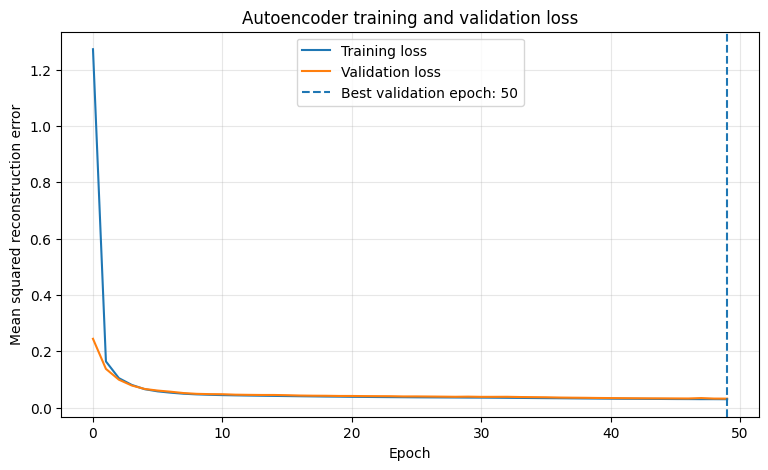

Best epoch: 50
Final training loss: 0.029602
Final validation loss: 0.031724
Best validation loss: 0.031724


In [ ]:
# Inspect autoencoder training history

import matplotlib.pyplot as plt
import numpy as np

train_loss = ae_history.history["loss"]
val_loss = ae_history.history["val_loss"]

best_epoch = np.argmin(val_loss) + 1

plt.figure(figsize=(9, 5))

plt.plot(train_loss, label="Training loss")
plt.plot(val_loss, label="Validation loss")

plt.axvline(
    best_epoch - 1,
    linestyle="--",
    label=f"Best validation epoch: {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Mean squared reconstruction error")
plt.title("Autoencoder training and validation loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Best epoch:", best_epoch)
print("Final training loss:", round(train_loss[-1], 6))
print("Final validation loss:", round(val_loss[-1], 6))
print("Best validation loss:", round(min(val_loss), 6))

In [ ]:
# Save trained autoencoder and training history

import os
import joblib

AE_MODEL_PATH = f"{BUS_MODEL_PATH}/autoencoder"

os.makedirs(AE_MODEL_PATH, exist_ok=True)

autoencoder.save(
    f"{AE_MODEL_PATH}/bus_autoencoder.keras"
)

joblib.dump(
    {
        "history": ae_history.history,
        "training_time_seconds": ae_training_time,
        "training_sample_size": ae_train_size,
        "validation_sample_size": ae_val_size,
        "random_state": 42
    },
    f"{AE_MODEL_PATH}/training_history.joblib"
)

print("Autoencoder and training history saved successfully.")

Autoencoder and training history saved successfully.


In [ ]:
# Calculate autoencoder anomaly scores in batches

import time

def calculate_ae_scores(model, X, batch_size=50_000):

    scores = np.empty(len(X), dtype=np.float32)

    for start in range(0, len(X), batch_size):
        end = min(start + batch_size, len(X))

        batch = np.asarray(X[start:end], dtype=np.float32)

        reconstructed = model.predict(
            batch,
            batch_size=2048,
            verbose=0
        )

        scores[start:end] = np.mean(
            (batch - reconstructed) ** 2,
            axis=1
        )

    return scores


start_time = time.time()

ae_train_scores = calculate_ae_scores(autoencoder, X_train_scaled)
ae_val_scores = calculate_ae_scores(autoencoder, X_val_scaled)
ae_test_scores = calculate_ae_scores(autoencoder, X_test_scaled)

ae_scoring_time = time.time() - start_time

print("Scoring time (seconds):", round(ae_scoring_time, 2))

print("Training scores:", ae_train_scores.shape)
print("Validation scores:", ae_val_scores.shape)
print("Test scores:", ae_test_scores.shape)

print("\nValidation reconstruction error distribution:")

print(
    pd.Series(ae_val_scores).describe(
        percentiles=[0.50, 0.90, 0.95, 0.99]
    ).round(6)
)

print(
    "\nAll scores finite:",
    all(
        np.isfinite(scores).all()
        for scores in [ae_train_scores, ae_val_scores, ae_test_scores]
    )
)

Scoring time (seconds): 19.0
Training scores: (5738956,)
Validation scores: (1475293,)
Test scores: (1375348,)

Validation reconstruction error distribution:
count    1.475293e+06
mean     3.149900e-02
std      1.843900e-01
min      1.840000e-04
50%      1.553900e-02
90%      6.779900e-02
95%      9.324300e-02
99%      1.749360e-01
max      7.097226e+01
dtype: float64

All scores finite: True


In [ ]:
# Save autoencoder anomaly scores

np.save(
    f"{AE_MODEL_PATH}/ae_train_scores.npy",
    ae_train_scores
)

np.save(
    f"{AE_MODEL_PATH}/ae_val_scores.npy",
    ae_val_scores
)

np.save(
    f"{AE_MODEL_PATH}/ae_test_scores.npy",
    ae_test_scores
)

print("Autoencoder anomaly scores saved successfully.")

Autoencoder anomaly scores saved successfully.


In [ ]:
# Calculate autoencoder candidate thresholds

ae_thresholds = pd.Series(ae_train_scores).quantile(
    [0.95, 0.975, 0.99]
)

ae_threshold_results = []

for quantile, threshold in ae_thresholds.items():
    ae_threshold_results.append({
        "training_quantile": quantile,
        "threshold": threshold,
        "validation_anomaly_percent": (
            100 * (ae_val_scores > threshold).mean()
        )
    })

print("Autoencoder candidate thresholds:")
print(ae_thresholds.round(6))

print("\nValidation detection rates:")
display(pd.DataFrame(ae_threshold_results).round(4))

Autoencoder candidate thresholds:
0.950    0.092259
0.975    0.122251
0.990    0.167317
dtype: float64

Validation detection rates:


,training_quantile,threshold,validation_anomaly_percent
0,0.950,0.0923,5.1254
1,0.975,0.1223,2.6656
2,0.990,0.1673,1.1367


In [ ]:
# Save autoencoder threshold candidates and validation results

joblib.dump(
    {
        "thresholds": ae_thresholds,
        "training_sample_size": ae_train_size,
        "validation_sample_size": ae_val_size,
        "random_state": 42
    },
    f"{AE_MODEL_PATH}/ae_thresholds.joblib"
)

pd.DataFrame(ae_threshold_results).to_csv(
    f"{AE_MODEL_PATH}/validation_threshold_results.csv",
    index=False
)

print("Autoencoder threshold results saved successfully.")

Autoencoder threshold results saved successfully.


## 4.7 Evaluation Against ServiceAlerts

The three anomaly-detection models are evaluated using reconstructed route-level ServiceAlert incidents as an external reference.

Evaluation considers the temporal overlap between flagged operational windows and documented incidents, incident-level detection coverage, detection burden, and differences between model outputs.

ServiceAlerts are treated as an incomplete reference rather than exhaustive ground-truth labels. Consequently, an anomaly without a corresponding alert is not automatically classified as a false positive.

Threshold candidates are compared using the September–October validation period. The November–December test period is reserved for the final evaluation.

### 4.7.1 Alignment of Validation Anomaly Scores

Anomaly scores from the three models are aligned with their original route IDs and operational window timestamps.

Only model-eligible windows from September–October are included. The resulting table forms the basis for temporal matching against reconstructed ServiceAlert incidents.

In [ ]:
# Assemble aligned validation anomaly scores

validation_results = bus_windows.loc[
    model_val_mask,
    [
        "route_id",
        "window_start",
        "total_observations",
        "valid_delay_observations",
        "median_delay",
        "p90_delay",
        "stat_anomaly_score"
    ]
].copy()

validation_results["route_id"] = (
    validation_results["route_id"].astype(str)
)

validation_results["if_anomaly_score"] = if_val_scores
validation_results["ae_anomaly_score"] = ae_val_scores

validation_results = validation_results.reset_index(drop=True)

print("Validation results shape:", validation_results.shape)

print("\nMissing anomaly scores:")
print(
    validation_results[
        [
            "stat_anomaly_score",
            "if_anomaly_score",
            "ae_anomaly_score"
        ]
    ].isna().sum()
)

display(validation_results.head())

Validation results shape: (1475293, 9)

Missing anomaly scores:
stat_anomaly_score    15450
if_anomaly_score          0
ae_anomaly_score          0
dtype: int64


,route_id,window_start,total_observations,valid_delay_observations,median_delay,p90_delay,stat_anomaly_score,if_anomaly_score,ae_anomaly_score
0,9011001000100000,2024-09-01 00:00:00,36,36,2.408333,25.566667,10.131998,0.595075,0.427074
1,9011001000100000,2024-09-01 00:00:00,9,9,0.016667,0.806667,0.000000,0.571077,0.615115
2,9011001000100000,2024-09-01 00:15:00,23,23,3.383333,3.816667,0.000000,0.469658,0.359725
3,9011001000100000,2024-09-01 00:15:00,28,28,0.000000,3.463333,0.000000,0.577501,0.255800
4,9011001000100000,2024-09-01 00:30:00,3,3,-0.583333,0.216667,0.000000,0.488178,0.244796


In [ ]:
# Inspect duplicate route-window combinations

duplicate_counts = (
    validation_results
    .groupby(["route_id", "window_start"])
    .size()
)

print("Total validation rows:", len(validation_results))
print("Unique route-window combinations:", len(duplicate_counts))

print(
    "Route-window combinations appearing more than once:",
    (duplicate_counts > 1).sum()
)

print(
    "Rows belonging to repeated combinations:",
    duplicate_counts[duplicate_counts > 1].sum()
)

print("\nMaximum repetitions:", duplicate_counts.max())

print("\nRepetition distribution:")
print(duplicate_counts.value_counts().sort_index().head(15))

Total validation rows: 1475293
Unique route-window combinations: 1467588
Route-window combinations appearing more than once: 7704
Rows belonging to repeated combinations: 15409

Maximum repetitions: 3

Repetition distribution:
1    1459884
2       7703
3          1
Name: count, dtype: int64


In [ ]:
# Inspect repeated route-window observations

duplicate_mask = validation_results.duplicated(
    subset=["route_id", "window_start"],
    keep=False
)

duplicate_examples = validation_results.loc[
    duplicate_mask
].sort_values(
    ["route_id", "window_start"]
)

display(duplicate_examples.head(20))

print("\nOriginal route ID types:")
print(
    bus_windows.loc[
        model_val_mask, "route_id"
    ].map(type).value_counts()
)

print("\nExact duplicate rows:")
print(validation_results.duplicated().sum())

,route_id,window_start,total_observations,valid_delay_observations,median_delay,p90_delay,stat_anomaly_score,if_anomaly_score,ae_anomaly_score
0,9011001000100000,2024-09-01 00:00:00,36,36,2.408333,25.566667,10.131998,0.595075,0.427074
1,9011001000100000,2024-09-01 00:00:00,9,9,0.016667,0.806667,0.000000,0.571077,0.615115
2,9011001000100000,2024-09-01 00:15:00,23,23,3.383333,3.816667,0.000000,0.469658,0.359725
3,9011001000100000,2024-09-01 00:15:00,28,28,0.000000,3.463333,0.000000,0.577501,0.255800
4,9011001000100000,2024-09-01 00:30:00,3,3,-0.583333,0.216667,0.000000,0.488178,0.244796
5,9011001000100000,2024-09-01 00:30:00,34,34,0.650000,2.640000,0.000000,0.578691,0.404673
388,9011001000100000,2024-09-06 00:00:00,39,39,0.683333,3.720000,0.000000,0.395511,0.016772
360786,9011001000100000,2024-09-06 00:00:00,14,14,0.700000,1.390000,NaN,0.505999,0.011659
389,9011001000100000,2024-09-06 00:15:00,28,28,0.575000,2.425000,0.000000,0.390581,0.014494
360787,9011001000100000,2024-09-06 00:15:00,24,24,1.075000,2.515000,NaN,0.378616,0.002089



Original route ID types:
route_id
<class 'str'>    1475293
Name: count, dtype: int64

Exact duplicate rows:
0


In [ ]:
# Examine when repeated route-window combinations occur

duplicate_timing = validation_results.loc[
    duplicate_mask,
    ["route_id", "window_start"]
].copy()

duplicate_timing = duplicate_timing.drop_duplicates()

print("Repeated combinations by date:")
print(
    duplicate_timing["window_start"]
    .dt.date
    .value_counts()
    .head(15)
)

print("\nRepeated combinations by hour:")
print(
    duplicate_timing["window_start"]
    .dt.hour
    .value_counts()
    .sort_index()
)

print("\nRoutes affected:")
print(duplicate_timing["route_id"].nunique())

Repeated combinations by date:
window_start
2024-09-17    316
2024-10-29    266
2024-10-15    254
2024-10-18    242
2024-10-02    239
2024-10-28    220
2024-10-01    213
2024-09-26    208
2024-10-05    205
2024-10-09    205
2024-09-30    203
2024-09-11    190
2024-10-22    187
2024-09-13    184
2024-09-10    184
Name: count, dtype: int64

Repeated combinations by hour:
window_start
0     1545
1       37
2        9
3       10
4       22
5      139
6      281
7      300
8      300
9      313
10     303
11     319
12     329
13     341
14     342
15     375
16     373
17     383
18     387
19     357
20     321
21     321
22     286
23     311
Name: count, dtype: int64

Routes affected:
164


In [ ]:
# Consolidate repeated route-window combinations for evaluation

validation_route_windows = (
    validation_results
    .groupby(
        ["route_id", "window_start"],
        as_index=False
    )
    .agg(
        constituent_rows=("route_id", "size"),
        total_observations=("total_observations", "sum"),
        stat_anomaly_score=("stat_anomaly_score", "max"),
        if_anomaly_score=("if_anomaly_score", "max"),
        ae_anomaly_score=("ae_anomaly_score", "max")
    )
)

print(
    "Original validation rows:",
    len(validation_results)
)

print(
    "Unique validation route-windows:",
    len(validation_route_windows)
)

print(
    "Route-windows with multiple constituent rows:",
    (validation_route_windows["constituent_rows"] > 1).sum()
)

print("\nMissing anomaly scores:")
print(
    validation_route_windows[
        [
            "stat_anomaly_score",
            "if_anomaly_score",
            "ae_anomaly_score"
        ]
    ].isna().sum()
)

display(validation_route_windows.head())

Original validation rows: 1475293
Unique validation route-windows: 1467588
Route-windows with multiple constituent rows: 7704

Missing anomaly scores:
stat_anomaly_score    15066
if_anomaly_score          0
ae_anomaly_score          0
dtype: int64


,route_id,window_start,constituent_rows,total_observations,stat_anomaly_score,if_anomaly_score,ae_anomaly_score
0,9011001000100000,2024-09-01 00:00:00,2,45,10.131998,0.595075,0.615115
1,9011001000100000,2024-09-01 00:15:00,2,51,0.000000,0.577501,0.359725
2,9011001000100000,2024-09-01 00:30:00,2,37,0.000000,0.578691,0.404673
3,9011001000100000,2024-09-01 00:45:00,1,17,0.000000,0.468082,0.057801
4,9011001000100000,2024-09-01 01:00:00,1,5,0.000000,0.476169,0.053028


### 4.7.2 Preparation of the External Incident Reference

Reconstructed route-level ServiceAlert incidents are used as an external reference for anomaly evaluation.

Incident intervals are matched to operational windows using route identifiers and temporal overlap. The analysis uses reconstructed incidents rather than individual raw ServiceAlert records to avoid counting repeated alert updates as separate disruptions.

In [ ]:
# Locate saved ServiceAlert incident files

import os

for root, dirs, files in os.walk(PROJECT_PATH):
    for filename in files:
        if any(
            term in filename.lower()
            for term in ["alert", "incident", "disruption"]
        ):
            print(os.path.join(root, filename))

/content/drive/MyDrive/Project AI in Transportation/alerts_results/route_incidents.csv


In [ ]:
# Load previously reconstructed route-level incidents

INCIDENT_PATH = (
    f"{PROJECT_PATH}/alerts_results/route_incidents.csv"
)

route_incidents = pd.read_csv(
    INCIDENT_PATH,
    low_memory=False
)

print("Incident table shape:", route_incidents.shape)

print("\nColumn names:")
print(route_incidents.columns.tolist())

print("\nFirst five rows:")
display(route_incidents.head())

print("\nData types:")
print(route_incidents.dtypes)

Incident table shape: (5161, 8)

Column names:
['id', 'route_id', 'start', 'end', 'cause', 'n_stops', 'n_ids', 'duration_min']

First five rows:


,id,route_id,start,end,cause,n_stops,n_ids,duration_min
0,14050001674290118,9011001000100000,2024-02-19 18:42:35,2024-02-19 20:00:00,3,0,3,77.416667
1,14050001690562069,9011001000100000,2024-04-06 15:28:03,2024-04-06 18:00:00,2,0,1,151.950000
2,14050001696865666,9011001000100000,2024-05-01 12:15:00,2024-05-01 14:30:00,2,12,1,135.000000
3,14050001674290118,9011001000200000,2024-02-19 18:42:35,2024-02-19 20:00:00,3,0,3,77.416667
4,14050001690562069,9011001000200000,2024-04-06 15:28:03,2024-04-06 18:00:00,2,0,1,151.950000



Data types:
id                int64
route_id         object
start            object
end              object
cause             int64
n_stops           int64
n_ids             int64
duration_min    float64
dtype: object


In [ ]:
# Prepare route-level incidents for validation evaluation

route_incidents["route_id"] = route_incidents["route_id"].astype(str)

route_incidents["start"] = pd.to_datetime(
    route_incidents["start"],
    errors="coerce"
)

route_incidents["end"] = pd.to_datetime(
    route_incidents["end"],
    errors="coerce"
)

val_start = pd.Timestamp("2024-09-01")
val_end = pd.Timestamp("2024-11-01")

# Retain incidents overlapping the validation period
validation_incidents = route_incidents.loc[
    (route_incidents["start"] < val_end)
    & (route_incidents["end"] > val_start)
    & route_incidents["start"].notna()
    & route_incidents["end"].notna()
    & (route_incidents["end"] > route_incidents["start"])
].copy()

# Restrict the reference to routes present in our BUS validation dataset
validation_bus_routes = set(
    validation_route_windows["route_id"].unique()
)

validation_incidents = validation_incidents.loc[
    validation_incidents["route_id"].isin(validation_bus_routes)
].copy()

print("Validation BUS incidents:", len(validation_incidents))
print("Routes with validation incidents:", validation_incidents["route_id"].nunique())

print("\nIncident date range:")
print(validation_incidents[["start", "end"]].agg(["min", "max"]))

display(validation_incidents.head())

Validation BUS incidents: 524
Routes with validation incidents: 258

Incident date range:
                  start                 end
min 2024-01-02 13:26:33 2024-09-02 07:34:38
max 2024-10-31 13:17:30 2038-01-18 03:14:00


,id,route_id,start,end,cause,n_stops,n_ids,duration_min
6,14050001737403371,9011001000200000,2024-09-12 15:02:29,2024-09-12 17:00:00,2,3,1,117.516667
17,14050001746592167,9011001000400000,2024-10-14 09:20:50,2024-10-14 10:30:00,11,0,1,69.166667
909,14050001735346970,9011001006500000,2024-09-07 11:00:00,2024-09-07 20:30:00,2,0,1,570.000000
910,14050001735594484,9011001006500000,2024-09-10 12:30:00,2024-09-10 14:50:00,2,0,1,140.000000
914,14050001737403371,9011001006600000,2024-09-12 15:02:29,2024-09-12 17:00:00,2,4,1,117.516667


In [ ]:
# Check operational-window coverage for validation incidents

import numpy as np

validation_incidents = validation_incidents.reset_index(drop=True)
validation_incidents["incident_key"] = np.arange(len(validation_incidents))

windows_by_route = {
    route: group["window_start"].to_numpy(dtype="datetime64[ns]")
    for route, group in validation_route_windows.groupby("route_id")
}

coverage_results = []

for incident in validation_incidents.itertuples(index=False):

    times = windows_by_route.get(incident.route_id)

    if times is None:
        n_windows = 0
    else:
        # A 15-minute window overlaps an incident when:
        # window_start < incident_end AND window_end > incident_start

        first = np.searchsorted(
            times,
            np.datetime64(incident.start - pd.Timedelta(minutes=15)),
            side="right"
        )

        last = np.searchsorted(
            times,
            np.datetime64(incident.end),
            side="left"
        )

        n_windows = max(0, last - first)

    coverage_results.append(n_windows)

validation_incidents["eligible_overlapping_windows"] = coverage_results

validation_incidents["has_window_coverage"] = (
    validation_incidents["eligible_overlapping_windows"] > 0
)

print("Total validation BUS incidents:", len(validation_incidents))

print(
    "Incidents with eligible operational coverage:",
    validation_incidents["has_window_coverage"].sum()
)

print(
    "Incidents without eligible operational coverage:",
    (~validation_incidents["has_window_coverage"]).sum()
)

print("\nOverlapping-window distribution:")
print(
    validation_incidents["eligible_overlapping_windows"].describe(
        percentiles=[0.50, 0.90, 0.95, 0.99]
    ).round(2)
)

Total validation BUS incidents: 524
Incidents with eligible operational coverage: 442
Incidents without eligible operational coverage: 82

Overlapping-window distribution:
count     524.00
mean      344.64
std       992.42
min         0.00
50%         7.00
90%      1207.00
95%      2541.35
99%      4962.25
max      5219.00
Name: eligible_overlapping_windows, dtype: float64


In [ ]:
# Inspect incident duration and operational coverage

validation_incidents["duration_days"] = (
    validation_incidents["end"] - validation_incidents["start"]
).dt.total_seconds() / 86400

print("Incident duration distribution (days):")
print(
    validation_incidents["duration_days"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    ).round(2)
)

print("\nIncidents by duration:")
for days in [1, 7, 30, 60]:
    print(
        f"Longer than {days} day(s):",
        (validation_incidents["duration_days"] > days).sum()
    )

print("\nTen incidents with the most overlapping windows:")

display(
    validation_incidents[
        [
            "incident_key",
            "route_id",
            "start",
            "end",
            "duration_days",
            "eligible_overlapping_windows"
        ]
    ]
    .sort_values(
        "eligible_overlapping_windows",
        ascending=False
    )
    .head(10)
)

Incident duration distribution (days):
count     524.00
mean      182.46
std       875.14
min         0.01
50%         0.29
75%         0.36
90%       105.58
95%       363.90
99%      5088.44
max      5109.62
Name: duration_days, dtype: float64

Incidents by duration:
Longer than 1 day(s): 102
Longer than 7 day(s): 86
Longer than 30 day(s): 66
Longer than 60 day(s): 57

Ten incidents with the most overlapping windows:


,incident_key,route_id,start,end,duration_days,eligible_overlapping_windows
441,441,9011001067600000,2024-02-12 16:36:39,2038-01-18 03:14:00,5088.442604,5219
293,293,9011001051500000,2024-07-08 14:04:10,2024-10-31 23:30:00,115.392940,5198
439,439,9011001067000000,2024-02-12 16:36:39,2038-01-18 03:14:00,5088.442604,5159
510,510,9011001082400000,2024-01-03 07:45:55,2026-12-31 23:30:00,1093.655613,5018
400,400,9011001063900000,2024-02-12 16:36:39,2038-01-18 03:14:00,5088.442604,5017
350,350,9011001060100000,2024-06-19 11:11:10,2038-01-18 03:14:00,4960.668634,4968
359,359,9011001061000000,2024-01-02 13:26:33,2024-12-31 23:59:00,364.439201,4943
508,508,9011001081900000,2024-01-03 07:45:55,2026-12-31 23:30:00,1093.655613,4943
355,355,9011001060600000,2024-06-19 11:10:29,2038-01-18 03:14:00,4960.669109,4878
287,287,9011001051200000,2024-04-02 04:00:00,2024-12-31 23:30:00,273.812500,4817


In [ ]:
# Separate short-duration incidents from long-validity alerts

validation_incidents["duration_group"] = np.where(
    validation_incidents["duration_days"] <= 1,
    "short_duration",
    "long_duration"
)

print("All validation incidents:")
print(validation_incidents["duration_group"].value_counts())

print("\nIncidents with eligible operational coverage:")
print(
    pd.crosstab(
        validation_incidents["duration_group"],
        validation_incidents["has_window_coverage"]
    )
)

short_validation_incidents = validation_incidents.loc[
    (validation_incidents["duration_group"] == "short_duration")
    & validation_incidents["has_window_coverage"]
].copy()

print(
    "\nShort-duration incidents available for primary evaluation:",
    len(short_validation_incidents)
)

print(
    "Routes represented:",
    short_validation_incidents["route_id"].nunique()
)

All validation incidents:
duration_group
short_duration    422
long_duration     102
Name: count, dtype: int64

Incidents with eligible operational coverage:
has_window_coverage  False  True 
duration_group                   
long_duration            0    102
short_duration          82    340

Short-duration incidents available for primary evaluation: 340
Routes represented: 178


### 4.7.3 Incident-Level Anomaly Matching

Candidate anomaly thresholds derived from the training period are applied to unique validation route–windows.

A route–window is flagged when its anomaly score exceeds the corresponding model threshold. For repeated operational records sharing the same route and timestamp, the maximum constituent score is used.

Detections are subsequently matched with reconstructed short-duration ServiceAlert incidents using route identity and temporal overlap.

In [ ]:
# Apply candidate thresholds to validation route-windows

model_thresholds = {
    "stat": {
        "score": "stat_anomaly_score",
        "thresholds": thresholds
    },
    "if": {
        "score": "if_anomaly_score",
        "thresholds": if_thresholds
    },
    "ae": {
        "score": "ae_anomaly_score",
        "thresholds": ae_thresholds
    }
}

quantile_labels = {
    0.95: "q95",
    0.975: "q975",
    0.99: "q99"
}

for model_name, config in model_thresholds.items():

    score_column = config["score"]

    for quantile, label in quantile_labels.items():

        threshold = config["thresholds"].loc[quantile]

        detection_column = f"{model_name}_{label}"

        validation_route_windows[detection_column] = (
            validation_route_windows[score_column] > threshold
        )

detection_columns = [
    f"{model}_{label}"
    for model in model_thresholds
    for label in quantile_labels.values()
]

print("Detection columns created:")
print(detection_columns)

print("\nValidation detection rates (% of unique route-windows):")

print(
    (
        validation_route_windows[detection_columns]
        .mean() * 100
    ).round(3)
)

Detection columns created:
['stat_q95', 'stat_q975', 'stat_q99', 'if_q95', 'if_q975', 'if_q99', 'ae_q95', 'ae_q975', 'ae_q99']

Validation detection rates (% of unique route-windows):
stat_q95     4.819
stat_q975    2.435
stat_q99     1.042
if_q95       5.210
if_q975      2.600
if_q99       1.073
ae_q95       5.144
ae_q975      2.675
ae_q99       1.140
dtype: float64


In [ ]:
# Match anomaly detections to short-duration ServiceAlert incidents

windows_by_route = {
    route: group.sort_values("window_start")
    for route, group in validation_route_windows.groupby("route_id")
}

incident_detection_results = []

for incident in short_validation_incidents.itertuples(index=False):

    route_windows = windows_by_route[incident.route_id]

    overlap_mask = (
        (route_windows["window_start"] < incident.end)
        & (
            route_windows["window_start"] + pd.Timedelta(minutes=15)
            > incident.start
        )
    )

    overlapping = route_windows.loc[overlap_mask]

    result = {
        "incident_key": incident.incident_key,
        "route_id": incident.route_id,
        "start": incident.start,
        "end": incident.end,
        "overlapping_windows": len(overlapping),
        "stat_scorable_windows": (
            overlapping["stat_anomaly_score"].notna().sum()
        )
    }

    for column in detection_columns:
        result[column] = overlapping[column].any()

    incident_detection_results.append(result)

incident_detection_results = pd.DataFrame(
    incident_detection_results
)

print("Incidents evaluated:", len(incident_detection_results))

print("\nIncidents with no statistical score:")
print(
    (incident_detection_results["stat_scorable_windows"] == 0).sum()
)

print("\nIncident detection rates (%):")
print(
    (
        incident_detection_results[detection_columns].mean() * 100
    ).round(2)
)

Incidents evaluated: 340

Incidents with no statistical score:
1

Incident detection rates (%):
stat_q95     48.53
stat_q975    37.94
stat_q99     26.18
if_q95       53.82
if_q975      39.71
if_q99       27.06
ae_q95       39.71
ae_q975      31.18
ae_q99       20.88
dtype: float64


In [ ]:
# Mark validation route-windows overlapping short-duration incidents

validation_route_windows["short_alert_overlap"] = False

for incident in short_validation_incidents.itertuples(index=False):

    overlap_mask = (
        (validation_route_windows["route_id"] == incident.route_id)
        & (validation_route_windows["window_start"] < incident.end)
        & (
            validation_route_windows["window_start"]
            + pd.Timedelta(minutes=15)
            > incident.start
        )
    )

    validation_route_windows.loc[
        overlap_mask, "short_alert_overlap"
    ] = True

print(
    "Route-windows overlapping short-duration alerts:",
    validation_route_windows["short_alert_overlap"].sum()
)

print(
    "Percentage of validation route-windows:",
    round(
        100 * validation_route_windows["short_alert_overlap"].mean(),
        3
    )
)

Route-windows overlapping short-duration alerts: 3526
Percentage of validation route-windows: 0.24


In [ ]:
# Compare detection burden and ServiceAlert overlap

overlap_results = []

for column in detection_columns:

    detected = validation_route_windows[column]

    detected_count = detected.sum()

    matched_count = (
        detected
        & validation_route_windows["short_alert_overlap"]
    ).sum()

    overlap_results.append({
        "model_threshold": column,
        "detected_windows": detected_count,
        "detection_percent": 100 * detected.mean(),
        "alert_matched_windows": matched_count,
        "alert_overlap_percent": (
            100 * matched_count / detected_count
            if detected_count > 0 else np.nan
        ),
        "alert_window_coverage_percent": (
            100 * matched_count
            / validation_route_windows["short_alert_overlap"].sum()
        )
    })

overlap_results = pd.DataFrame(overlap_results)

display(overlap_results.round(3))

,model_threshold,detected_windows,detection_percent,alert_matched_windows,alert_overlap_percent,alert_window_coverage_percent
0,stat_q95,70721,4.819,598,0.846,16.960
1,stat_q975,35731,2.435,441,1.234,12.507
2,stat_q99,15294,1.042,318,2.079,9.019
3,if_q95,76467,5.210,611,0.799,17.328
4,if_q975,38160,2.600,452,1.184,12.819
5,if_q99,15753,1.073,286,1.816,8.111
6,ae_q95,75486,5.144,460,0.609,13.046
7,ae_q975,39252,2.675,286,0.729,8.111
8,ae_q99,16727,1.140,158,0.945,4.481


In [ ]:
# Compare anomaly detection rates inside and outside alert intervals

alert_mask = validation_route_windows["short_alert_overlap"]

alert_enrichment_results = []

for column in detection_columns:

    detected = validation_route_windows[column]

    alert_detection_rate = 100 * detected[alert_mask].mean()
    non_alert_detection_rate = 100 * detected[~alert_mask].mean()

    alert_enrichment_results.append({
        "model_threshold": column,
        "alert_detection_percent": alert_detection_rate,
        "non_alert_detection_percent": non_alert_detection_rate,
        "enrichment_ratio": (
            alert_detection_rate / non_alert_detection_rate
            if non_alert_detection_rate > 0 else np.nan
        )
    })

alert_enrichment_results = pd.DataFrame(
    alert_enrichment_results
)

display(alert_enrichment_results.round(3))

,model_threshold,alert_detection_percent,non_alert_detection_percent,enrichment_ratio
0,stat_q95,16.960,4.790,3.541
1,stat_q975,12.507,2.410,5.189
2,stat_q99,9.019,1.023,8.817
3,if_q95,17.328,5.181,3.344
4,if_q975,12.819,2.576,4.977
5,if_q99,8.111,1.056,7.678
6,ae_q95,13.046,5.125,2.546
7,ae_q975,8.111,2.661,3.048
8,ae_q99,4.481,1.132,3.959


In [ ]:
# Consolidate validation evaluation metrics

incident_coverage = (
    incident_detection_results[detection_columns]
    .mean()
    .mul(100)
    .rename("incident_detection_percent")
    .reset_index()
    .rename(columns={"index": "model_threshold"})
)

validation_comparison = (
    overlap_results
    .merge(
        incident_coverage,
        on="model_threshold"
    )
    .merge(
        alert_enrichment_results,
        on="model_threshold"
    )
)

validation_comparison = validation_comparison[
    [
        "model_threshold",
        "detected_windows",
        "detection_percent",
        "incident_detection_percent",
        "alert_matched_windows",
        "alert_overlap_percent",
        "alert_window_coverage_percent",
        "non_alert_detection_percent",
        "enrichment_ratio"
    ]
]

display(validation_comparison.round(3))

,model_threshold,detected_windows,detection_percent,incident_detection_percent,alert_matched_windows,alert_overlap_percent,alert_window_coverage_percent,non_alert_detection_percent,enrichment_ratio
0,stat_q95,70721,4.819,48.529,598,0.846,16.960,4.790,3.541
1,stat_q975,35731,2.435,37.941,441,1.234,12.507,2.410,5.189
2,stat_q99,15294,1.042,26.176,318,2.079,9.019,1.023,8.817
3,if_q95,76467,5.210,53.824,611,0.799,17.328,5.181,3.344
4,if_q975,38160,2.600,39.706,452,1.184,12.819,2.576,4.977
5,if_q99,15753,1.073,27.059,286,1.816,8.111,1.056,7.678
6,ae_q95,75486,5.144,39.706,460,0.609,13.046,5.125,2.546
7,ae_q975,39252,2.675,31.176,286,0.729,8.111,2.661,3.048
8,ae_q99,16727,1.140,20.882,158,0.945,4.481,1.132,3.959


In [ ]:
# Save validation evaluation results

EVALUATION_PATH = f"{BUS_MODEL_PATH}/evaluation"

os.makedirs(EVALUATION_PATH, exist_ok=True)

validation_comparison.to_csv(
    f"{EVALUATION_PATH}/validation_model_comparison.csv",
    index=False
)

incident_detection_results.to_csv(
    f"{EVALUATION_PATH}/validation_incident_detection.csv",
    index=False
)

validation_incidents.to_csv(
    f"{EVALUATION_PATH}/validation_incident_reference.csv",
    index=False
)

validation_route_windows.to_parquet(
    f"{EVALUATION_PATH}/validation_route_windows.parquet",
    index=False
)

print("Validation evaluation results saved to:")
print(EVALUATION_PATH)

print("\nFiles saved:")
print(os.listdir(EVALUATION_PATH))

Validation evaluation results saved to:
/content/drive/MyDrive/Project AI in Transportation/bus_modeling/evaluation

Files saved:
['validation_model_comparison.csv', 'validation_incident_detection.csv', 'validation_incident_reference.csv', 'validation_route_windows.parquet']


### 4.7.4 Validation-Based Threshold Selection

The candidate thresholds are compared using three complementary criteria:

1. Incident-level coverage of documented short-duration ServiceAlert incidents.
2. Detection burden, expressed as the percentage of operational route–windows flagged.
3. Enrichment of anomaly detections inside documented incident intervals relative to non-alert intervals.

The 95th-percentile threshold provides greater sensitivity but produces more detections. The 99th-percentile threshold reduces detection burden and increases alert enrichment, at the cost of lower incident coverage.

For the primary evaluation, the 97.5th-percentile threshold is selected as a common operating point for all three models. The 95th- and 99th-percentile thresholds are retained for sensitivity analysis.

This is an analytical operating-point choice, not a claim that the selected threshold is universally optimal. ServiceAlerts are an incomplete external reference, and unmatched detections are not automatically false positives.

In [ ]:
# Record the primary validation-selected operating thresholds

selected_quantile = 0.975

selected_thresholds = {
    "stat": float(thresholds.loc[selected_quantile]),
    "if": float(if_thresholds.loc[selected_quantile]),
    "ae": float(ae_thresholds.loc[selected_quantile])
}

selected_validation_results = validation_comparison.loc[
    validation_comparison["model_threshold"].isin(
        ["stat_q975", "if_q975", "ae_q975"]
    )
].copy()

print("Selected quantile:", selected_quantile)

print("\nSelected numerical thresholds:")
for model, threshold in selected_thresholds.items():
    print(f"{model}: {threshold:.6f}")

print("\nPrimary validation comparison:")
display(selected_validation_results.round(3))

Selected quantile: 0.975

Selected numerical thresholds:
stat: 6.347287
if: 0.574013
ae: 0.122251

Primary validation comparison:


,model_threshold,detected_windows,detection_percent,incident_detection_percent,alert_matched_windows,alert_overlap_percent,alert_window_coverage_percent,non_alert_detection_percent,enrichment_ratio
1,stat_q975,35731,2.435,37.941,441,1.234,12.507,2.410,5.189
4,if_q975,38160,2.600,39.706,452,1.184,12.819,2.576,4.977
7,ae_q975,39252,2.675,31.176,286,0.729,8.111,2.661,3.048


In [ ]:
# Save the selected operating thresholds

import joblib

threshold_selection = {
    "selected_quantile": selected_quantile,
    "selected_thresholds": selected_thresholds,
    "selection_period": "2024-09-01 to 2024-10-31",
    "primary_reference": "Covered short-duration ServiceAlert incidents",
    "selection_rationale": (
        "Common intermediate operating point balancing incident "
        "coverage, detection burden, and ServiceAlert enrichment."
    )
}

joblib.dump(
    threshold_selection,
    f"{EVALUATION_PATH}/selected_thresholds.joblib"
)

selected_validation_results.to_csv(
    f"{EVALUATION_PATH}/selected_validation_comparison.csv",
    index=False
)

print("Threshold selection saved successfully.")
print(selected_thresholds)

Threshold selection saved successfully.
{'stat': 6.347287364043772, 'if': 0.5740134836898897, 'ae': 0.12225111573934555}


### 4.7.5 Held-Out Test Evaluation (November–December)

The three trained anomaly detectors are evaluated on the held-out November–December period using the operating thresholds selected during validation.

Test anomaly scores are aligned with eligible operational route–windows. As in the validation evaluation, repeated records sharing the same route and 15-minute timestamp are consolidated using the maximum constituent anomaly score.

No model parameters, preprocessing transformations, or detection thresholds are fitted or adjusted using test-period data.

In [ ]:
# Align held-out test anomaly scores with operational windows

test_results = bus_windows.loc[
    model_test_mask,
    [
        "route_id",
        "window_start",
        "total_observations",
        "valid_delay_observations",
        "median_delay",
        "p90_delay",
        "stat_anomaly_score"
    ]
].copy()

test_results["route_id"] = test_results["route_id"].astype(str)

test_results["if_anomaly_score"] = if_test_scores
test_results["ae_anomaly_score"] = ae_test_scores

test_results = test_results.reset_index(drop=True)

print("Eligible test rows:", len(test_results))

print("\nMissing anomaly scores:")
print(
    test_results[
        [
            "stat_anomaly_score",
            "if_anomaly_score",
            "ae_anomaly_score"
        ]
    ].isna().sum()
)

print("\nTest period:")
print(
    test_results["window_start"].agg(["min", "max"])
)

display(test_results.head())

Eligible test rows: 1375348

Missing anomaly scores:
stat_anomaly_score    28742
if_anomaly_score          0
ae_anomaly_score          0
dtype: int64

Test period:
min   2024-11-01 00:00:00
max   2025-01-01 01:15:00
Name: window_start, dtype: datetime64[ns]


,route_id,window_start,total_observations,valid_delay_observations,median_delay,p90_delay,stat_anomaly_score,if_anomaly_score,ae_anomaly_score
0,9011001000100000,2024-11-01 00:00:00,24,11,0.733333,1.383333,0.000000,0.474083,0.090875
1,9011001000100000,2024-11-01 00:00:00,29,15,2.150000,2.486667,0.832705,0.559717,0.240035
2,9011001000100000,2024-11-01 00:15:00,4,2,-2.325000,-1.598333,0.000000,0.543451,0.122445
3,9011001000100000,2024-11-01 00:15:00,48,24,2.283333,4.410000,0.799396,0.577500,0.197221
4,9011001000100000,2024-11-01 00:30:00,32,16,0.141667,1.175000,0.000000,0.472678,0.073461


In [ ]:
# Consolidate repeated route–windows for test evaluation

test_route_windows = (
    test_results
    .groupby(
        ["route_id", "window_start"],
        as_index=False
    )
    .agg(
        constituent_rows=("route_id", "size"),
        total_observations=("total_observations", "sum"),
        stat_anomaly_score=("stat_anomaly_score", "max"),
        if_anomaly_score=("if_anomaly_score", "max"),
        ae_anomaly_score=("ae_anomaly_score", "max")
    )
)

print("Original eligible test rows:", len(test_results))
print("Unique test route–windows:", len(test_route_windows))

print(
    "Route–windows with repeated records:",
    (test_route_windows["constituent_rows"] > 1).sum()
)

print("\nMissing scores after consolidation:")
print(
    test_route_windows[
        [
            "stat_anomaly_score",
            "if_anomaly_score",
            "ae_anomaly_score"
        ]
    ].isna().sum()
)

Original eligible test rows: 1375348
Unique test route–windows: 1369322
Route–windows with repeated records: 6026

Missing scores after consolidation:
stat_anomaly_score    28473
if_anomaly_score          0
ae_anomaly_score          0
dtype: int64


In [ ]:
# Apply the fixed validation-selected thresholds to test route-windows

test_score_columns = {
    "stat": "stat_anomaly_score",
    "if": "if_anomaly_score",
    "ae": "ae_anomaly_score"
}

for model, score_column in test_score_columns.items():

    test_route_windows[f"{model}_detected"] = (
        test_route_windows[score_column]
        > selected_thresholds[model]
    )

test_detection_columns = [
    "stat_detected",
    "if_detected",
    "ae_detected"
]

print("Fixed thresholds applied:")
for model, threshold in selected_thresholds.items():
    print(f"{model}: {threshold:.6f}")

print("\nTest detection counts:")
print(
    test_route_windows[test_detection_columns].sum()
)

print("\nTest detection rates (% of unique route-windows):")
print(
    (
        test_route_windows[test_detection_columns]
        .mean() * 100
    ).round(3)
)

Fixed thresholds applied:
stat: 6.347287
if: 0.574013
ae: 0.122251

Test detection counts:
stat_detected    42307
if_detected      46677
ae_detected      50631
dtype: int64

Test detection rates (% of unique route-windows):
stat_detected    3.090
if_detected      3.409
ae_detected      3.698
dtype: float64


In [ ]:
# Ensure incident identifiers and timestamps have consistent data types

route_incidents["route_id"] = route_incidents["route_id"].astype(str)

route_incidents["start"] = pd.to_datetime(
    route_incidents["start"], errors="coerce"
)

route_incidents["end"] = pd.to_datetime(
    route_incidents["end"], errors="coerce"
)

In [ ]:
# Prepare route-level ServiceAlert incidents for the held-out test period

test_start = pd.Timestamp("2024-11-01")
test_end = pd.Timestamp("2025-01-01")

# Work on a separate copy to ensure consistent data types
test_incident_source = route_incidents.copy()

test_incident_source["route_id"] = (
    test_incident_source["route_id"].astype(str)
)

test_incident_source["start"] = pd.to_datetime(
    test_incident_source["start"],
    errors="coerce"
)

test_incident_source["end"] = pd.to_datetime(
    test_incident_source["end"],
    errors="coerce"
)

# Check that conversion worked
print("Incident column types:")
print(test_incident_source[["route_id", "start", "end"]].dtypes)

test_bus_routes = set(
    test_route_windows["route_id"].astype(str).unique()
)

# Select incidents overlapping the held-out test period
test_incidents = test_incident_source.loc[
    (test_incident_source["start"] < test_end)
    & (test_incident_source["end"] > test_start)
    & test_incident_source["start"].notna()
    & test_incident_source["end"].notna()
    & (test_incident_source["end"] > test_incident_source["start"])
    & test_incident_source["route_id"].isin(test_bus_routes)
].copy()

test_incidents = test_incidents.reset_index(drop=True)

test_incidents["incident_key"] = np.arange(len(test_incidents))

test_incidents["duration_days"] = (
    test_incidents["end"] - test_incidents["start"]
).dt.total_seconds() / 86400

test_incidents["duration_group"] = np.where(
    test_incidents["duration_days"] <= 1,
    "short_duration",
    "long_duration"
)

print("\nTest-period BUS incidents:", len(test_incidents))

print("\nIncident duration groups:")
print(test_incidents["duration_group"].value_counts())

print("\nRoutes with test-period incidents:")
print(test_incidents["route_id"].nunique())

Incident column types:
route_id            object
start       datetime64[ns]
end         datetime64[ns]
dtype: object

Test-period BUS incidents: 778

Incident duration groups:
duration_group
short_duration    622
long_duration     156
Name: count, dtype: int64

Routes with test-period incidents:
357


In [ ]:
# Check operational-window coverage for test incidents

test_windows_by_route = {
    route: group["window_start"].to_numpy(dtype="datetime64[ns]")
    for route, group in test_route_windows.groupby("route_id")
}

coverage_results = []

for incident in test_incidents.itertuples(index=False):

    times = test_windows_by_route.get(incident.route_id)

    if times is None:
        n_windows = 0

    else:
        first = np.searchsorted(
            times,
            np.datetime64(
                incident.start - pd.Timedelta(minutes=15)
            ),
            side="right"
        )

        last = np.searchsorted(
            times,
            np.datetime64(incident.end),
            side="left"
        )

        n_windows = max(0, last - first)

    coverage_results.append(n_windows)

test_incidents["eligible_overlapping_windows"] = coverage_results

test_incidents["has_window_coverage"] = (
    test_incidents["eligible_overlapping_windows"] > 0
)

# Primary test reference: short-duration incidents with coverage
short_test_incidents = test_incidents.loc[
    (test_incidents["duration_group"] == "short_duration")
    & test_incidents["has_window_coverage"]
].copy()

print("Total test incidents:", len(test_incidents))

print("\nIncident coverage by duration group:")
print(
    pd.crosstab(
        test_incidents["duration_group"],
        test_incidents["has_window_coverage"]
    )
)

print("\nPrimary test incidents:", len(short_test_incidents))

print(
    "BUS routes in primary test reference:",
    short_test_incidents["route_id"].nunique()
)

Total test incidents: 778

Incident coverage by duration group:
has_window_coverage  False  True 
duration_group                   
long_duration            5    151
short_duration         118    504

Primary test incidents: 504
BUS routes in primary test reference: 216


In [ ]:
# Match fixed-threshold test detections to short-duration incidents

test_windows_by_route = {
    route: group.sort_values("window_start")
    for route, group in test_route_windows.groupby("route_id")
}

test_incident_detection_results = []

for incident in short_test_incidents.itertuples(index=False):

    route_windows = test_windows_by_route[incident.route_id]

    overlap_mask = (
        (route_windows["window_start"] < incident.end)
        & (
            route_windows["window_start"]
            + pd.Timedelta(minutes=15)
            > incident.start
        )
    )

    overlapping = route_windows.loc[overlap_mask]

    result = {
        "incident_key": incident.incident_key,
        "route_id": incident.route_id,
        "start": incident.start,
        "end": incident.end,
        "overlapping_windows": len(overlapping),
        "stat_scorable_windows": (
            overlapping["stat_anomaly_score"].notna().sum()
        )
    }

    for column in test_detection_columns:
        result[column] = overlapping[column].any()

    test_incident_detection_results.append(result)

test_incident_detection_results = pd.DataFrame(
    test_incident_detection_results
)

print("Primary test incidents evaluated:",
      len(test_incident_detection_results))

print("\nIncidents with no statistical score:")
print(
    (
        test_incident_detection_results["stat_scorable_windows"] == 0
    ).sum()
)

print("\nIncident detection counts:")
print(
    test_incident_detection_results[
        test_detection_columns
    ].sum()
)

print("\nHeld-out incident detection rates (%):")
print(
    (
        test_incident_detection_results[
            test_detection_columns
        ].mean() * 100
    ).round(2)
)

Primary test incidents evaluated: 504

Incidents with no statistical score:
13

Incident detection counts:
stat_detected    266
if_detected      250
ae_detected      158
dtype: int64

Held-out incident detection rates (%):
stat_detected    52.78
if_detected      49.60
ae_detected      31.35
dtype: float64


In [ ]:
# Mark test route-windows overlapping short-duration ServiceAlert incidents

test_route_windows["short_alert_overlap"] = False

# Work route by route to avoid scanning the entire test table per incident
test_route_indices = {
    route: group.index.to_numpy()
    for route, group in test_route_windows.groupby("route_id")
}

for incident in short_test_incidents.itertuples(index=False):

    route_indices = test_route_indices[incident.route_id]

    route_times = test_route_windows.loc[
        route_indices, "window_start"
    ]

    overlap_mask = (
        (route_times < incident.end)
        & (
            route_times + pd.Timedelta(minutes=15)
            > incident.start
        )
    )

    test_route_windows.loc[
        route_indices[overlap_mask.to_numpy()],
        "short_alert_overlap"
    ] = True

print(
    "Test route-windows overlapping short-duration alerts:",
    test_route_windows["short_alert_overlap"].sum()
)

print(
    "Percentage of unique test route-windows:",
    round(
        100 * test_route_windows["short_alert_overlap"].mean(),
        3
    )
)

Test route-windows overlapping short-duration alerts: 5101
Percentage of unique test route-windows: 0.373


In [ ]:
# Evaluate fixed-threshold detections against the test ServiceAlert reference

test_alert_mask = test_route_windows["short_alert_overlap"]

test_evaluation_rows = []

for model, detection_column in {
    "stat": "stat_detected",
    "if": "if_detected",
    "ae": "ae_detected"
}.items():

    detected = test_route_windows[detection_column]

    detected_count = int(detected.sum())
    matched_count = int((detected & test_alert_mask).sum())

    alert_detection_rate = 100 * detected[test_alert_mask].mean()
    non_alert_detection_rate = 100 * detected[~test_alert_mask].mean()

    incident_detection_rate = (
        100
        * test_incident_detection_results[detection_column].mean()
    )

    test_evaluation_rows.append({
        "model": model,
        "detected_windows": detected_count,
        "detection_percent": 100 * detected.mean(),
        "incident_detection_percent": incident_detection_rate,
        "alert_matched_windows": matched_count,
        "alert_overlap_percent": (
            100 * matched_count / detected_count
            if detected_count > 0 else np.nan
        ),
        "alert_window_coverage_percent": alert_detection_rate,
        "non_alert_detection_percent": non_alert_detection_rate,
        "enrichment_ratio": (
            alert_detection_rate / non_alert_detection_rate
            if non_alert_detection_rate > 0 else np.nan
        )
    })

test_comparison = pd.DataFrame(test_evaluation_rows)

display(test_comparison.round(3))

,model,detected_windows,detection_percent,incident_detection_percent,alert_matched_windows,alert_overlap_percent,alert_window_coverage_percent,non_alert_detection_percent,enrichment_ratio
0,stat,42307,3.090,52.778,959,2.267,18.800,3.031,6.203
1,if,46677,3.409,49.603,706,1.513,13.840,3.370,4.107
2,ae,50631,3.698,31.349,362,0.715,7.097,3.685,1.926


In [ ]:
# Save the held-out test evaluation results

os.makedirs(EVALUATION_PATH, exist_ok=True)

test_comparison.to_csv(
    f"{EVALUATION_PATH}/test_model_comparison.csv",
    index=False
)

test_incident_detection_results.to_csv(
    f"{EVALUATION_PATH}/test_incident_detection.csv",
    index=False
)

test_incidents.to_csv(
    f"{EVALUATION_PATH}/test_incident_reference.csv",
    index=False
)

test_route_windows.to_parquet(
    f"{EVALUATION_PATH}/test_route_windows.parquet",
    index=False
)

print("Held-out test evaluation saved successfully.")

print("\nSaved files:")
for filename in [
    "test_model_comparison.csv",
    "test_incident_detection.csv",
    "test_incident_reference.csv",
    "test_route_windows.parquet"
]:
    print(filename)

Held-out test evaluation saved successfully.

Saved files:
test_model_comparison.csv
test_incident_detection.csv
test_incident_reference.csv
test_route_windows.parquet


### 4.7.6 Validation–Test Comparison

The validation and held-out test results are compared at the common 97.5th-percentile operating point.

The comparison examines detection burden, incident-level coverage, ServiceAlert overlap, and anomaly enrichment.

Thresholds were selected using September–October validation data and remained fixed throughout the November–December test evaluation.

Because the two periods contain different incident populations and different proportions of alert-overlapping operational windows, changes in performance are interpreted descriptively rather than as direct evidence of model improvement or deterioration.

In [ ]:
# Compare validation and held-out test performance

comparison_metrics = [
    "detection_percent",
    "incident_detection_percent",
    "alert_overlap_percent",
    "alert_window_coverage_percent",
    "enrichment_ratio"
]

model_names = {
    "stat": "Statistical baseline",
    "if": "Isolation Forest",
    "ae": "Autoencoder"
}

# Prepare validation results at the selected threshold
validation_summary = selected_validation_results.copy()

validation_summary["model"] = (
    validation_summary["model_threshold"]
    .str.replace("_q975", "", regex=False)
)

validation_summary["period"] = "Validation"

# Prepare held-out test results
test_summary = test_comparison.copy()
test_summary["period"] = "Test"

# Combine both periods
validation_test_comparison = pd.concat(
    [
        validation_summary[
            ["model", "period"] + comparison_metrics
        ],
        test_summary[
            ["model", "period"] + comparison_metrics
        ]
    ],
    ignore_index=True
)

validation_test_comparison["model"] = (
    validation_test_comparison["model"].map(model_names)
)

# Arrange validation and test results next to each other
validation_test_comparison = (
    validation_test_comparison
    .set_index(["model", "period"])
    .unstack("period")
)

validation_test_comparison = (
    validation_test_comparison
    .swaplevel(axis=1)
    .sort_index(axis=1, level=0, ascending=False)
)

display(validation_test_comparison.round(3))

period                               Validation                   \
                     incident_detection_percent enrichment_ratio   
model                                                              
Autoencoder                              31.176            3.048   
Isolation Forest                         39.706            4.977   
Statistical baseline                     37.941            5.189   

period                                                                \
                     detection_percent alert_window_coverage_percent   
model                                                                  
Autoencoder                      2.675                         8.111   
Isolation Forest                 2.600                        12.819   
Statistical baseline             2.435                        12.507   

period                                                           Test  \
                     alert_overlap_percent incident_detection_percent   
model                                                                   
Autoencoder                          0.729                     31.349   
Isolation Forest                     1.184                     49.603   
Statistical baseline                 1.234                     52.778   

period                                                   \
                     enrichment_ratio detection_percent   
model                                                     
Autoencoder                     1.926             3.698   
Isolation Forest                4.107             3.409   
Statistical baseline            6.203             3.090   

period                                                                    
                     alert_window_coverage_percent alert_overlap_percent  
model                                                                     
Autoencoder                                  7.097                 0.715  
Isolation Forest                            13.840                 1.513  
Statistical baseline                        18.800                 2.267

In [ ]:
# Save the validation–test comparison

validation_test_comparison.to_csv(
    f"{EVALUATION_PATH}/validation_test_comparison.csv"
)

print("Validation–test comparison saved successfully.")

print(
    "\nFile:",
    f"{EVALUATION_PATH}/validation_test_comparison.csv"
)

Validation–test comparison saved successfully.

File: /content/drive/MyDrive/Project AI in Transportation/bus_modeling/evaluation/validation_test_comparison.csv


### 4.7.7 Sensitivity Analysis: Long-Duration ServiceAlerts

The primary evaluation was restricted to documented ServiceAlert incidents lasting at most 24 hours and overlapping at least one eligible operational route–window.

As a sensitivity analysis, incidents with durations exceeding 24 hours are evaluated separately using the same route identity, temporal-overlap rules, and validation-selected q97.5 thresholds.

Long ServiceAlert validity intervals do not necessarily indicate continuously disrupted operations. Incident-level detection rates for these records are therefore interpreted cautiously, since longer intervals provide more opportunities for incidental anomaly overlap.

In [ ]:
# Prepare covered long-duration incidents for sensitivity analysis

long_validation_incidents = validation_incidents.loc[
    (validation_incidents["duration_group"] == "long_duration")
    & validation_incidents["has_window_coverage"]
].copy()

long_test_incidents = test_incidents.loc[
    (test_incidents["duration_group"] == "long_duration")
    & test_incidents["has_window_coverage"]
].copy()

print("Long-duration incident reference:")

print(
    "Validation:",
    len(long_validation_incidents),
    "covered incidents"
)

print(
    "Test:",
    len(long_test_incidents),
    "covered incidents"
)

print("\nDuration distribution (days):")

duration_summary = pd.DataFrame({
    "Validation": long_validation_incidents["duration_days"].describe(),
    "Test": long_test_incidents["duration_days"].describe()
})

display(duration_summary.round(2))

Long-duration incident reference:
Validation: 102 covered incidents
Test: 151 covered incidents

Duration distribution (days):


,Validation,Test
count,102.00,151.00
mean,936.55,639.69
std,1803.54,1542.04
min,1.06,1.04
25%,23.37,1.26
50%,115.38,28.04
75%,364.33,361.35
max,5109.62,5109.62


In [ ]:
# Evaluate long-duration incidents in validation and test periods

def evaluate_long_incidents(incidents, route_windows, detection_columns):

    windows_by_route = {
        route: group.sort_values("window_start")
        for route, group in route_windows.groupby("route_id")
    }

    results = []

    for incident in incidents.itertuples(index=False):

        route_data = windows_by_route.get(incident.route_id)

        if route_data is None:
            continue

        overlap_mask = (
            (route_data["window_start"] < incident.end)
            & (
                route_data["window_start"]
                + pd.Timedelta(minutes=15)
                > incident.start
            )
        )

        overlapping = route_data.loc[overlap_mask]

        result = {
            "incident_key": incident.incident_key,
            "route_id": incident.route_id,
            "duration_days": incident.duration_days,
            "overlapping_windows": len(overlapping),
            "stat_scorable_windows": (
                overlapping["stat_anomaly_score"].notna().sum()
            )
        }

        for column in detection_columns:
            result[column] = overlapping[column].any()

        results.append(result)

    return pd.DataFrame(results)


# Validation: use the selected q97.5 detection flags
long_validation_results = evaluate_long_incidents(
    long_validation_incidents,
    validation_route_windows,
    ["stat_q975", "if_q975", "ae_q975"]
)

# Test: use the fixed validation-selected thresholds
long_test_results = evaluate_long_incidents(
    long_test_incidents,
    test_route_windows,
    ["stat_detected", "if_detected", "ae_detected"]
)

print("Long-duration incidents evaluated:")
print("Validation:", len(long_validation_results))
print("Test:", len(long_test_results))

print("\nValidation detection rates (%):")
print(
    (
        long_validation_results[
            ["stat_q975", "if_q975", "ae_q975"]
        ].mean() * 100
    ).round(2)
)

print("\nTest detection rates (%):")
print(
    (
        long_test_results[
            ["stat_detected", "if_detected", "ae_detected"]
        ].mean() * 100
    ).round(2)
)

print("\nIncidents with no statistical score:")
print(
    "Validation:",
    (long_validation_results["stat_scorable_windows"] == 0).sum()
)
print(
    "Test:",
    (long_test_results["stat_scorable_windows"] == 0).sum()
)

Long-duration incidents evaluated:
Validation: 102
Test: 151

Validation detection rates (%):
stat_q975    93.14
if_q975      93.14
ae_q975      87.25
dtype: float64

Test detection rates (%):
stat_detected    86.75
if_detected      89.40
ae_detected      68.87
dtype: float64

Incidents with no statistical score:
Validation: 0
Test: 1


In [ ]:
# Save long-duration incident sensitivity analysis

long_validation_results.to_csv(
    f"{EVALUATION_PATH}/long_validation_incident_detection.csv",
    index=False
)

long_test_results.to_csv(
    f"{EVALUATION_PATH}/long_test_incident_detection.csv",
    index=False
)

duration_sensitivity = pd.DataFrame({
    "model": ["stat", "if", "ae"],

    "validation_short_percent": [
        incident_detection_results["stat_q975"].mean() * 100,
        incident_detection_results["if_q975"].mean() * 100,
        incident_detection_results["ae_q975"].mean() * 100
    ],

    "validation_long_percent": [
        long_validation_results["stat_q975"].mean() * 100,
        long_validation_results["if_q975"].mean() * 100,
        long_validation_results["ae_q975"].mean() * 100
    ],

    "test_short_percent": [
        test_incident_detection_results["stat_detected"].mean() * 100,
        test_incident_detection_results["if_detected"].mean() * 100,
        test_incident_detection_results["ae_detected"].mean() * 100
    ],

    "test_long_percent": [
        long_test_results["stat_detected"].mean() * 100,
        long_test_results["if_detected"].mean() * 100,
        long_test_results["ae_detected"].mean() * 100
    ]
})

duration_sensitivity.to_csv(
    f"{EVALUATION_PATH}/duration_sensitivity_comparison.csv",
    index=False
)

display(duration_sensitivity.round(2))

print("\nLong-duration sensitivity results saved successfully.")

,model,validation_short_percent,validation_long_percent,test_short_percent,test_long_percent
0,stat,37.94,93.14,52.78,86.75
1,if,39.71,93.14,49.60,89.40
2,ae,31.18,87.25,31.35,68.87



Long-duration sensitivity results saved successfully.


### 4.7.8 Model Agreement and Complementary Detections

The agreement between the three anomaly detectors is examined using their fixed q97.5 operating thresholds.

The analysis measures how frequently models flag the same route–windows and how many detections are unique to each model.

Pairwise agreement is summarized using the Jaccard index, defined as the number of windows flagged by both models divided by the number flagged by at least one of them.

The analysis is performed on unique held-out test route–windows. Differences in model outputs are interpreted as detection diversity rather than evidence that one model is necessarily correct.

In [ ]:
# Calculate pairwise agreement on held-out test route-windows

from itertools import combinations

model_flags = {
    "Statistical": "stat_detected",
    "Isolation Forest": "if_detected",
    "Autoencoder": "ae_detected"
}

agreement_rows = []

for (model_a, col_a), (model_b, col_b) in combinations(
    model_flags.items(), 2
):

    flag_a = test_route_windows[col_a]
    flag_b = test_route_windows[col_b]

    both_detected = (flag_a & flag_b).sum()
    either_detected = (flag_a | flag_b).sum()

    jaccard = (
        both_detected / either_detected
        if either_detected > 0 else np.nan
    )

    agreement_rows.append({
        "model_a": model_a,
        "model_b": model_b,
        "both_detected": int(both_detected),
        "either_detected": int(either_detected),
        "jaccard_index": jaccard
    })

test_model_agreement = pd.DataFrame(agreement_rows)

display(test_model_agreement.round(4))

,model_a,model_b,both_detected,either_detected,jaccard_index
0,Statistical,Isolation Forest,21892,67092,0.3263
1,Statistical,Autoencoder,6404,86534,0.0740
2,Isolation Forest,Autoencoder,15775,81533,0.1935


In [ ]:
# Classify held-out test windows by model detection combination

stat_flag = test_route_windows["stat_detected"]
if_flag = test_route_windows["if_detected"]
ae_flag = test_route_windows["ae_detected"]

detection_combinations = pd.Series({
    "None": (~stat_flag & ~if_flag & ~ae_flag).sum(),

    "Statistical only": (
        stat_flag & ~if_flag & ~ae_flag
    ).sum(),

    "Isolation Forest only": (
        ~stat_flag & if_flag & ~ae_flag
    ).sum(),

    "Autoencoder only": (
        ~stat_flag & ~if_flag & ae_flag
    ).sum(),

    "Statistical + Isolation Forest only": (
        stat_flag & if_flag & ~ae_flag
    ).sum(),

    "Statistical + Autoencoder only": (
        stat_flag & ~if_flag & ae_flag
    ).sum(),

    "Isolation Forest + Autoencoder only": (
        ~stat_flag & if_flag & ae_flag
    ).sum(),

    "All three": (
        stat_flag & if_flag & ae_flag
    ).sum()
}, name="route_windows")

combination_results = detection_combinations.reset_index()

combination_results.columns = [
    "detection_combination",
    "route_windows"
]

combination_results["percent_of_test"] = (
    100 * combination_results["route_windows"]
    / len(test_route_windows)
)

display(combination_results.round(3))

print(
    "\nTotal windows accounted for:",
    combination_results["route_windows"].sum()
)

print(
    "Expected total:",
    len(test_route_windows)
)

,detection_combination,route_windows,percent_of_test
0,None,1268225,92.617
1,Statistical only,19564,1.429
2,Isolation Forest only,14563,1.064
3,Autoencoder only,34005,2.483
4,Statistical + Isolation Forest only,16339,1.193
5,Statistical + Autoencoder only,851,0.062
6,Isolation Forest + Autoencoder only,10222,0.747
7,All three,5553,0.406



Total windows accounted for: 1369322
Expected total: 1369322


In [ ]:
# Compare ServiceAlert overlap across model detection combinations

test_route_windows["detection_combination"] = np.select(
    [
        ~stat_flag & ~if_flag & ~ae_flag,
        stat_flag & ~if_flag & ~ae_flag,
        ~stat_flag & if_flag & ~ae_flag,
        ~stat_flag & ~if_flag & ae_flag,
        stat_flag & if_flag & ~ae_flag,
        stat_flag & ~if_flag & ae_flag,
        ~stat_flag & if_flag & ae_flag,
        stat_flag & if_flag & ae_flag
    ],
    [
        "None",
        "Statistical only",
        "Isolation Forest only",
        "Autoencoder only",
        "Statistical + Isolation Forest only",
        "Statistical + Autoencoder only",
        "Isolation Forest + Autoencoder only",
        "All three"
    ],
    default="Unclassified"
)

combination_alert_results = (
    test_route_windows
    .groupby("detection_combination")
    .agg(
        route_windows=("short_alert_overlap", "size"),
        alert_matched_windows=("short_alert_overlap", "sum")
    )
    .reset_index()
)

combination_alert_results["alert_overlap_percent"] = (
    100
    * combination_alert_results["alert_matched_windows"]
    / combination_alert_results["route_windows"]
)

display(
    combination_alert_results.sort_values(
        "alert_overlap_percent",
        ascending=False
    ).round(3)
)

,detection_combination,route_windows,alert_matched_windows,alert_overlap_percent
0,All three,5553,206,3.710
6,Statistical + Isolation Forest only,16339,390,2.387
7,Statistical only,19564,357,1.825
5,Statistical + Autoencoder only,851,6,0.705
2,Isolation Forest + Autoencoder only,10222,48,0.470
3,Isolation Forest only,14563,62,0.426
4,None,1268225,3930,0.310
1,Autoencoder only,34005,102,0.300


In [ ]:
# Save held-out model agreement results

test_model_agreement.to_csv(
    f"{EVALUATION_PATH}/test_pairwise_model_agreement.csv",
    index=False
)

combination_results.to_csv(
    f"{EVALUATION_PATH}/test_detection_combinations.csv",
    index=False
)

combination_alert_results.to_csv(
    f"{EVALUATION_PATH}/test_combination_alert_overlap.csv",
    index=False
)

print("Model agreement analysis saved successfully.")

Model agreement analysis saved successfully.


### 4.7.9 Route-Level Distribution of Anomalies

The geographical and operational breadth of the generalized anomaly detectors is examined through their distribution of detections across BUS routes.

For each route, the number of eligible operational windows and the number of windows flagged by each model are calculated.

Both absolute detection counts and route-specific detection rates are considered. Absolute counts indicate where the largest number of anomalies occurs, whereas detection rates account for differences in the number of observed windows between routes.

This analysis is descriptive: a high anomaly rate does not necessarily indicate poor route performance, particularly when a route has limited operational coverage.

In [ ]:
# Summarize held-out anomaly detections by BUS route

route_detection_summary = (
    test_route_windows
    .groupby("route_id")
    .agg(
        eligible_windows=("window_start", "size"),
        stat_detected_windows=("stat_detected", "sum"),
        if_detected_windows=("if_detected", "sum"),
        ae_detected_windows=("ae_detected", "sum"),
        stat_scorable_windows=("stat_anomaly_score", "count")
    )
    .reset_index()
)

# Calculate route-specific detection rates
for model in ["stat", "if", "ae"]:

    route_detection_summary[f"{model}_detection_percent"] = (
        100
        * route_detection_summary[f"{model}_detected_windows"]
        / route_detection_summary["eligible_windows"]
    )

# Track statistical score availability separately
route_detection_summary["stat_score_coverage_percent"] = (
    100
    * route_detection_summary["stat_scorable_windows"]
    / route_detection_summary["eligible_windows"]
)

print(
    "BUS routes represented in the held-out test period:",
    len(route_detection_summary)
)

print("\nRoutes with at least one anomaly detection:")

for model in ["stat", "if", "ae"]:

    routes_detected = (
        route_detection_summary[f"{model}_detected_windows"] > 0
    ).sum()

    print(
        f"{model}: {routes_detected} routes "
        f"({100 * routes_detected / len(route_detection_summary):.2f}%)"
    )

print("\nRoute-level summary:")
display(route_detection_summary.head())

BUS routes represented in the held-out test period: 528

Routes with at least one anomaly detection:
stat: 512 routes (96.97%)
if: 525 routes (99.43%)
ae: 514 routes (97.35%)

Route-level summary:


,route_id,eligible_windows,stat_detected_windows,if_detected_windows,ae_detected_windows,stat_scorable_windows,stat_detection_percent,if_detection_percent,ae_detection_percent,stat_score_coverage_percent
0,9011001000100000,4725,236,385,504,4626,4.994709,8.148148,10.666667,97.904762
1,9011001000200000,4891,132,154,195,4873,2.698835,3.148640,3.986915,99.631977
2,9011001000300000,2013,134,1380,1245,1985,6.656731,68.554396,61.847988,98.609041
3,9011001000400000,4963,94,120,197,4963,1.894016,2.417892,3.969373,100.000000
4,9011001000600000,4746,113,76,351,4746,2.380952,1.601349,7.395702,100.000000


In [ ]:
# Examine how detections are distributed across BUS routes

route_concentration_results = []

for model in ["stat", "if", "ae"]:

    count_column = f"{model}_detected_windows"

    route_counts = (
        route_detection_summary[count_column]
        .sort_values(ascending=False)
    )

    total_detections = route_counts.sum()

    top_10_share = (
        100 * route_counts.head(10).sum() / total_detections
    )

    top_20_share = (
        100 * route_counts.head(20).sum() / total_detections
    )

    route_concentration_results.append({
        "model": model,
        "total_detected_windows": total_detections,
        "top_10_routes_share_percent": top_10_share,
        "top_20_routes_share_percent": top_20_share,
        "median_route_detection_percent": (
            route_detection_summary[
                f"{model}_detection_percent"
            ].median()
        )
    })

route_concentration_results = pd.DataFrame(
    route_concentration_results
)

display(route_concentration_results.round(3))

,model,total_detected_windows,top_10_routes_share_percent,top_20_routes_share_percent,median_route_detection_percent
0,stat,42307,11.147,18.900,2.697
1,if,46677,11.820,18.881,2.989
2,ae,50631,10.598,17.776,2.852


In [ ]:
# Examine route-specific anomaly rates with minimum operational support

minimum_route_windows = 500

supported_routes = route_detection_summary.loc[
    route_detection_summary["eligible_windows"] >= minimum_route_windows
].copy()

print("Total test routes:", len(route_detection_summary))

print(
    "Routes with at least 500 eligible windows:",
    len(supported_routes)
)

print("\nDetection-rate distribution across supported routes (%):")

rate_columns = [
    "stat_detection_percent",
    "if_detection_percent",
    "ae_detection_percent"
]

display(
    supported_routes[rate_columns]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .round(3)
)

Total test routes: 528
Routes with at least 500 eligible windows: 467

Detection-rate distribution across supported routes (%):


,stat_detection_percent,if_detection_percent,ae_detection_percent
count,467.000,467.000,467.000
mean,3.502,4.251,4.542
std,3.593,5.587,6.651
min,0.000,0.144,0.000
10%,0.955,0.932,0.330
25%,1.650,1.597,1.189
50%,2.635,2.717,2.804
75%,4.142,5.045,5.300
90%,6.556,8.236,8.775
95%,9.220,11.752,14.426


In [ ]:
# Identify high-detection-rate routes with sufficient operational support

high_rate_routes = supported_routes.loc[
    (supported_routes["stat_detection_percent"] >= 15)
    | (supported_routes["if_detection_percent"] >= 15)
    | (supported_routes["ae_detection_percent"] >= 15)
].copy()

high_rate_routes["highest_detection_percent"] = (
    high_rate_routes[
        [
            "stat_detection_percent",
            "if_detection_percent",
            "ae_detection_percent"
        ]
    ].max(axis=1)
)

high_rate_routes = high_rate_routes.sort_values(
    "highest_detection_percent",
    ascending=False
)

print(
    "Supported routes with at least one model "
    "flagging 15% or more of their windows:",
    len(high_rate_routes)
)

display(
    high_rate_routes[
        [
            "route_id",
            "eligible_windows",
            "stat_score_coverage_percent",
            "stat_detection_percent",
            "if_detection_percent",
            "ae_detection_percent"
        ]
    ].head(20).round(2)
)

Supported routes with at least one model flagging 15% or more of their windows: 32


,route_id,eligible_windows,stat_score_coverage_percent,stat_detection_percent,if_detection_percent,ae_detection_percent
2,9011001000300000,2013,98.61,6.66,68.55,61.85
6,9011001005300000,958,100.00,6.68,64.72,51.67
515,9011001095500000,784,55.48,6.38,24.36,57.78
453,9011001080900000-809C,1038,100.00,40.94,22.83,3.47
269,9011001059100000,1186,99.92,1.94,4.05,37.52
270,9011001059200000,1145,100.00,2.18,4.37,36.07
438,9011001079100000,1000,100.00,4.50,7.00,34.50
24,9011001009100000,954,95.49,1.15,6.60,32.29
274,9011001059800000,860,98.72,5.93,6.51,30.35
461,9011001081800000,1258,100.00,29.97,18.12,8.74


In [ ]:
# Save route-level anomaly distribution results

route_detection_summary.to_csv(
    f"{EVALUATION_PATH}/test_route_detection_summary.csv",
    index=False
)

route_concentration_results.to_csv(
    f"{EVALUATION_PATH}/test_route_concentration.csv",
    index=False
)

supported_routes.to_csv(
    f"{EVALUATION_PATH}/test_supported_routes.csv",
    index=False
)

high_rate_routes.to_csv(
    f"{EVALUATION_PATH}/test_high_detection_routes.csv",
    index=False
)

print("Route-level evaluation results saved successfully.")

print("\nRoutes evaluated:", len(route_detection_summary))
print("Supported routes:", len(supported_routes))
print("High-detection-rate routes:", len(high_rate_routes))

Route-level evaluation results saved successfully.

Routes evaluated: 528
Supported routes: 467
High-detection-rate routes: 32


### 4.7.10 Generalized Model Performance on Line 507

The performance of the generalized anomaly detectors is examined separately for BUS line 507 to support comparison with a route-specialized approach.

The analysis retains the fixed validation-selected q97.5 thresholds and the held-out November–December evaluation period.

The route is identified using the GTFS route identifier rather than assuming that the public line number is identical to `route_id`.

A direct comparison with the specialized model requires compatible operational windows, evaluation periods, and incident-matching definitions.

In [ ]:
# Identify the GTFS route_id corresponding to public BUS line 507

import pandas as pd

routes_metadata = pd.read_csv(
    "/content/routes.csv",
    sep=";",
    dtype=str,
    low_memory=False
)

print("Available columns:")
print(routes_metadata.columns.tolist())

line_507_mapping = routes_metadata.loc[
    routes_metadata["route_short_name"].str.strip() == "507"
].copy()

print("\nLine 507 mapping:")
display(line_507_mapping)

Available columns:
['route_id', 'route_short_name', 'route_long_name', 'route_type', 'route_desc']

Line 507 mapping:


,route_id,route_short_name,route_long_name,route_type,route_desc
229,9011001050700000,507,NaN,700,NaN


In [ ]:
# Extract Line 507 from the held-out November–December test results

line_507_route_id = line_507_mapping["route_id"].iloc[0]

line_507_test = test_route_windows.loc[
    test_route_windows["route_id"].astype(str) == line_507_route_id
].copy()

print("Line 507 GTFS route_id:", line_507_route_id)
print("Eligible 15-minute test windows:", len(line_507_test))

print("\nTest period:")
print("First window:", line_507_test["window_start"].min())
print("Last window: ", line_507_test["window_start"].max())

print("\nDetection counts:")
print(
    line_507_test[
        ["stat_detected", "if_detected", "ae_detected"]
    ].sum()
)

print("\nStatistical score availability:")
print(
    line_507_test["stat_anomaly_score"].notna().sum(),
    "of",
    len(line_507_test),
    "windows"
)

Line 507 GTFS route_id: 9011001050700000
Eligible 15-minute test windows: 4460

Test period:
First window: 2024-11-01 00:00:00
Last window:  2025-01-01 00:00:00

Detection counts:
stat_detected    122
if_detected       74
ae_detected       60
dtype: int64

Statistical score availability:
4457 of 4460 windows


#### Line 507 Detection Rates Compared with the Full BUS Test Set


The following comparison examines whether the generalized detectors
produce a different detection frequency on Line 507 than across all
eligible BUS route-windows.

All results use the held-out test period and the same validation-selected
q97.5 thresholds. Detection frequency is descriptive and should not be
interpreted as model accuracy.

In [ ]:
# Compare Line 507 detection rates with the full BUS test set

detection_flags = {
    "Statistical (MAD)": "stat_detected",
    "Isolation Forest": "if_detected",
    "Autoencoder": "ae_detected"
}

line_507_comparison = pd.DataFrame([
    {
        "model": model,
        "line_507_windows": len(line_507_test),
        "line_507_detections": int(line_507_test[flag].sum()),
        "line_507_detection_percent": (
            100 * line_507_test[flag].mean()
        ),
        "all_bus_detection_percent": (
            100 * test_route_windows[flag].mean()
        )
    }
    for model, flag in detection_flags.items()
])

display(line_507_comparison.round(3))

,model,line_507_windows,line_507_detections,line_507_detection_percent,all_bus_detection_percent
0,Statistical (MAD),4460,122,2.735,3.090
1,Isolation Forest,4460,74,1.659,3.409
2,Autoencoder,4460,60,1.345,3.698


#### Line 507 ServiceAlert Reference

The route-specific evaluation uses the same test-period incident reference
as the full BUS evaluation. Short-duration incidents (at most 24 hours)
remain the primary external reference.

Incident coverage is checked against eligible operational windows before
calculating incident detection. ServiceAlerts are incomplete, so an
unmatched anomaly is not automatically considered a false positive.

In [ ]:
# Inspect the existing ServiceAlert reference for Line 507

line_507_incidents = test_incidents.loc[
    test_incidents["route_id"].astype(str) == line_507_route_id
].copy()

line_507_short_incidents = short_test_incidents.loc[
    short_test_incidents["route_id"].astype(str) == line_507_route_id
].copy()

print("Line 507 — test-period incident reference")
print("All incident records:", len(line_507_incidents))

print("\nIncidents by duration:")
print(line_507_incidents["duration_group"].value_counts())

print(
    "\nCovered short-duration incidents:",
    len(line_507_short_incidents)
)

print("\nCovered short-duration incident details:")

display(
    line_507_short_incidents[
        ["incident_key", "start", "end", "duration_min"]
    ].sort_values("start")
)

Line 507 — test-period incident reference
All incident records: 0

Incidents by duration:
Series([], Name: count, dtype: int64)

Covered short-duration incidents: 0

Covered short-duration incident details:


,incident_key,start,end,duration_min


In [ ]:
# Check whether Line 507 appears anywhere in the original incident reference

line_507_all_incidents = route_incidents.loc[
    route_incidents["route_id"].astype(str).str.strip()
    == line_507_route_id
].copy()

print("Line 507 incident records in the full reference:",
      len(line_507_all_incidents))

if len(line_507_all_incidents) > 0:

    display(
        line_507_all_incidents[
            ["route_id", "start", "end", "duration_min"]
        ].head(20)
    )

else:
    print(
        "Line 507 is absent from the original route-level "
        "ServiceAlert reference."
    )

Line 507 incident records in the full reference: 38


,route_id,start,end,duration_min
3018,9011001050700000,2024-01-12 06:48:25,2024-01-12 07:27:00,38.583333
3019,9011001050700000,2024-01-15 16:22:45,2024-01-15 19:00:00,157.250000
3020,9011001050700000,2024-01-16 16:03:52,2024-01-16 19:00:00,176.133333
3021,9011001050700000,2024-01-17 15:55:28,2024-01-17 19:00:00,184.533333
3022,9011001050700000,2024-01-18 16:59:49,2024-01-18 19:00:00,120.183333
3023,9011001050700000,2024-02-13 16:25:44,2024-02-13 19:00:00,154.266667
3024,9011001050700000,2024-02-14 10:08:59,2024-02-14 10:27:00,18.016667
3025,9011001050700000,2024-02-20 16:07:22,2024-02-20 19:00:00,172.633333
3026,9011001050700000,2024-02-23 13:46:27,2024-02-23 14:46:00,59.550000
3027,9011001050700000,2024-02-23 14:49:53,2024-02-23 18:00:00,190.116667


In [ ]:
# Inspect the temporal distribution of Line 507 ServiceAlerts

line_507_all_incidents["start"] = pd.to_datetime(
    line_507_all_incidents["start"]
)

line_507_all_incidents["end"] = pd.to_datetime(
    line_507_all_incidents["end"]
)

print("Total Line 507 incidents:", len(line_507_all_incidents))

print("\nEarliest incident:")
print(line_507_all_incidents["start"].min())

print("\nLatest incident end:")
print(line_507_all_incidents["end"].max())

print("\nIncident counts by starting month:")

display(
    line_507_all_incidents
    .groupby(
        line_507_all_incidents["start"].dt.to_period("M")
    )
    .size()
    .rename("incident_count")
    .reset_index()
)

Total Line 507 incidents: 38

Earliest incident:
2024-01-12 06:48:25

Latest incident end:
2024-10-02 19:00:00

Incident counts by starting month:


,start,incident_count
0,2024-01,5
1,2024-02,6
2,2024-03,5
3,2024-04,2
4,2024-05,12
5,2024-06,4
6,2024-08,2
7,2024-09,1
8,2024-10,1


#### Interpretation of the Line 507 Case Study


The GTFS metadata identifies public BUS line 507 as route_id
9011001050700000.

The held-out test set contains 4,460 eligible 15-minute windows for
this route. At the fixed validation-selected q97.5 thresholds, the
generalized statistical, Isolation Forest, and autoencoder detectors
flagged 122 (2.735%), 74 (1.659%), and 60 (1.345%) windows,
respectively.

All three detection rates were below their corresponding full-BUS
test-set rates.

The original ServiceAlert reference contains 38 Line 507 incidents,
with the latest incident ending on 2 October 2024. Consequently,
there are no matching reference incidents during the November–December
test period.

Held-out incident detection and alert-enrichment metrics are therefore
not estimable for Line 507. The route remains useful for comparing
detection patterns with a specialized model, but an alert-based
accuracy comparison is not supported by the available test reference.

In [ ]:
# Save the Line 507 case-study results

line_507_test.to_parquet(
    f"{EVALUATION_PATH}/line_507_test_windows.parquet",
    index=False
)

line_507_comparison.to_csv(
    f"{EVALUATION_PATH}/line_507_detection_comparison.csv",
    index=False
)

print("Line 507 evaluation results saved successfully.")
print("Eligible test windows:", len(line_507_test))
print("Test-period reference incidents:", len(line_507_incidents))

Line 507 evaluation results saved successfully.
Eligible test windows: 4460
Test-period reference incidents: 0


#**5. Generalized BUS Delay Prediction**

This section investigates the generalization of delay-prediction models
across Stockholm's BUS network.

Following the specialized Line 507 study, the objective is to predict
observed arrival delay at the current stop using the observed delay
at the immediately preceding stop, together with temporal and
operational features.

The generalized models are trained across multiple BUS lines and
evaluated both network-wide and specifically on Line 507.


## 5.1 Data Cleaning and Feature Engineering

The original monthly GTFS-RT datasets are used to construct a stop-level delay-prediction dataset for all BUS routes. Following the specialized Line 507 approach, the prediction target is the observed arrival delay at the current stop, expressed in seconds.

The preprocessing retains the relevant trip, route, temporal and operational information required to construct the upstream-delay feature and train the generalized prediction models.

In [ ]:
import pandas as pd
import os
import gc

columns = [
    "date", "TransportMode", "LineNumber", "route_id",
    "direction_id", "trip_id", "stop_sequence",
    "dist_traveled", "scheduled_arrival_time_sfm",
    "observed_arrival_delay"
]

for month in range(1, 13):

    source = f"/content/gtfs_rt_2024{month:02d}.csv.gz"
    month_folder = f"{REDUCED_PATH}/2024{month:02d}"

    os.makedirs(month_folder, exist_ok=True)

    total = 0

    for i, chunk in enumerate(pd.read_csv(
        source,
        sep=";",
        compression="gzip",
        usecols=columns,
        dtype={
            "LineNumber": "string",
            "route_id": "string",
            "trip_id": "string"
        },
        chunksize=50_000
    )):

        bus = chunk.loc[
            chunk["TransportMode"].eq("BUS")
        ].drop(columns="TransportMode").copy()

        if bus.empty:
            continue

        bus.to_parquet(
            f"{month_folder}/part_{i:04d}.parquet",
            index=False,
            compression="zstd"
        )

        total += len(bus)

        del chunk, bus
        gc.collect()

    print(f"2024-{month:02d}: {total:,} BUS observations")

print("All available months processed.")

2024-01: 16,443,319 BUS observations
2024-02: 15,582,406 BUS observations
2024-03: 16,142,621 BUS observations
2024-04: 15,978,835 BUS observations
2024-05: 16,334,584 BUS observations


EOFError: Compressed file ended before the end-of-stream marker was reached

In [ ]:
# Verify reduced monthly BUS datasets

import os
import glob
import pandas as pd

summary = []

for month in range(1, 13):
    folder = f"{REDUCED_PATH}/2024{month:02d}"
    parts = sorted(glob.glob(f"{folder}/part_*.parquet"))

    size_mb = sum(os.path.getsize(p) for p in parts) / 1024**2

    summary.append({
        "month": f"2024-{month:02d}",
        "parts": len(parts),
        "size_mb": round(size_mb, 1)
    })

display(pd.DataFrame(summary))

,month,parts,size_mb
0,2024-01,374,87.7
1,2024-02,354,81.5
2,2024-03,368,84.4
3,2024-04,364,82.9
4,2024-05,373,85.0
5,2024-06,340,78.6
6,2024-07,343,80.3
7,2024-08,355,82.9
8,2024-09,357,83.1
9,2024-10,376,86.6


In [ ]:
import os
import gc
import pandas as pd
import numpy as np

PROCESSED_PATH = f"{DELAY_PATH}/processed"
os.makedirs(PROCESSED_PATH, exist_ok=True)

columns = [
    "date", "LineNumber", "route_id", "direction_id",
    "trip_id", "stop_sequence", "dist_traveled",
    "scheduled_arrival_time_sfm", "observed_arrival_delay"
]

for month in range(1, 13):

    source = f"{REDUCED_PATH}/2024{month:02d}"
    output = f"{PROCESSED_PATH}/bus_delay_2024{month:02d}.parquet"

    if os.path.exists(output):
        print(f"2024-{month:02d}: already processed")
        continue

    df = pd.read_parquet(source, columns=columns)

    df = df.sort_values(
        ["date", "route_id", "trip_id", "stop_sequence"]
    ).reset_index(drop=True)

    groups = df.groupby(
        ["date", "route_id", "trip_id"],
        sort=False
    )

    previous_sequence = groups["stop_sequence"].shift(1)
    previous_delay = groups["observed_arrival_delay"].shift(1)

    df["upstream_delay"] = previous_delay.where(
        df["stop_sequence"].sub(previous_sequence).eq(1)
    )

    # Keep observations with a valid target and upstream delay
    df = df.dropna(
        subset=[
            "observed_arrival_delay",
            "upstream_delay",
            "dist_traveled",
            "scheduled_arrival_time_sfm"
        ]
    ).copy()

    # Temporal features from the scheduled arrival time
    dates = pd.to_datetime(
        df["date"].astype(str),
        format="%Y%m%d",
        errors="coerce"
    )

    df["month"] = dates.dt.month
    df["weekday"] = dates.dt.weekday
    df["is_weekend"] = (df["weekday"] >= 5).astype("int8")

    df["hour"] = (
        (df["scheduled_arrival_time_sfm"] // 3600) % 24
    ).astype("int8")

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    df.to_parquet(
        output,
        index=False,
        compression="zstd"
    )

    print(
        f"2024-{month:02d}: {len(df):,} eligible observations | "
        f"{os.path.getsize(output) / 1024**2:.1f} MB"
    )

    del df, groups, dates, previous_sequence, previous_delay
    gc.collect()

print("\nAll prediction-ready monthly datasets saved.")

2024-01: already processed
2024-02: already processed
2024-03: already processed
2024-04: already processed
2024-05: already processed
2024-06: already processed
2024-07: already processed
2024-08: already processed
2024-09: already processed
2024-10: already processed
2024-11: already processed
2024-12: already processed

All prediction-ready monthly datasets saved.


In [ ]:
# Validate generalized BUS features against existing Line 507 features

import pandas as pd
import gc

LINE_507 = "9011001050700000"

cols = [
    "date", "route_id", "trip_id",
    "stop_sequence", "observed_arrival_delay", "upstream_delay"
]

# Extract Line 507 from the generalized monthly checkpoints
generalized_parts = []

for month in range(1, 13):

    path = f"{PROCESSED_PATH}/bus_delay_2024{month:02d}.parquet"

    df = pd.read_parquet(
        path,
        columns=cols,
        filters=[("route_id", "==", LINE_507)]
    )

    generalized_parts.append(df)

    del df
    gc.collect()

generalized_507 = pd.concat(
    generalized_parts,
    ignore_index=True
)

del generalized_parts
gc.collect()

# Load existing Line 507 feature checkpoint
specialized_507 = pd.read_csv(
    f"{PROJECT_PATH}/alerts_results/line_9011001050700000_features.csv",
    usecols=cols,
    low_memory=False
)

# Standardize matching-column types
keys = ["date", "trip_id", "stop_sequence"]

for df in [generalized_507, specialized_507]:

    df["date"] = (
        df["date"].astype(str).str.replace("-", "", regex=False)
    )

    df["trip_id"] = df["trip_id"].astype(str)

    df["stop_sequence"] = pd.to_numeric(
        df["stop_sequence"],
        errors="coerce"
    )

# Match the same trip-stop observations
comparison = generalized_507.merge(
    specialized_507,
    on=keys,
    suffixes=("_generalized", "_specialized"),
    how="inner",
    validate="one_to_one"
)

# Compare upstream-delay values
difference = (
    comparison["upstream_delay_generalized"]
    - comparison["upstream_delay_specialized"]
).abs()

print("Generalized Line 507 eligible rows:", len(generalized_507))
print("Matched observations:", len(comparison))
print("Matching upstream delays:", f"{difference.lt(0.001).mean():.2%}")
print("Maximum upstream-delay difference:", difference.max())

Generalized Line 507 eligible rows: 389905
Matched observations: 389835
Matching upstream delays: 99.96%
Maximum upstream-delay difference: 0.0


## 5.2 Train / Validation / Test Split


A chronological split is used to evaluate prediction performance on future observations while avoiding temporal leakage. January–September is assigned to training, October to validation, and November–December to held-out testing.

In [ ]:
# Define chronological data partitions

train_months = list(range(1, 10))
val_months = [10]
test_months = [11, 12]

splits = {
    "Training": train_months,
    "Validation": val_months,
    "Testing": test_months
}

import pyarrow.parquet as pq

for name, months in splits.items():

    total = 0

    for month in months:
        path = f"{PROCESSED_PATH}/bus_delay_2024{month:02d}.parquet"
        total += pq.ParquetFile(path).metadata.num_rows

    print(
        f"{name}: {total:,} observations "
        f"({', '.join(f'2024-{m:02d}' for m in months)})"
    )

Training: 121,064,982 observations (2024-01, 2024-02, 2024-03, 2024-04, 2024-05, 2024-06, 2024-07, 2024-08, 2024-09)
Validation: 13,902,373 observations (2024-10)
Testing: 23,956,255 observations (2024-11, 2024-12)


##5.3 Generalized Prediction Models

Three generalized regression approaches are developed to predict
stop-level arrival delay across the BUS network: Linear Regression,
Random Forest, and Neural Network.

Linear Regression provides an interpretable baseline. Random Forest
and Neural Network hyperparameters are selected through automated
search combined with three-fold expanding-window temporal
cross-validation.

Hyperparameter selection minimizes mean absolute error (MAE).
Feature scaling is fitted independently within each Neural Network
training fold to prevent temporal leakage.

Following model selection, the selected configurations are fitted
using the January–September training period and evaluated on the
October validation set. November–December is reserved for final
held-out testing.

**Persistence Baseline**

The observed delay at the preceding stop is used directly as the predicted arrival delay at the current stop. This provides a simple reference against which the generalized regression models are evaluated.

In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/Project AI in Transportation"
DELAY_PATH = f"{PROJECT_PATH}/bus_delay_prediction"

REDUCED_PATH = f"{DELAY_PATH}/reduced_monthly"
PROCESSED_PATH = f"{DELAY_PATH}/processed"
SPECIALIZED_PATH = f"{PROJECT_PATH}/alerts_results"

In [ ]:
# Persistence baseline: predicted delay = upstream delay

import pandas as pd
import numpy as np

baseline_results = []

for month in test_months:

    path = f"{PROCESSED_PATH}/bus_delay_2024{month:02d}.parquet"

    df = pd.read_parquet(
        path,
        columns=["observed_arrival_delay", "upstream_delay"]
    )

    errors = (
        df["observed_arrival_delay"] - df["upstream_delay"]
    ).to_numpy()

    baseline_results.append({
        "month": month,
        "n": len(errors),
        "sum_abs_error": np.abs(errors).sum(),
        "sum_squared_error": np.square(errors).sum(),
        "sum_target": df["observed_arrival_delay"].sum(),
        "sum_target_squared": np.square(
            df["observed_arrival_delay"].to_numpy()
        ).sum()
    })

    del df, errors

results = pd.DataFrame(baseline_results)

n = results["n"].sum()
mae = results["sum_abs_error"].sum() / n
rmse = np.sqrt(results["sum_squared_error"].sum() / n)

ss_tot = (
    results["sum_target_squared"].sum()
    - results["sum_target"].sum() ** 2 / n
)

r2 = 1 - results["sum_squared_error"].sum() / ss_tot

print(f"Persistence baseline — {n:,} test observations")
print(f"MAE:  {mae:.2f} seconds")
print(f"RMSE: {rmse:.2f} seconds")
print(f"R²:   {r2:.4f}")

Persistence baseline — 23,956,255 test observations
MAE:  41.55 seconds
RMSE: 95.47 seconds
R²:   0.8086


The persistence baseline achieves an MAE of 41.55 seconds, an RMSE of 95.47 seconds and an R² of 0.8086 on the held-out November–December dataset (23,956,255 observations). These results establish the reference performance for the subsequent regression models.

In [ ]:
# Persistence baseline — October validation

import pyarrow.parquet as pq
import numpy as np

val_path = f"{PROCESSED_PATH}/bus_delay_202410.parquet"

baseline_n = 0
baseline_abs = 0.0
baseline_sq = 0.0
baseline_sum_y = 0.0
baseline_sum_y_sq = 0.0

for batch in pq.ParquetFile(val_path).iter_batches(
    batch_size=100_000,
    columns=["upstream_delay", target]
):

    df = batch.to_pandas()

    y = df[target].to_numpy(dtype=np.float64)

    predictions = df["upstream_delay"].to_numpy(
        dtype=np.float64
    )

    errors = y - predictions

    baseline_n += len(y)
    baseline_abs += np.abs(errors).sum()
    baseline_sq += np.square(errors).sum()

    baseline_sum_y += y.sum()
    baseline_sum_y_sq += np.square(y).sum()

# Calculate metrics
baseline_mae = baseline_abs / baseline_n

baseline_rmse = np.sqrt(
    baseline_sq / baseline_n
)

baseline_r2 = 1 - baseline_sq / (
    baseline_sum_y_sq - baseline_sum_y**2 / baseline_n
)

print("Persistence Baseline — October Validation")
print(f"Observations: {baseline_n:,}")
print(f"MAE:  {baseline_mae:.4f} seconds")
print(f"RMSE: {baseline_rmse:.4f} seconds")
print(f"R²:   {baseline_r2:.4f}")

Persistence Baseline — October Validation
Observations: 13,902,373
MAE:  42.0717 seconds
RMSE: 94.7659 seconds
R²:   0.8224


## 5.3.1 Linear Regression

A Linear Regression model is developed to predict observed arrival delay using the nine selected temporal and operational predictors. To accommodate the size of the network-wide dataset, a reproducible sample is drawn from each training month. The model is fitted using ordinary least squares and evaluated on the complete October validation dataset.

In [ ]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import gc

features = [
    "upstream_delay",
    "hour",
    "weekday",
    "is_weekend",
    "month",
    "hour_sin",
    "hour_cos",
    "stop_sequence",
    "dist_traveled"
]

target = "observed_arrival_delay"

sampled_months = []

for month in train_months:

    path = f"{PROCESSED_PATH}/bus_delay_2024{month:02d}.parquet"

    df = pd.read_parquet(
        path,
        columns=features + [target]
    )

    sample = df.sample(
        n=min(200_000, len(df)),
        random_state=42 + month
    )

    sampled_months.append(sample)

    print(f"2024-{month:02d}: {len(sample):,} sampled observations")

    del df
    gc.collect()

train_sample = pd.concat(sampled_months, ignore_index=True)

del sampled_months
gc.collect()

print(f"\nTotal training sample: {len(train_sample):,}")

2024-01: 200,000 sampled observations
2024-02: 200,000 sampled observations
2024-03: 200,000 sampled observations
2024-04: 200,000 sampled observations
2024-05: 200,000 sampled observations
2024-06: 200,000 sampled observations
2024-07: 200,000 sampled observations
2024-08: 200,000 sampled observations
2024-09: 200,000 sampled observations

Total training sample: 1,800,000


#### Model Training


The Linear Regression model is fitted using 1.8 million sampled training observations from January–September. Predictors are standardized using the scaler fitted exclusively on the training period.

In [ ]:
from sklearn.preprocessing import StandardScaler
import pyarrow.parquet as pq
import numpy as np

# Fit scaler using January–September training data only
scaler = StandardScaler()

for month in train_months:

    path = (
        f"{PROCESSED_PATH}/"
        f"bus_delay_2024{month:02d}.parquet"
    )

    for batch in pq.ParquetFile(path).iter_batches(
        batch_size=100_000,
        columns=features
    ):

        X_batch = batch.to_pandas()[features].to_numpy(
            dtype=np.float64
        )

        scaler.partial_fit(X_batch)

    print(f"Scaler fitted: 2024-{month:02d}")

print("\nStandardScaler fitted successfully.")
print("Total observations:", f"{scaler.n_samples_seen_:,}")

Scaler fitted: 2024-01
Scaler fitted: 2024-02
Scaler fitted: 2024-03
Scaler fitted: 2024-04
Scaler fitted: 2024-05
Scaler fitted: 2024-06
Scaler fitted: 2024-07
Scaler fitted: 2024-08
Scaler fitted: 2024-09

StandardScaler fitted successfully.
Total observations: 121,064,982


In [ ]:
X_train = scaler.transform(
    train_sample[features].to_numpy(dtype=np.float64)
)

y_train = train_sample[target].to_numpy(dtype=np.float64)

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression fitted.")
print(f"Training observations: {len(y_train):,}")

del X_train, y_train, train_sample
gc.collect()

Linear Regression fitted.
Training observations: 1,800,000


89

In [ ]:
from sklearn.utils.validation import check_is_fitted

check_is_fitted(linear_model)

print("Model successfully fitted.")

Model successfully fitted.


#### Linear Regression Validation


The trained Linear Regression model is evaluated on the October validation period using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). Validation observations are processed in batches to limit memory consumption.

In [ ]:
import pyarrow.parquet as pq
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

val_path = f"{PROCESSED_PATH}/bus_delay_202410.parquet"

n = 0
sum_abs_error = 0.0
sum_squared_error = 0.0
sum_y = 0.0
sum_y_squared = 0.0

for batch in pq.ParquetFile(val_path).iter_batches(
    batch_size=100_000,
    columns=features + [target]
):

    df = batch.to_pandas()

    X = scaler.transform(
        df[features].to_numpy(dtype=np.float64)
    )

    y = df[target].to_numpy(dtype=np.float64)
    predictions = linear_model.predict(X)

    errors = y - predictions

    n += len(y)
    sum_abs_error += np.abs(errors).sum()
    sum_squared_error += np.square(errors).sum()
    sum_y += y.sum()
    sum_y_squared += np.square(y).sum()

mae = sum_abs_error / n
rmse = np.sqrt(sum_squared_error / n)

ss_tot = sum_y_squared - (sum_y ** 2 / n)
r2 = 1 - (sum_squared_error / ss_tot)

print("Linear Regression — October Validation")
print(f"Observations: {n:,}")
print(f"MAE:  {mae:.2f} seconds")
print(f"RMSE: {rmse:.2f} seconds")
print(f"R²:   {r2:.4f}")

Linear Regression — October Validation
Observations: 13,902,373
MAE:  44.05 seconds
RMSE: 92.56 seconds
R²:   0.8306


## 5.3.2 Random Forest Regressor

Random Forest hyperparameters are optimized using RandomizedSearchCV
with three expanding-window temporal folds.

To manage the computational cost of network-wide modeling, a reproducible
chronologically ordered sample is constructed from the training period.
Hyperparameter selection minimizes cross-validated MAE.

The selected configuration is subsequently refitted using the intended
generalized training sample.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import gc

rf_samples = []

for month in train_months:

    path = f"{PROCESSED_PATH}/bus_delay_2024{month:02d}.parquet"

    df = pd.read_parquet(
        path,
        columns=features + [target]
    )

    sample = df.sample(
        n=min(50_000, len(df)),
        random_state=42 + month
    )

    rf_samples.append(sample)

    print(f"2024-{month:02d}: {len(sample):,} observations sampled")

    del df
    gc.collect()

rf_train = pd.concat(rf_samples, ignore_index=True)

del rf_samples
gc.collect()

print(f"\nRandom Forest training sample: {len(rf_train):,}")

2024-01: 50,000 observations sampled
2024-02: 50,000 observations sampled
2024-03: 50,000 observations sampled
2024-04: 50,000 observations sampled
2024-05: 50,000 observations sampled
2024-06: 50,000 observations sampled
2024-07: 50,000 observations sampled
2024-08: 50,000 observations sampled
2024-09: 50,000 observations sampled

Random Forest training sample: 450,000


### Random Forest Training

A Random Forest Regressor is trained on 450,000 sampled observations from January–September. The model uses the same nine predictors as Linear Regression, allowing nonlinear relationships and interactions to be represented.

In [ ]:
# Prepare reproducible training data for RF hyperparameter search

import pandas as pd
import numpy as np
import gc

rf_cv_parts = []

RF_CV_SAMPLE_PER_MONTH = 20_000

for month in train_months:

    df = pd.read_parquet(
        f"{PROCESSED_PATH}/bus_delay_2024{month:02d}.parquet",
        columns=features + [target]
    )

    sample = df.sample(
        n=min(RF_CV_SAMPLE_PER_MONTH, len(df)),
        random_state=42
    ).copy()

    sample["cv_month"] = month
    rf_cv_parts.append(sample)

    print(f"2024-{month:02d}: {len(sample):,} observations")

    del df, sample
    gc.collect()

rf_cv_data = pd.concat(
    rf_cv_parts,
    ignore_index=True
)

rf_cv_data = rf_cv_data.sort_values(
    "cv_month",
    kind="stable"
).reset_index(drop=True)

print("\nCV sample shape:", rf_cv_data.shape)
print("Missing values:", rf_cv_data[features + [target]].isna().sum().sum())

2024-01: 20,000 observations
2024-02: 20,000 observations
2024-03: 20,000 observations
2024-04: 20,000 observations
2024-05: 20,000 observations
2024-06: 20,000 observations
2024-07: 20,000 observations
2024-08: 20,000 observations
2024-09: 20,000 observations

CV sample shape: (180000, 11)
Missing values: 0


In [ ]:
# Define three expanding-window temporal CV folds

from sklearn.model_selection import PredefinedSplit

cv_folds = [
    {
        "name": "Fold 1",
        "train_months": [1, 2, 3, 4, 5, 6],
        "val_month": 7
    },
    {
        "name": "Fold 2",
        "train_months": [1, 2, 3, 4, 5, 6, 7],
        "val_month": 8
    },
    {
        "name": "Fold 3",
        "train_months": [1, 2, 3, 4, 5, 6, 7, 8],
        "val_month": 9
    }
]

rf_cv_splits = []

for fold in cv_folds:

    train_idx = np.flatnonzero(
        rf_cv_data["cv_month"].isin(fold["train_months"]).to_numpy()
    )

    val_idx = np.flatnonzero(
        (rf_cv_data["cv_month"] == fold["val_month"]).to_numpy()
    )

    assert len(train_idx) > 0
    assert len(val_idx) > 0
    assert rf_cv_data.iloc[train_idx]["cv_month"].max() < fold["val_month"]

    rf_cv_splits.append((train_idx, val_idx))

    print(
        f'{fold["name"]}: '
        f'Train Jan–{fold["train_months"][-1]:02d} '
        f'({len(train_idx):,} rows) | '
        f'Validate month {fold["val_month"]:02d} '
        f'({len(val_idx):,} rows)'
    )

Fold 1: Train Jan–06 (120,000 rows) | Validate month 07 (20,000 rows)
Fold 2: Train Jan–07 (140,000 rows) | Validate month 08 (20,000 rows)
Fold 3: Train Jan–08 (160,000 rows) | Validate month 09 (20,000 rows)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Prepare RF search inputs
X_rf_cv = rf_cv_data[features]
y_rf_cv = rf_cv_data[target]

# Hyperparameter search space
rf_param_distributions = {
    "n_estimators": [100, 150, 200],
    "max_depth": [10, 15, 20, None],
    "min_samples_leaf": [1, 3, 5, 10],
    "max_features": [0.7, 1.0]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=2
    ),
    param_distributions=rf_param_distributions,
    n_iter=12,
    scoring="neg_mean_absolute_error",
    cv=rf_cv_splits,
    n_jobs=1,
    verbose=2,
    random_state=42,
    refit=False,
    return_train_score=False
)

rf_search.fit(X_rf_cv, y_rf_cv)

print("\nBest hyperparameters:")
print(rf_search.best_params_)

print(
    "\nBest cross-validated MAE:",
    round(-rf_search.best_score_, 4),
    "seconds"
)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END max_depth=None, max_features=0.7, min_samples_leaf=5, n_estimators=200; total time= 1.6min
[CV] END max_depth=None, max_features=0.7, min_samples_leaf=5, n_estimators=200; total time= 1.6min
[CV] END max_depth=None, max_features=0.7, min_samples_leaf=5, n_estimators=200; total time= 1.8min
[CV] END max_depth=None, max_features=0.7, min_samples_leaf=3, n_estimators=200; total time= 1.7min
[CV] END max_depth=None, max_features=0.7, min_samples_leaf=3, n_estimators=200; total time= 1.6min
[CV] END max_depth=None, max_features=0.7, min_samples_leaf=3, n_estimators=200; total time= 1.9min
[CV] END max_depth=None, max_features=0.7, min_samples_leaf=1, n_estimators=150; total time= 2.3min
[CV] END max_depth=None, max_features=0.7, min_samples_leaf=1, n_estimators=150; total time= 2.0min
[CV] END max_depth=None, max_features=0.7, min_samples_leaf=1, n_estimators=150; total time= 2.5min
[CV] END max_depth=None, max_features=1

In [ ]:
# generalized RF training using CV-selected hyperparameters

import pandas as pd
import gc
from sklearn.ensemble import RandomForestRegressor

RF_FINAL_SAMPLE_PER_MONTH = 50_000

rf_train_parts = []

for month in train_months:

    df = pd.read_parquet(
        f"{PROCESSED_PATH}/bus_delay_2024{month:02d}.parquet",
        columns=features + [target]
    )

    sample = df.sample(
        n=min(RF_FINAL_SAMPLE_PER_MONTH, len(df)),
        random_state=42
    )

    rf_train_parts.append(sample)

    print(f"2024-{month:02d}: {len(sample):,} training observations")

    del df, sample
    gc.collect()

rf_train = pd.concat(rf_train_parts, ignore_index=True)

X_rf_train = rf_train[features]
y_rf_train = rf_train[target]

# Use the actual hyperparameters selected by automated search
rf_model = RandomForestRegressor(
    **rf_search.best_params_,
    random_state=42,
    n_jobs=2
)
# rf_model = RandomForestRegressor(
#     n_estimators=150,
#     min_samples_leaf= 10,
#     max_features = 0.7,
#     max_depth =10,
#     random_state=42,
#     n_jobs=2
# )


rf_model.fit(X_rf_train, y_rf_train)

print("\nFinal Random Forest trained successfully.")
print(f"Training observations: {len(rf_train):,}")
print("Selected parameters:", rf_search.best_params_)

del rf_train_parts, rf_train, X_rf_train, y_rf_train
gc.collect()

2024-01: 50,000 training observations
2024-02: 50,000 training observations
2024-03: 50,000 training observations
2024-04: 50,000 training observations
2024-05: 50,000 training observations
2024-06: 50,000 training observations
2024-07: 50,000 training observations
2024-08: 50,000 training observations
2024-09: 50,000 training observations

Final Random Forest trained successfully.
Training observations: 450,000
Selected parameters: {'n_estimators': 150, 'min_samples_leaf': 10, 'max_features': 0.7, 'max_depth': 10}


24

#### Random Forest Validation

The trained Random Forest Regressor is evaluated on the complete October validation dataset using MAE, RMSE and R². Predictions are generated in batches to limit memory consumption.

In [ ]:
import pyarrow.parquet as pq
import numpy as np

val_path = f"{PROCESSED_PATH}/bus_delay_202410.parquet"

rf_n = 0
rf_abs_error = 0.0
rf_squared_error = 0.0
rf_sum_y = 0.0
rf_sum_y_squared = 0.0

for batch in pq.ParquetFile(val_path).iter_batches(
    batch_size=100_000,
    columns=features + [target]
):
    df = batch.to_pandas()

    X = df[features]
    y = df[target].to_numpy(dtype=np.float64)

    predictions = rf_model.predict(X)
    errors = y - predictions

    rf_n += len(y)
    rf_abs_error += np.abs(errors).sum()
    rf_squared_error += np.square(errors).sum()
    rf_sum_y += y.sum()
    rf_sum_y_squared += np.square(y).sum()

rf_mae = rf_abs_error / rf_n
rf_rmse = np.sqrt(rf_squared_error / rf_n)
rf_r2 = 1 - rf_squared_error / (
    rf_sum_y_squared - rf_sum_y**2 / rf_n
)

print("Random Forest — October Validation")
print(f"Observations: {rf_n:,}")
print(f"MAE:  {rf_mae:.2f} seconds")
print(f"RMSE: {rf_rmse:.2f} seconds")
print(f"R²:   {rf_r2:.4f}")

Random Forest — October Validation
Observations: 13,902,373
MAE:  36.50 seconds
RMSE: 79.04 seconds
R²:   0.8765


## 5.3.3 Neural Network

A feed-forward neural network is developed to predict stop-level
arrival delay across the generalized BUS network.

Network architecture and training hyperparameters are selected through
automated randomized search with three expanding-window temporal
cross-validation folds, matching the Random Forest selection procedure.

Mean absolute error (MAE) is used as the optimization metric. Feature
scaling is fitted independently within each training fold to prevent
temporal leakage.

Early stopping is applied using a chronological subset of each fold's
training data. The selected configuration is subsequently retrained
using January–September observations and independently validated on
October.

In [ ]:
import numpy as np
import tensorflow as tf

from sklearn.model_selection import ParameterSampler
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)

# Randomized NN hyperparameter search space
nn_param_distributions = {
    "hidden_units": [
        (32, 16),
        (64, 32),
        (128, 64),
        (128, 128),
        (256, 128)
    ],
    "learning_rate": [0.0001, 0.0005, 0.001],
    "batch_size": [256, 512, 1024],
    "dropout": [0.0, 0.1, 0.2]
}

# Sample 10 reproducible hyperparameter configurations
nn_candidates = list(
    ParameterSampler(
        nn_param_distributions,
        n_iter=10,
        random_state=42
    )
)

print("NN candidate configurations:", len(nn_candidates))

for i, params in enumerate(nn_candidates, start=1):
    print(f"Candidate {i}: {params}")

NN candidate configurations: 10
Candidate 1: {'learning_rate': 0.001, 'hidden_units': (128, 64), 'dropout': 0.0, 'batch_size': 1024}
Candidate 2: {'learning_rate': 0.0005, 'hidden_units': (128, 64), 'dropout': 0.1, 'batch_size': 512}
Candidate 3: {'learning_rate': 0.0001, 'hidden_units': (32, 16), 'dropout': 0.1, 'batch_size': 1024}
Candidate 4: {'learning_rate': 0.0005, 'hidden_units': (64, 32), 'dropout': 0.1, 'batch_size': 256}
Candidate 5: {'learning_rate': 0.0001, 'hidden_units': (256, 128), 'dropout': 0.2, 'batch_size': 256}
Candidate 6: {'learning_rate': 0.001, 'hidden_units': (32, 16), 'dropout': 0.1, 'batch_size': 512}
Candidate 7: {'learning_rate': 0.0001, 'hidden_units': (256, 128), 'dropout': 0.0, 'batch_size': 256}
Candidate 8: {'learning_rate': 0.001, 'hidden_units': (64, 32), 'dropout': 0.1, 'batch_size': 1024}
Candidate 9: {'learning_rate': 0.001, 'hidden_units': (64, 32), 'dropout': 0.2, 'batch_size': 1024}
Candidate 10: {'learning_rate': 0.001, 'hidden_units': (128, 6

In [ ]:
# Neural Network model-building function

def build_nn(hidden_units, learning_rate, dropout):

    model = keras.Sequential([
        layers.Input(shape=(len(features),))
    ])

    for units in hidden_units:

        model.add(
            layers.Dense(
                units,
                activation="relu"
            )
        )

        if dropout > 0:
            model.add(
                layers.Dropout(dropout)
            )

    model.add(layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="mae",
        metrics=["mae"]
    )

    return model


# Verify that the function works
test_nn = build_nn(
    hidden_units=(64, 32),
    learning_rate=0.001,
    dropout=0.1
)

test_nn.summary()

del test_nn
keras.backend.clear_session()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.callbacks import EarlyStopping
import gc

nn_search_results = []

for candidate_id, params in enumerate(nn_candidates, start=1):

    fold_maes = []

    print(f"\nCandidate {candidate_id}/{len(nn_candidates)}")
    print(params)

    for fold_id, (train_idx, val_idx) in enumerate(
        rf_cv_splits, start=1
    ):

        # Chronological early-stopping split:
        # reserve the latest month within this fold's training period
        train_month_labels = rf_cv_data.iloc[train_idx]["cv_month"]
        early_stop_month = train_month_labels.max()

        fit_idx = train_idx[
            train_month_labels.to_numpy() < early_stop_month
        ]

        stop_idx = train_idx[
            train_month_labels.to_numpy() == early_stop_month
        ]

        # Fit a fresh scaler using only the model-fitting observations
        fold_scaler = StandardScaler()

        X_fit = fold_scaler.fit_transform(
            rf_cv_data.iloc[fit_idx][features]
        ).astype(np.float32)

        X_stop = fold_scaler.transform(
            rf_cv_data.iloc[stop_idx][features]
        ).astype(np.float32)

        X_val = fold_scaler.transform(
            rf_cv_data.iloc[val_idx][features]
        ).astype(np.float32)

        y_fit = rf_cv_data.iloc[fit_idx][target].to_numpy(
            dtype=np.float32
        )

        y_stop = rf_cv_data.iloc[stop_idx][target].to_numpy(
            dtype=np.float32
        )

        y_val = rf_cv_data.iloc[val_idx][target].to_numpy(
            dtype=np.float32
        )

        # Create a fresh NN for each fold
        keras.backend.clear_session()
        tf.keras.utils.set_random_seed(42)

        model = build_nn(
            hidden_units=params["hidden_units"],
            learning_rate=params["learning_rate"],
            dropout=params["dropout"]
        )

        early_stopping = EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True
        )

        model.fit(
            X_fit,
            y_fit,
            validation_data=(X_stop, y_stop),
            epochs=100,
            batch_size=params["batch_size"],
            callbacks=[early_stopping],
            verbose=0,
            shuffle=True
        )

        # Evaluate exclusively on the chronological CV validation month
        predictions = model.predict(
            X_val,
            batch_size=2048,
            verbose=0
        ).ravel()

        fold_mae = mean_absolute_error(y_val, predictions)
        fold_maes.append(fold_mae)

        print(f"  Fold {fold_id}: MAE = {fold_mae:.4f} s")

        del model, fold_scaler
        del X_fit, X_stop, X_val, y_fit, y_stop, y_val, predictions

        keras.backend.clear_session()
        gc.collect()

    mean_cv_mae = np.mean(fold_maes)

    nn_search_results.append({
        **params,
        "fold_1_mae": fold_maes[0],
        "fold_2_mae": fold_maes[1],
        "fold_3_mae": fold_maes[2],
        "mean_cv_mae": mean_cv_mae
    })

    print(f"  Mean CV MAE: {mean_cv_mae:.4f} s")


# Summarize automated search results
nn_search_results = pd.DataFrame(nn_search_results)

nn_search_results = nn_search_results.sort_values(
    "mean_cv_mae"
).reset_index(drop=True)

nn_best_params = {
    key: nn_search_results.iloc[0][key]
    for key in nn_param_distributions
}

print("\nBest NN hyperparameters:")
print(nn_best_params)

print(
    "\nBest cross-validated MAE:",
    round(nn_search_results.iloc[0]["mean_cv_mae"], 4),
    "seconds"
)

display(nn_search_results.round(4))


Candidate 1/10
{'learning_rate': 0.001, 'hidden_units': (128, 64), 'dropout': 0.0, 'batch_size': 1024}
  Fold 1: MAE = 34.8106 s
  Fold 2: MAE = 35.7536 s
  Fold 3: MAE = 35.7221 s
  Mean CV MAE: 35.4287 s

Candidate 2/10
{'learning_rate': 0.0005, 'hidden_units': (128, 64), 'dropout': 0.1, 'batch_size': 512}
  Fold 1: MAE = 34.7902 s
  Fold 2: MAE = 35.3414 s
  Fold 3: MAE = 35.5583 s
  Mean CV MAE: 35.2300 s

Candidate 3/10
{'learning_rate': 0.0001, 'hidden_units': (32, 16), 'dropout': 0.1, 'batch_size': 1024}
  Fold 1: MAE = 44.2381 s
  Fold 2: MAE = 41.0289 s
  Fold 3: MAE = 39.9334 s
  Mean CV MAE: 41.7335 s

Candidate 4/10
{'learning_rate': 0.0005, 'hidden_units': (64, 32), 'dropout': 0.1, 'batch_size': 256}
  Fold 1: MAE = 35.2600 s
  Fold 2: MAE = 35.6519 s
  Fold 3: MAE = 35.5613 s
  Mean CV MAE: 35.4910 s

Candidate 5/10
{'learning_rate': 0.0001, 'hidden_units': (256, 128), 'dropout': 0.2, 'batch_size': 256}
  Fold 1: MAE = 35.1628 s
  Fold 2: MAE = 35.7194 s
  Fold 3: MAE = 

,learning_rate,hidden_units,dropout,batch_size,fold_1_mae,fold_2_mae,fold_3_mae,mean_cv_mae
0,0.0005,"(128, 64)",0.1,512,34.7902,35.3414,35.5583,35.2300
1,0.0010,"(128, 64)",0.2,1024,34.9281,35.3316,35.5887,35.2828
2,0.0010,"(64, 32)",0.1,1024,34.9394,35.6204,35.6806,35.4135
3,0.0010,"(128, 64)",0.0,1024,34.8106,35.7536,35.7221,35.4287
4,0.0005,"(64, 32)",0.1,256,35.2600,35.6519,35.5613,35.4910
5,0.0001,"(256, 128)",0.2,256,35.1628,35.7194,35.7055,35.5292
6,0.0001,"(256, 128)",0.0,256,34.8904,35.7903,36.0950,35.5919
7,0.0010,"(64, 32)",0.2,1024,35.2658,35.6870,36.3373,35.7634
8,0.0010,"(32, 16)",0.1,512,35.9766,36.1653,36.2686,36.1368
9,0.0001,"(32, 16)",0.1,1024,44.2381,41.0289,39.9334,41.7335


In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import gc

tf.keras.utils.set_random_seed(42)

nn_samples = []

for month in train_months:

    path = f"{PROCESSED_PATH}/bus_delay_2024{month:02d}.parquet"

    df = pd.read_parquet(
        path,
        columns=features + [target]
    )

    sample = df.sample(
        n=min(200_000, len(df)),
        random_state=42 + month
    )

    nn_samples.append(sample)

    print(f"2024-{month:02d}: {len(sample):,} observations sampled")

    del df
    gc.collect()

nn_train = pd.concat(nn_samples, ignore_index=True)

del nn_samples
gc.collect()

print(f"\nNeural Network training sample: {len(nn_train):,}")

2024-01: 200,000 observations sampled
2024-02: 200,000 observations sampled
2024-03: 200,000 observations sampled
2024-04: 200,000 observations sampled
2024-05: 200,000 observations sampled
2024-06: 200,000 observations sampled
2024-07: 200,000 observations sampled
2024-08: 200,000 observations sampled
2024-09: 200,000 observations sampled

Neural Network training sample: 1,800,000


### Neural Network Architecture and Training

Following automated randomized hyperparameter search with three
expanding-window temporal cross-validation folds, the selected Neural
Network configuration is used for final training.

The model is fitted using January–August observations, with September
reserved for chronological early stopping. Feature standardization is
fitted exclusively on the model-fitting observations.

October remains independent for subsequent validation.

In [ ]:
# Final NN training using CV-selected hyperparameters

from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import numpy as np
import gc

tf.keras.utils.set_random_seed(42)

# Retrieve the selected hyperparameters
print("Selected NN configuration:")
print(nn_best_params)

# Chronological early-stopping split
# January–August: model fitting
# September: early stopping

nn_fit_mask = nn_train["month"] < 9
nn_stop_mask = nn_train["month"] == 9

assert nn_fit_mask.sum() > 0
assert nn_stop_mask.sum() > 0

# Fit scaler exclusively on model-fitting observations
nn_scaler = StandardScaler()

X_nn_fit = nn_scaler.fit_transform(
    nn_train.loc[nn_fit_mask, features]
).astype(np.float32)

X_nn_stop = nn_scaler.transform(
    nn_train.loc[nn_stop_mask, features]
).astype(np.float32)

y_nn_fit = nn_train.loc[nn_fit_mask, target].to_numpy(
    dtype=np.float32
)

y_nn_stop = nn_train.loc[nn_stop_mask, target].to_numpy(
    dtype=np.float32
)

# Build final NN using automatically selected hyperparameters
tf.keras.backend.clear_session()

nn_model = build_nn(
    hidden_units=nn_best_params["hidden_units"],
    learning_rate=float(nn_best_params["learning_rate"]),
    dropout=float(nn_best_params["dropout"])
)

nn_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

nn_history = nn_model.fit(
    X_nn_fit,
    y_nn_fit,
    validation_data=(X_nn_stop, y_nn_stop),
    epochs=100,
    batch_size=int(nn_best_params["batch_size"]),
    callbacks=[nn_early_stopping],
    verbose=1,
    shuffle=True
)

print("\nFinal Neural Network training complete.")
print(f"Training observations: {len(y_nn_fit):,}")
print(f"Early-stopping observations: {len(y_nn_stop):,}")
print(f"Epochs completed: {len(nn_history.history['loss'])}")

# Release training arrays
del X_nn_fit, X_nn_stop, y_nn_fit, y_nn_stop
gc.collect()

Selected NN configuration:
{'hidden_units': (128, 64), 'learning_rate': np.float64(0.0005), 'batch_size': np.int64(512), 'dropout': np.float64(0.1)}
Epoch 1/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 50.5846 - mae: 50.5846 - val_loss: 37.5809 - val_mae: 37.5809
Epoch 2/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 39.1201 - mae: 39.1201 - val_loss: 36.5510 - val_mae: 36.5510
Epoch 3/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 38.3872 - mae: 38.3872 - val_loss: 36.1129 - val_mae: 36.1129
Epoch 4/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 38.0684 - mae: 38.0684 - val_loss: 36.0027 - val_mae: 36.0027
Epoch 5/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 37.9062 - mae: 37.9062 - val_loss: 35.9119 - val_mae: 35.9119
Epoch 6/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 37.8207 - mae: 37.8207 - val_loss: 35.8868 - val_mae: 35.8868
Epoch 7/100
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 37.7304 - mae: 37.7304 - val_lo

5002

### Neural Network Validation

The trained Neural Network is evaluated on the complete October validation dataset using MAE, RMSE and R². Predictions are generated in batches using the training-fitted feature scaler.

In [ ]:
print(nn_scaler.feature_names_in_)
print(features)

['upstream_delay' 'hour' 'weekday' 'is_weekend' 'month' 'hour_sin'
 'hour_cos' 'stop_sequence' 'dist_traveled']
['upstream_delay', 'hour', 'weekday', 'is_weekend', 'month', 'hour_sin', 'hour_cos', 'stop_sequence', 'dist_traveled']


In [ ]:
import pyarrow.parquet as pq
import numpy as np

val_path = f"{PROCESSED_PATH}/bus_delay_202410.parquet"

nn_n = 0
nn_abs_error = 0.0
nn_squared_error = 0.0
nn_sum_y = 0.0
nn_sum_y_squared = 0.0

for batch in pq.ParquetFile(val_path).iter_batches(
    batch_size=100_000,
    columns=features + [target]
):

    df = batch.to_pandas()

    # Apply the final NN's training-fitted scaler
    X = df[features].astype(np.float64)

    y = df[target].to_numpy(dtype=np.float64)

    X_scaled = nn_scaler.transform(X).astype(np.float32)

    predictions = nn_model.predict(
        X_scaled,
        batch_size=2048,
        verbose=0
    ).reshape(-1).astype(np.float64)

    assert len(y) == len(predictions), (
        f"Mismatch: y={len(y)}, predictions={len(predictions)}"
    )

    errors = y - predictions

    nn_n += len(y)
    nn_abs_error += np.abs(errors).sum()
    nn_squared_error += np.square(errors).sum()
    nn_sum_y += y.sum()
    nn_sum_y_squared += np.square(y).sum()

nn_mae = nn_abs_error / nn_n

nn_rmse = np.sqrt(
    nn_squared_error / nn_n
)

nn_r2 = 1 - nn_squared_error / (
    nn_sum_y_squared - nn_sum_y**2 / nn_n
)

print("Neural Network — October Validation")
print(f"Observations: {nn_n:,}")
print(f"MAE:  {nn_mae:.2f} seconds")
print(f"RMSE: {nn_rmse:.2f} seconds")
print(f"R²:   {nn_r2:.4f}")

Neural Network — October Validation
Observations: 13,902,373
MAE:  35.78 seconds
RMSE: 78.59 seconds
R²:   0.8779


## 5.3.4 Validation Performance Comparison

The persistence baseline and three supervised prediction models are compared using the complete October validation dataset. Random Forest and the Neural Network achieve similar prediction accuracy, with both reducing MAE and RMSE relative to Linear Regression and persistence. The held-out November–December period is reserved for final evaluation.

In [ ]:
# Final October validation comparison — all four models

validation_comparison = pd.DataFrame({
    "Model": [
        "Persistence Baseline",
        "Linear Regression",
        "Random Forest",
        "Neural Network"
    ],
    "MAE (s)": [
        baseline_mae,
        mae,
        rf_mae,
        nn_mae
    ],
    "RMSE (s)": [
        baseline_rmse,
        rmse,
        rf_rmse,
        nn_rmse
    ],
    "R²": [
        baseline_r2,
        r2,
        rf_r2,
        nn_r2
    ]
})

display(validation_comparison.round(4))

,Model,MAE (s),RMSE (s),R²
0,Persistence Baseline,42.0717,94.7659,0.8224
1,Linear Regression,44.0531,92.5582,0.8306
2,Random Forest,36.5013,79.0372,0.8765
3,Neural Network,35.7781,78.5884,0.8779


In [ ]:
# Select the generalized model using October validation MAE only

best_generalized = validation_comparison.loc[
    validation_comparison["MAE (s)"].idxmin()
]

best_generalized_name = best_generalized["Model"]

print("Selected generalized model:", best_generalized_name)
print(
    "October validation MAE:",
    round(best_generalized["MAE (s)"], 4),
    "seconds"
)

Selected generalized model: Neural Network
October validation MAE: 35.7781 seconds


In [ ]:
print("BEST GENERALIZED MODEL CONFIGURATION")
print("-" * 40)

print("Selected tuning configuration:")
print(nn_best_params)

print("\nFinal trained architecture:")
nn_model.summary()

print("\nLearning rate:")
print(float(nn_model.optimizer.learning_rate.numpy()))

print("\nTotal model parameters:")
print(nn_model.count_params())

BEST GENERALIZED MODEL CONFIGURATION
----------------------------------------
Selected tuning configuration:
{'hidden_units': (128, 64), 'learning_rate': np.float64(0.0005), 'batch_size': np.int64(512), 'dropout': np.float64(0.1)}

Final trained architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,805 (112.52 KB)

 Trainable params: 9,601 (37.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,204 (75.02 KB)


Learning rate:
0.0005000000237487257

Total model parameters:
9601


In [ ]:
import os
import joblib

# Shared models directory
MODELS_PATH = f"{PROJECT_PATH}/models"

# Generalized model subfolder
GENERALIZED_MODEL_PATH = f"{MODELS_PATH}/generalized"

os.makedirs(GENERALIZED_MODEL_PATH, exist_ok=True)

# Save selected generalized Neural Network
nn_model.save(
    f"{GENERALIZED_MODEL_PATH}/generalized_nn.keras"
)

# Save original fitted NN scaler
joblib.dump(
    nn_scaler,
    f"{GENERALIZED_MODEL_PATH}/generalized_nn_scaler.joblib"
)

# Save exact feature names and order
joblib.dump(
    features,
    f"{GENERALIZED_MODEL_PATH}/generalized_nn_features.joblib"
)

print("Generalized model and preprocessing saved successfully!")
print("Location:", GENERALIZED_MODEL_PATH)

Generalized model and preprocessing saved successfully!
Location: /content/drive/MyDrive/Project AI in Transportation/models/generalized


In [ ]:
import json

# Save the winning hyperparameter configuration
with open(
    f"{GENERALIZED_MODEL_PATH}/generalized_nn_hyperparameters.json",
    "w"
) as f:
    json.dump(nn_best_params, f, indent=4, default=str)

print("Selected NN hyperparameters saved successfully!")

Selected NN hyperparameters saved successfully!


## 5.4 Delay-Prediction Results

The finalized prediction models are evaluated on the held-out November–December dataset. All models are assessed on the same stop-level observations using MAE, RMSE and R². The persistence baseline is retained as a reference, and test observations are processed in batches to limit memory consumption.

### 5.4.1 Overall Prediction Performance

The persistence baseline, Linear Regression, Random Forest and Neural Network are compared using MAE, RMSE and R² on the complete held-out November–December dataset.

In [ ]:
import pyarrow.parquet as pq
import numpy as np
import pandas as pd
import gc

models = [
    "Persistence Baseline",
    "Linear Regression",
    "Random Forest",
    "Neural Network"
]

test_stats = {
    name: {"n": 0, "abs": 0.0, "sq": 0.0}
    for name in models
}

total_n = 0
total_y = 0.0
total_y_sq = 0.0

for month in test_months:

    path = f"{PROCESSED_PATH}/bus_delay_2024{month:02d}.parquet"

    for batch in pq.ParquetFile(path).iter_batches(
        batch_size=50_000,
        columns=features + [target]
    ):
        df = batch.to_pandas()

        X = df[features]
        y = df[target].to_numpy(dtype=np.float64)

        X_scaled = scaler.transform(
            X.to_numpy(dtype=np.float64)
        )

        predictions = {
            "Persistence Baseline":
                df["upstream_delay"].to_numpy(dtype=np.float64),

            "Linear Regression":
                linear_model.predict(X_scaled),

            "Random Forest":
                rf_model.predict(X),

            "Neural Network":
                nn_model.predict(
                    X_scaled.astype(np.float32),
                    batch_size=2048,
                    verbose=0
                ).ravel()
        }

        total_n += len(y)
        total_y += y.sum()
        total_y_sq += np.square(y).sum()

        for name, pred in predictions.items():
            errors = y - pred

            test_stats[name]["n"] += len(y)
            test_stats[name]["abs"] += np.abs(errors).sum()
            test_stats[name]["sq"] += np.square(errors).sum()

        del df, X, X_scaled, y, predictions

    print(f"2024-{month:02d}: evaluation complete")
    gc.collect()

ss_tot = total_y_sq - total_y**2 / total_n

test_results = pd.DataFrame([
    {
        "Model": name,
        "MAE (s)": stats["abs"] / stats["n"],
        "RMSE (s)": np.sqrt(stats["sq"] / stats["n"]),
        "R²": 1 - stats["sq"] / ss_tot
    }
    for name, stats in test_stats.items()
])

print(f"\nHeld-out test observations: {total_n:,}")
display(test_results.round(4))

2024-11: evaluation complete
2024-12: evaluation complete

Held-out test observations: 23,956,255


,Model,MAE (s),RMSE (s),R²
0,Persistence Baseline,41.5550,95.4705,0.8086
1,Linear Regression,43.7473,93.0901,0.8180
2,Random Forest,35.9979,82.6600,0.8565
3,Neural Network,35.3059,83.4016,0.8539


Random Forest achieves the lowest test errors (MAE = 36.62 s; RMSE = 79.24 s) and the highest R² (0.8682). The Neural Network shows comparable performance, while Linear Regression improves RMSE and R² relative to the persistence baseline but produces a slightly higher MAE.

### 5.4.2 Model Performance Comparison

The test MAE and RMSE values are visualized to compare prediction errors across the four approaches.

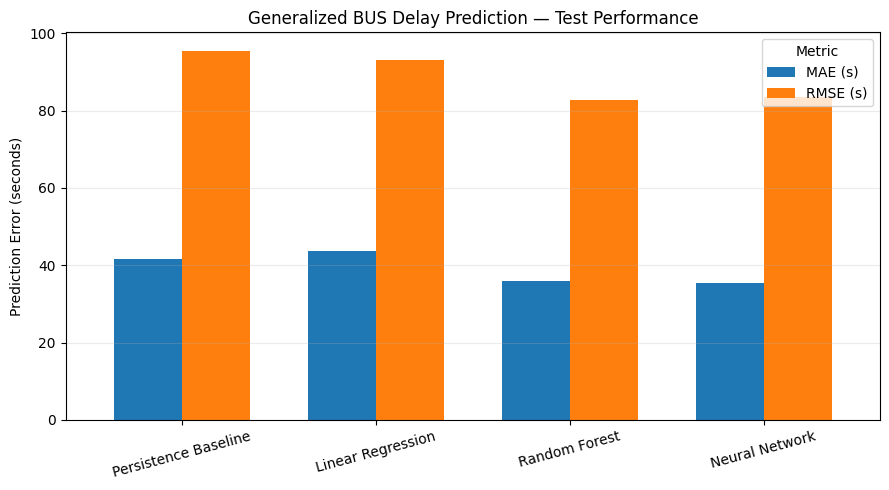

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plot_data = test_results.set_index("Model")[["MAE (s)", "RMSE (s)"]]

ax = plot_data.plot(
    kind="bar",
    figsize=(9, 5),
    width=0.7
)

ax.set_title("Generalized BUS Delay Prediction — Test Performance")
ax.set_ylabel("Prediction Error (seconds)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=15)
ax.legend(title="Metric")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

Random Forest achieves the lowest MAE and RMSE on the held-out test dataset, followed closely by the Neural Network. Both nonlinear models outperform Linear Regression and the persistence baseline across the two error metrics.

## 5.5 Generalization Analysis

To examine route-level generalization, the network-wide prediction models are evaluated separately on Line 507, which was the focus of the specialized modelling approach. Only observations from the held-out November–December test period are considered, allowing the generalized models to be assessed on the same route without additional training.

In [ ]:
ROUTE_COL = "route_id"  # Change if necessary

# Read only the route identifier column (not the full dataset)
routes = pd.read_parquet(
    test_file,
    columns=[ROUTE_COL]
)

# Display unique route IDs containing 507
unique_routes = routes[ROUTE_COL].astype(str).unique()

matching_routes = [
    route for route in unique_routes
    if "507" in route
]

print("Possible Line 507 identifiers:")
print(matching_routes)

Possible Line 507 identifiers:
['9011001050700000']


In [ ]:
LINE_507 = "9011001050700000"

line_507_counts = {}

for month in test_months:

    path = f"{PROCESSED_PATH}/bus_delay_2024{month:02d}.parquet"

    df = pd.read_parquet(
        path,
        columns=["route_id"],
        filters=[("route_id", "==", LINE_507)]
    )

    line_507_counts[f"2024-{month:02d}"] = len(df)

    print(f"2024-{month:02d}: {len(df):,} Line 507 observations")

    del df

print(f"\nTotal Line 507 test observations: {sum(line_507_counts.values()):,}")

2024-11: 32,544 Line 507 observations
2024-12: 31,679 Line 507 observations

Total Line 507 test observations: 64,223


### 5.5.1 Line 507 Prediction Performance

The generalized prediction models are evaluated separately on 64,223 eligible Line 507 observations from November–December 2024. The same trained models and preprocessing transformations are retained to assess route-specific performance without additional fitting.

In [ ]:
# Evaluate generalized models on Line 507

line_results = []
line_data = []

for month in test_months:

    path = f"{PROCESSED_PATH}/bus_delay_2024{month:02d}.parquet"

    df = pd.read_parquet(
        path,
        columns=["route_id"] + features + [target],
        filters=[("route_id", "==", LINE_507)]
    )

    line_data.append(df)

line_507_test = pd.concat(line_data, ignore_index=True)

X_line = line_507_test[features]
y_line = line_507_test[target].to_numpy(dtype=np.float64)

X_line_scaled = scaler.transform(
    X_line.to_numpy(dtype=np.float64)
)

line_predictions = {
    "Persistence Baseline":
        line_507_test["upstream_delay"].to_numpy(dtype=np.float64),

    "Linear Regression":
        linear_model.predict(X_line_scaled),

    "Random Forest":
        rf_model.predict(X_line),

    "Neural Network":
        nn_model.predict(
            X_line_scaled.astype(np.float32),
            batch_size=2048,
            verbose=0
        ).ravel()
}

for name, predictions in line_predictions.items():

    line_results.append({
        "Model": name,
        "MAE (s)": mean_absolute_error(y_line, predictions),
        "RMSE (s)": np.sqrt(mean_squared_error(y_line, predictions)),
        "R²": r2_score(y_line, predictions)
    })

line_507_results = pd.DataFrame(line_results)

print(f"Line 507 test observations: {len(y_line):,}")
display(line_507_results.round(4))

Line 507 test observations: 64,223


,Model,MAE (s),RMSE (s),R²
0,Persistence Baseline,53.4352,97.0762,0.8267
1,Linear Regression,56.8348,96.6569,0.8282
2,Random Forest,54.1396,89.7766,0.8518
3,Neural Network,50.8596,88.4537,0.8561


On the 64,223 held-out Line 507 observations from November–December 2024, the tuned generalized Neural Network achieves the lowest prediction errors across all three evaluation metrics (MAE = 50.86 seconds, RMSE = 88.45 seconds, R² = 0.8561). The Random Forest records an MAE of 54.14 seconds and an RMSE of 89.78 seconds, while the persistence baseline achieves an MAE of 53.44 seconds.

Compared with its network-wide test performance (MAE = 35.31 seconds), the Neural Network exhibits higher prediction errors on Line 507, indicating that predictive performance varies across evaluation populations. Nevertheless, the validation-selected Neural Network retains its relative advantage in average absolute prediction accuracy when evaluated separately on Line 507, without additional training or route-specific adaptation.

### 5.5.2 Network-Wide and Line 507 Comparison

Prediction performance is compared between the complete held-out BUS dataset and its Line 507 subset. This analysis examines differences in model behaviour across evaluation populations without retraining or modifying the generalized models.

In [ ]:
# Compare network-wide and Line 507 test performance

network_comparison = test_results.copy()
network_comparison["Evaluation Set"] = "Network-wide"

line_comparison = line_507_results.copy()
line_comparison["Evaluation Set"] = "Line 507"

generalization_comparison = pd.concat(
    [network_comparison, line_comparison],
    ignore_index=True
)

generalization_comparison = generalization_comparison[
    ["Evaluation Set", "Model", "MAE (s)", "RMSE (s)", "R²"]
]

display(generalization_comparison.round(4))

,Evaluation Set,Model,MAE (s),RMSE (s),R²
0,Network-wide,Persistence Baseline,41.5550,95.4705,0.8086
1,Network-wide,Linear Regression,43.7473,93.0901,0.8180
2,Network-wide,Random Forest,35.9979,82.6600,0.8565
3,Network-wide,Neural Network,35.3059,83.4016,0.8539
4,Line 507,Persistence Baseline,53.4352,97.0762,0.8267
5,Line 507,Linear Regression,56.8348,96.6569,0.8282
6,Line 507,Random Forest,54.1396,89.7766,0.8518
7,Line 507,Neural Network,50.8596,88.4537,0.8561


Across all four prediction approaches, MAE is higher on Line 507 than on the complete BUS network. The tuned Neural Network achieves the lowest MAE in both evaluation populations, recording 35.31 seconds network-wide and 50.86 seconds on Line 507. On the complete BUS network, Random Forest achieves the lowest RMSE (82.66 seconds) and highest R² (0.8565), whereas the Neural Network achieves the lowest RMSE (88.45 seconds) and highest R² (0.8561) on Line 507.

These differences indicate that network-wide prediction performance does not necessarily reflect accuracy on an individual route. In particular, the selected generalized Neural Network exhibits an MAE increase of approximately 15.55 seconds when evaluated specifically on Line 507. As Line 507 is a subset of the network-wide test dataset, these results represent route-specific performance of the same generalized models rather than independently trained or adapted models.

#**6. Generalized vs. Specialized Line 507 Models**

To investigate the effect of training scope on prediction performance, the selected generalized model and the specialized Line 507 model are evaluated across individual BUS routes using the held-out November–December 2024 dataset.

Both models are evaluated without additional training or adaptation, using their respective original preprocessing procedures and identical test observations. Performance is assessed separately for each route using MAE, RMSE and R², allowing cross-route variation and the transferability of the specialized model to be examined.

Particular attention is given to Line 507, as this is the route on which the specialized model was trained. Its performance is compared against the generalized model on the same Line 507 observations.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import json
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf

PROJECT_PATH = "/content/drive/MyDrive/Project AI in Transportation"

DELAY_PATH = f"{PROJECT_PATH}/bus_delay_prediction"
PROCESSED_PATH = f"{DELAY_PATH}/processed"
RESULTS_PATH = f"{DELAY_PATH}/results"

GENERALIZED_MODEL_PATH = f"{PROJECT_PATH}/models/generalized"
SPECIALIZED_MODEL_PATH = f"{PROJECT_PATH}/models/specialized"

target = "observed_arrival_delay"
test_months = [11, 12]

LINE_507 = "9011001050700000"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Load Generalised Model

In [ ]:
# Load the final generalized Neural Network
generalized_nn = tf.keras.models.load_model(
    f"{GENERALIZED_MODEL_PATH}/generalized_nn.keras"
)

# Load its ORIGINAL fitted scaler
generalized_scaler = joblib.load(
    f"{GENERALIZED_MODEL_PATH}/generalized_nn_scaler.joblib"
)

# Load the exact feature list and order used during training
generalized_features = joblib.load(
    f"{GENERALIZED_MODEL_PATH}/generalized_nn_features.joblib"
)

# Load the selected hyperparameters
with open(
    f"{GENERALIZED_MODEL_PATH}/generalized_nn_hyperparameters.json",
    "r"
) as f:
    generalized_params = json.load(f)

# Normalize batch size (saved as a string in your JSON)
generalized_params["batch_size"] = int(
    generalized_params["batch_size"]
)

print("Generalized NN loaded successfully.")
print("\nFeatures:", generalized_features)
print("\nSelected hyperparameters:", generalized_params)

Generalized NN loaded successfully.

Features: ['upstream_delay', 'hour', 'weekday', 'is_weekend', 'month', 'hour_sin', 'hour_cos', 'stop_sequence', 'dist_traveled']

Selected hyperparameters: {'hidden_units': [128, 64], 'learning_rate': 0.0005, 'batch_size': 512, 'dropout': 0.1}


In [ ]:
# Check the model expects the correct number of input features
assert generalized_nn.input_shape[-1] == len(generalized_features), (
    "Model input dimension does not match the saved feature list."
)

# Check the scaler expects the same number of features
assert generalized_scaler.n_features_in_ == len(generalized_features), (
    "Scaler feature count does not match the saved feature list."
)

# Check the exact feature order
if hasattr(generalized_scaler, "feature_names_in_"):
    assert list(generalized_scaler.feature_names_in_) == list(
        generalized_features
    ), "Scaler feature order does not match the saved feature list."

print("All compatibility checks passed.")

generalized_nn.summary()

All compatibility checks passed.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,805 (112.52 KB)

 Trainable params: 9,601 (37.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,204 (75.02 KB)

In [ ]:
def predict_generalized_nn(df, batch_size=2048):
    """
    Predict arrival delays using the frozen generalized NN.

    Uses the original saved feature order and fitted scaler.
    Does not retrain or refit anything.
    """

    # Preserve the exact training feature order
    X = df[generalized_features].astype(np.float64)

    # Transform using the ORIGINAL fitted scaler
    X_scaled = generalized_scaler.transform(X).astype(np.float32)

    # Generate predictions
    predictions = generalized_nn.predict(
        X_scaled,
        batch_size=batch_size,
        verbose=0
    ).reshape(-1)

    assert len(predictions) == len(df)

    return predictions

In [ ]:
from collections import defaultdict
from sklearn.metrics import mean_absolute_error

ROUTE_COL = "route_id"

def make_route_accumulator():
    return {
        "n": 0,
        "sum_abs_error": 0.0,
        "sum_sq_error": 0.0,
        "sum_y": 0.0,
        "sum_y2": 0.0
    }


route_stats = defaultdict(make_route_accumulator)

In [ ]:
BATCH_SIZE = 100_000

for month in test_months:

    file_path = (
        f"{PROCESSED_PATH}/bus_delay_2024{month:02d}.parquet"
    )

    print(f"\nProcessing month {month:02d}...")

    parquet_file = pq.ParquetFile(file_path)

    required_columns = list(dict.fromkeys(
        generalized_features + [target, ROUTE_COL]
    ))

    month_count = 0

    for batch in parquet_file.iter_batches(
        batch_size=BATCH_SIZE,
        columns=required_columns
    ):

        df = batch.to_pandas()

        # Actual arrival delays
        y_true = df[target].to_numpy(dtype=np.float64)

        # Predictions from the frozen generalized NN
        y_pred = predict_generalized_nn(df).astype(np.float64)

        assert len(y_true) == len(y_pred) == len(df)

        # Calculate individual errors
        abs_error = np.abs(y_true - y_pred)
        sq_error = (y_true - y_pred) ** 2

        # Aggregate within this batch by route
        batch_results = pd.DataFrame({
            "route_id": df[ROUTE_COL].astype(str).to_numpy(),
            "y_true": y_true,
            "y_true_sq": y_true ** 2,
            "abs_error": abs_error,
            "sq_error": sq_error
        })

        grouped = batch_results.groupby(
            "route_id", sort=False
        ).agg(
            n=("y_true", "size"),
            sum_y=("y_true", "sum"),
            sum_y2=("y_true_sq", "sum"),
            sum_abs_error=("abs_error", "sum"),
            sum_sq_error=("sq_error", "sum")
        )

        # Accumulate across batches and months
        for route_id, values in grouped.iterrows():

            stats = route_stats[route_id]

            stats["n"] += int(values["n"])
            stats["sum_y"] += float(values["sum_y"])
            stats["sum_y2"] += float(values["sum_y2"])
            stats["sum_abs_error"] += float(
                values["sum_abs_error"]
            )
            stats["sum_sq_error"] += float(
                values["sum_sq_error"]
            )

        month_count += len(df)

    print(f"Processed {month_count:,} observations.")

print("\nGeneralized NN per-route evaluation completed.")


Processing month 11...
Processed 12,051,223 observations.

Processing month 12...
Processed 11,905,032 observations.

Generalized NN per-route evaluation completed.


In [ ]:
results = []

for route_id, stats in route_stats.items():

    n = stats["n"]

    mae = stats["sum_abs_error"] / n

    rmse = np.sqrt(
        stats["sum_sq_error"] / n
    )

    # Total sum of squares for R²
    ss_tot = (
        stats["sum_y2"]
        - (stats["sum_y"] ** 2 / n)
    )

    if n >= 2 and ss_tot > 0:
        r2 = 1 - stats["sum_sq_error"] / ss_tot
    else:
        r2 = np.nan

    results.append({
        "route_id": route_id,
        "n_observations": n,
        "generalized_MAE": mae,
        "generalized_RMSE": rmse,
        "generalized_R2": r2
    })

generalized_route_results = pd.DataFrame(results)

generalized_route_results = (
    generalized_route_results
    .sort_values("generalized_MAE")
    .reset_index(drop=True)
)

print(
    "Number of evaluated routes:",
    len(generalized_route_results)
)

display(generalized_route_results.round(4))

Number of evaluated routes: 528


,route_id,n_observations,generalized_MAE,generalized_RMSE,generalized_R2
0,9011001064400000,9430,15.2751,58.1575,0.9456
1,9011001019900000,3883,15.8023,29.8622,0.9531
2,9011001064300000,25531,15.9536,31.8326,0.9543
3,9011001063700000,153488,16.9155,34.6914,0.9579
4,9011001064200000,29817,17.0278,29.8831,0.9566
...,...,...,...,...,...
523,9011001095500000,4331,162.9337,376.0919,0.6417
524,9011001098600000-43D,292,227.0167,410.6986,0.2990
525,9011001065300000-653V,7,240.9000,277.5524,-0.3769
526,9011001098600000,162,246.1921,325.1100,-0.0387


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
line_507_result = generalized_route_results[
    generalized_route_results["route_id"] == LINE_507
]

print("Generalized NN — Line 507:")
display(line_507_result.round(4))

assert len(line_507_result) == 1, (
    "Line 507 was not found in the per-route results."
)

assert int(
    line_507_result["n_observations"].iloc[0]
) == 64_223, "Unexpected Line 507 observation count."

assert np.isclose(
    line_507_result["generalized_MAE"].iloc[0],
    50.8596,
    atol=0.01
), "Line 507 MAE differs from the earlier evaluation."

# Save the complete per-route results
RESULTS_PATH = f"{DELAY_PATH}/results"

os.makedirs(RESULTS_PATH, exist_ok=True)

output_path = (
    f"{RESULTS_PATH}/generalized_nn_per_route_test_2024.csv"
)

generalized_route_results.to_csv(
    output_path,
    index=False
)

print(f"\nResults saved to:\n{output_path}")

Generalized NN — Line 507:


,route_id,n_observations,generalized_MAE,generalized_RMSE,generalized_R2
429,9011001050700000,64223,50.8594,88.4096,0.8563



Results saved to:
/content/drive/MyDrive/Project AI in Transportation/bus_delay_prediction/results/generalized_nn_per_route_test_2024.csv


In [ ]:
# Inspect the routes with the highest prediction errors

display(
    generalized_route_results
    .sort_values("generalized_MAE", ascending=False)
    .head(20)[
        ["route_id", "n_observations",
         "generalized_MAE", "generalized_RMSE", "generalized_R2"]
    ]
    .round(4)
)

print("\nRoute observation-count distribution:")

display(
    generalized_route_results["n_observations"]
    .describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50])
    .round(2)
)

,route_id,n_observations,generalized_MAE,generalized_RMSE,generalized_R2
527,9011001098600000-43H,164,262.1889,518.3192,0.1996
526,9011001098600000,162,246.1921,325.1100,-0.0387
525,9011001065300000-653V,7,240.9000,277.5524,-0.3769
524,9011001098600000-43D,292,227.0167,410.6986,0.2990
523,9011001095500000,4331,162.9337,376.0919,0.6417
522,9011001095800000,21255,139.6168,262.7555,0.1559
521,9011001086200000,207,135.6772,312.7642,0.0794
520,9011001074900000,3212,127.1624,245.7360,0.5384
519,9011001058300000,19471,126.2702,168.1002,-0.1271
518,9011001086100000,2831,119.5017,233.8104,0.5117



Route observation-count distribution:


,n_observations
count,528.00
mean,45371.70
std,51837.74
min,7.00
1%,210.51
5%,1290.75
10%,2854.10
25%,8289.25
50%,24251.50
max,305438.00


In [ ]:
MIN_ROUTE_OBS = 1_000

# Keep all original results unchanged
generalized_route_results_all = generalized_route_results.copy()

# Apply the minimum observation threshold
eligible_routes = generalized_route_results_all[
    generalized_route_results_all["n_observations"] >= MIN_ROUTE_OBS
].copy()

print(
    "Total routes:",
    len(generalized_route_results_all)
)

print(
    "Routes with at least 1,000 observations:",
    len(eligible_routes)
)

print(
    "Excluded routes:",
    len(generalized_route_results_all) - len(eligible_routes)
)

print(
    "Percentage of test observations retained:",
    round(
        100
        * eligible_routes["n_observations"].sum()
        / generalized_route_results_all["n_observations"].sum(),
        2
    ),
    "%"
)

# Confirm that Line 507 is included
assert LINE_507 in eligible_routes["route_id"].values

Total routes: 528
Routes with at least 1,000 observations: 508
Excluded routes: 20
Percentage of test observations retained: 99.96 %


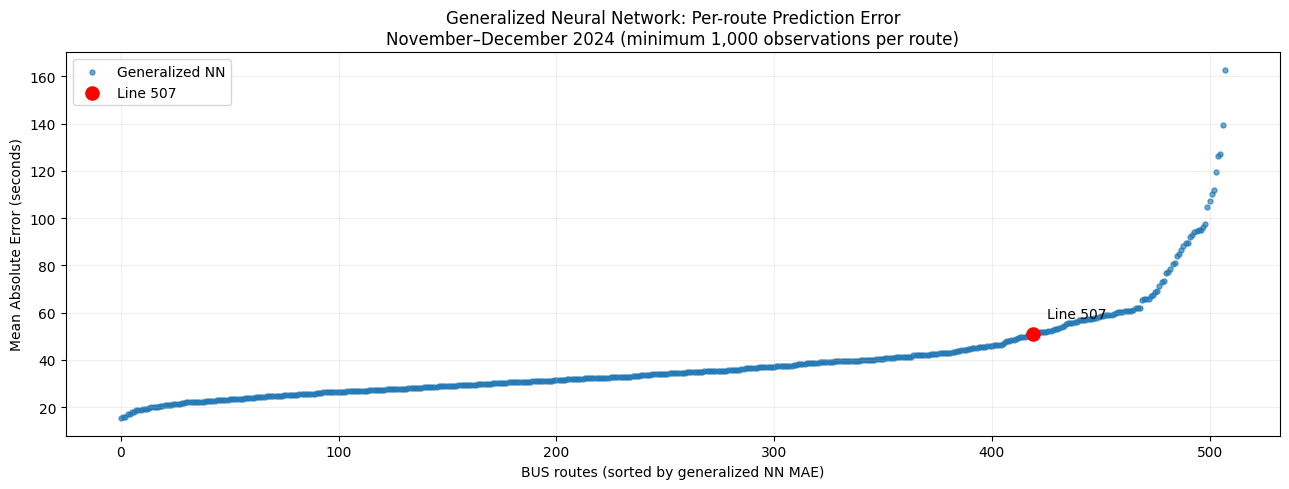

In [ ]:
plot_df = eligible_routes.sort_values(
    "generalized_MAE"
).reset_index(drop=True)

plt.figure(figsize=(13, 5))

plt.scatter(
    range(len(plot_df)),
    plot_df["generalized_MAE"],
    s=13,
    alpha=0.65,
    label="Generalized NN"
)

# Highlight Line 507
line_507 = plot_df[
    plot_df["route_id"] == LINE_507
]

idx = line_507.index[0]
mae_507 = line_507["generalized_MAE"].iloc[0]

plt.scatter(
    idx,
    mae_507,
    color="red",
    s=90,
    zorder=5,
    label="Line 507"
)

plt.annotate(
    "Line 507",
    (idx, mae_507),
    xytext=(10, 12),
    textcoords="offset points"
)

plt.xlabel("BUS routes (sorted by generalized NN MAE)")
plt.ylabel("Mean Absolute Error (seconds)")

plt.title(
    "Generalized Neural Network: Per-route Prediction Error\n"
    "November–December 2024 (minimum 1,000 observations per route)"
)

plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
figure_path = (
    f"{RESULTS_PATH}/generalized_nn_per_route_mae.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Per-route Mean Absolute Error (MAE) of the selected generalized Neural Network on the November–December 2024 BUS test dataset. Routes are ordered by increasing MAE, and only routes containing at least 1,000 test observations are displayed. Line 507 is highlighted separately.

The results demonstrate variation in the generalized Neural Network's prediction accuracy across individual BUS routes. Most eligible routes exhibit relatively moderate prediction errors, while a smaller subset records substantially higher MAE values. Line 507 achieves an MAE of approximately 50.86 seconds, placing it toward the higher-error portion of the route distribution. This indicates that the generalized model's overall network-wide performance does not fully represent its predictive accuracy on every individual route.

Load Specialised Model

In [ ]:
import os
import json
import joblib

SPECIALIZED_MODEL_PATH = f"{PROJECT_PATH}/models/specialized"

# Load the final specialized Random Forest
specialized_rf = joblib.load(
    f"{SPECIALIZED_MODEL_PATH}/line507_random_forest.joblib"
)

# Load its exact feature list and order
specialized_features = joblib.load(
    f"{SPECIALIZED_MODEL_PATH}/line507_features.joblib"
)

# Load the accompanying model information
with open(
    f"{SPECIALIZED_MODEL_PATH}/line507_rf_model_info.json",
    "r"
) as f:
    specialized_info = json.load(f)

print("Specialized Random Forest loaded successfully.")

print("\nFeatures:")
print(specialized_features)

print("\nModel information:")
print(json.dumps(specialized_info, indent=4, default=str))

Specialized Random Forest loaded successfully.

Features:
['hour', 'weekday', 'is_weekend', 'month', 'hour_sin', 'hour_cos', 'stop_sequence', 'dist_traveled', 'upstream_delay']

Model information:
{
    "model": "RandomForestRegressor",
    "line_id": "9011001050700000",
    "selection_metric": "MAE",
    "selection_period": "October 2024 validation",
    "validation_results": {
        "MAE_seconds": 32.22,
        "RMSE_seconds": 58.77,
        "R2": 0.9385
    },
    "training_period": "January-September 2024",
    "hyperparameters": {
        "bootstrap": true,
        "ccp_alpha": 0.0,
        "criterion": "squared_error",
        "max_depth": 25,
        "max_features": 0.7,
        "max_leaf_nodes": null,
        "max_samples": null,
        "min_impurity_decrease": 0.0,
        "min_samples_leaf": 10,
        "min_samples_split": 2,
        "min_weight_fraction_leaf": 0.0,
        "monotonic_cst": null,
        "n_estimators": 100,
        "n_jobs": -1,
        "oob_score": fal

In [ ]:
# Normalize the feature list to a regular Python list
specialized_features = list(specialized_features)

print("Generalized NN features:")
print(generalized_features)

print("\nSpecialized RF features:")
print(specialized_features)

# Check the number of features expected by the RF
assert specialized_rf.n_features_in_ == len(specialized_features), (
    "Specialized model input dimension does not match its feature list."
)

# If the RF was trained with named DataFrame columns,
# verify their exact order as well.
if hasattr(specialized_rf, "feature_names_in_"):
    assert list(specialized_rf.feature_names_in_) == specialized_features, (
        "Specialized RF feature order does not match the saved feature list."
    )

# Verify that the required columns exist in the test parquet file
import pyarrow.parquet as pq

test_schema = pq.read_schema(
    f"{PROCESSED_PATH}/bus_delay_202411.parquet"
)

missing_features = [
    feature for feature in specialized_features
    if feature not in test_schema.names
]

assert not missing_features, (
    f"Missing specialized model features: {missing_features}"
)

print("\nAll compatibility checks passed!")

Generalized NN features:
['upstream_delay', 'hour', 'weekday', 'is_weekend', 'month', 'hour_sin', 'hour_cos', 'stop_sequence', 'dist_traveled']

Specialized RF features:
['hour', 'weekday', 'is_weekend', 'month', 'hour_sin', 'hour_cos', 'stop_sequence', 'dist_traveled', 'upstream_delay']

All compatibility checks passed!


In [ ]:
from collections import defaultdict

# Same test period as the generalized model
test_months = [11, 12]
BATCH_SIZE = 100_000

specialized_route_stats = defaultdict(make_route_accumulator)

for month in test_months:

    file_path = (
        f"{PROCESSED_PATH}/bus_delay_2024{month:02d}.parquet"
    )

    print(f"\nProcessing month {month:02d}...")

    parquet_file = pq.ParquetFile(file_path)

    required_columns = list(dict.fromkeys(
        specialized_features + [target, ROUTE_COL]
    ))

    month_count = 0

    for batch in parquet_file.iter_batches(
        batch_size=BATCH_SIZE,
        columns=required_columns
    ):

        df = batch.to_pandas()

        # Same observations, target and route IDs
        y_true = df[target].to_numpy(dtype=np.float64)

        # Original specialized RF feature order; NO scaler
        X_specialized = df[specialized_features]

        y_pred = np.asarray(
            specialized_rf.predict(X_specialized),
            dtype=np.float64
        ).reshape(-1)

        assert len(y_true) == len(y_pred) == len(df)

        batch_results = pd.DataFrame({
            "route_id": df[ROUTE_COL].astype(str).to_numpy(),
            "y_true": y_true,
            "y_true_sq": y_true ** 2,
            "abs_error": np.abs(y_true - y_pred),
            "sq_error": (y_true - y_pred) ** 2
        })

        grouped = batch_results.groupby(
            "route_id", sort=False
        ).agg(
            n=("y_true", "size"),
            sum_y=("y_true", "sum"),
            sum_y2=("y_true_sq", "sum"),
            sum_abs_error=("abs_error", "sum"),
            sum_sq_error=("sq_error", "sum")
        )

        for route_id, values in grouped.iterrows():

            stats = specialized_route_stats[route_id]

            stats["n"] += int(values["n"])
            stats["sum_y"] += float(values["sum_y"])
            stats["sum_y2"] += float(values["sum_y2"])
            stats["sum_abs_error"] += float(
                values["sum_abs_error"]
            )
            stats["sum_sq_error"] += float(
                values["sum_sq_error"]
            )

        month_count += len(df)

    print(f"Processed {month_count:,} observations.")

print("\nSpecialized RF per-route evaluation completed.")


Processing month 11...
Processed 12,051,223 observations.

Processing month 12...
Processed 11,905,032 observations.

Specialized RF per-route evaluation completed.


In [ ]:
specialized_results = []

for route_id, stats in specialized_route_stats.items():

    n = stats["n"]

    mae = stats["sum_abs_error"] / n

    rmse = np.sqrt(
        stats["sum_sq_error"] / n
    )

    ss_tot = (
        stats["sum_y2"]
        - (stats["sum_y"] ** 2 / n)
    )

    r2 = (
        1 - stats["sum_sq_error"] / ss_tot
        if n >= 2 and ss_tot > 0
        else np.nan
    )

    specialized_results.append({
        "route_id": route_id,
        "n_observations": n,
        "specialized_MAE": mae,
        "specialized_RMSE": rmse,
        "specialized_R2": r2
    })

specialized_route_results = pd.DataFrame(
    specialized_results
).sort_values(
    "specialized_MAE"
).reset_index(drop=True)

# Save the complete results, before applying any threshold
specialized_output_path = (
    f"{RESULTS_PATH}/specialized_rf_per_route_test_2024.csv"
)

specialized_route_results.to_csv(
    specialized_output_path,
    index=False
)

print("Number of evaluated routes:", len(specialized_route_results))
print("Total observations:", specialized_route_results["n_observations"].sum())
print("Saved to:", specialized_output_path)

display(specialized_route_results.round(4))

Number of evaluated routes: 528
Total observations: 23956255
Saved to: /content/drive/MyDrive/Project AI in Transportation/bus_delay_prediction/results/specialized_rf_per_route_test_2024.csv


,route_id,n_observations,specialized_MAE,specialized_RMSE,specialized_R2
0,9011001028200000,532,19.2738,27.5424,0.8207
1,9011001072300000,43579,28.3852,68.7430,0.6294
2,9011001011400000,52818,28.8628,94.9848,0.6861
3,9011001015900000,4260,29.4357,38.4354,0.8810
4,9011001060600000,46596,30.8485,44.3773,0.8599
...,...,...,...,...,...
523,9011001095500000,4331,184.9126,378.8098,0.6365
524,9011001098600000-43D,292,221.5884,410.9630,0.2981
525,9011001098600000,162,238.1352,323.4452,-0.0281
526,9011001098600000-43H,164,280.8408,540.2280,0.1305


Total routes: 528
Eligible routes: 508
Excluded routes: 20


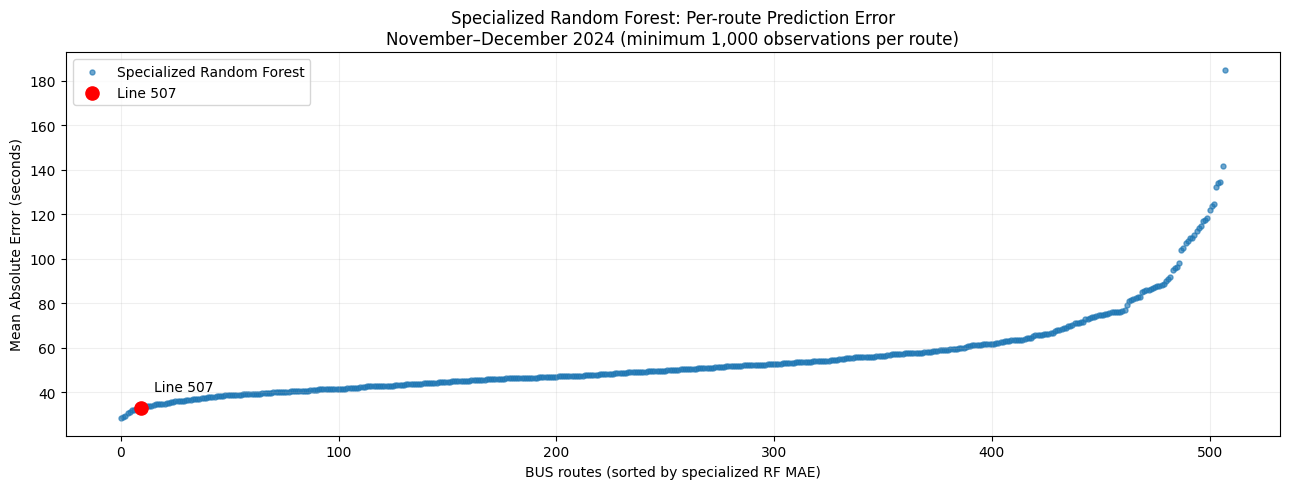

Figure saved to: /content/drive/MyDrive/Project AI in Transportation/bus_delay_prediction/results/specialized_rf_per_route_mae.png


In [ ]:
import matplotlib.pyplot as plt

MIN_ROUTE_OBS = 1_000

# Keep only routes with at least 1,000 test observations
specialized_eligible_routes = specialized_route_results[
    specialized_route_results["n_observations"] >= MIN_ROUTE_OBS
].copy()

print(
    "Total routes:",
    len(specialized_route_results)
)

print(
    "Eligible routes:",
    len(specialized_eligible_routes)
)

print(
    "Excluded routes:",
    len(specialized_route_results) - len(specialized_eligible_routes)
)

# Sort by specialized RF MAE
plot_df_specialized = specialized_eligible_routes.sort_values(
    "specialized_MAE"
).reset_index(drop=True)

# Create the graph
plt.figure(figsize=(13, 5))

plt.scatter(
    range(len(plot_df_specialized)),
    plot_df_specialized["specialized_MAE"],
    s=13,
    alpha=0.65,
    label="Specialized Random Forest"
)

# Highlight Line 507
line_507 = plot_df_specialized[
    plot_df_specialized["route_id"].astype(str) == str(LINE_507)
]

assert not line_507.empty, "Line 507 was not found."

idx = line_507.index[0]
mae_507 = line_507["specialized_MAE"].iloc[0]

plt.scatter(
    idx,
    mae_507,
    color="red",
    s=90,
    zorder=5,
    label="Line 507"
)

plt.annotate(
    "Line 507",
    (idx, mae_507),
    xytext=(10, 12),
    textcoords="offset points"
)

plt.xlabel("BUS routes (sorted by specialized RF MAE)")
plt.ylabel("Mean Absolute Error (seconds)")

plt.title(
    "Specialized Random Forest: Per-route Prediction Error\n"
    "November–December 2024 (minimum 1,000 observations per route)"
)

plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()

# Save the figure to Google Drive
figure_path = (
    f"{RESULTS_PATH}/specialized_rf_per_route_mae.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", figure_path)

In [ ]:
generalized_results_path = (
    f"{RESULTS_PATH}/generalized_nn_per_route_test_2024.csv"
)

generalized_route_results = pd.read_csv(
    generalized_results_path,
    dtype={"route_id": str}
)

In [ ]:
# Compare observation counts across the two evaluations
count_check = generalized_route_results[
    ["route_id", "n_observations"]
].merge(
    specialized_route_results[
        ["route_id", "n_observations"]
    ],
    on="route_id",
    how="outer",
    suffixes=("_generalized", "_specialized"),
    validate="one_to_one",
    indicator=True
)

assert (count_check["_merge"] == "both").all(), (
    "The evaluations do not contain identical route sets."
)

assert (
    count_check["n_observations_generalized"]
    == count_check["n_observations_specialized"]
).all(), "Observation counts differ between the two models."

assert (
    count_check["n_observations_generalized"].sum()
    == 23_956_255
), "Unexpected total test observation count."

print("Both evaluations contain the same routes and observation counts!")

# Display Line 507 specialized results
line_507_specialized = specialized_route_results[
    specialized_route_results["route_id"] == LINE_507
].reset_index(drop=True)

assert len(line_507_specialized) == 1
assert int(line_507_specialized["n_observations"].iloc[0]) == 64_223

print("\nSpecialized RF — Line 507:")
display(line_507_specialized.round(4))

Both evaluations contain the same routes and observation counts!

Specialized RF — Line 507:


,route_id,n_observations,specialized_MAE,specialized_RMSE,specialized_R2
0,9011001050700000,64223,32.9796,69.8625,0.9102


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load both saved result files
generalized_route_results = pd.read_csv(
    f"{RESULTS_PATH}/generalized_nn_per_route_test_2024.csv",
    dtype={"route_id": str}
)

specialized_route_results = pd.read_csv(
    f"{RESULTS_PATH}/specialized_rf_per_route_test_2024.csv",
    dtype={"route_id": str}
)

# Merge using the route identifier
comparison = generalized_route_results.merge(
    specialized_route_results,
    on=["route_id", "n_observations"],
    how="inner",
    validate="one_to_one"
)

# Verify that no routes were lost
assert len(comparison) == len(generalized_route_results)
assert len(comparison) == len(specialized_route_results)

# Apply the same minimum observation threshold
MIN_ROUTE_OBS = 1_000

comparison_eligible = comparison[
    comparison["n_observations"] >= MIN_ROUTE_OBS
].copy()

# Positive difference = generalized NN has lower MAE
# Negative difference = specialized RF has lower MAE
comparison_eligible["MAE_difference"] = (
    comparison_eligible["specialized_MAE"]
    - comparison_eligible["generalized_MAE"]
)

print("Total routes:", len(comparison))
print("Eligible routes:", len(comparison_eligible))

display(comparison_eligible.head().round(4))

Total routes: 528
Eligible routes: 508


,route_id,n_observations,generalized_MAE,generalized_RMSE,generalized_R2,specialized_MAE,specialized_RMSE,specialized_R2,MAE_difference
0,9011001064400000,9430,15.2751,58.1575,0.9456,32.7242,68.8049,0.9238,17.4491
1,9011001019900000,3883,15.8023,29.8622,0.9531,37.1522,51.3201,0.8615,21.3499
2,9011001064300000,25531,15.9536,31.8326,0.9543,38.3348,55.0540,0.8632,22.3813
3,9011001063700000,153488,16.9155,34.6914,0.9579,41.5536,61.8885,0.8659,24.6381
4,9011001064200000,29817,17.0278,29.8831,0.9566,36.0773,54.3486,0.8564,19.0495


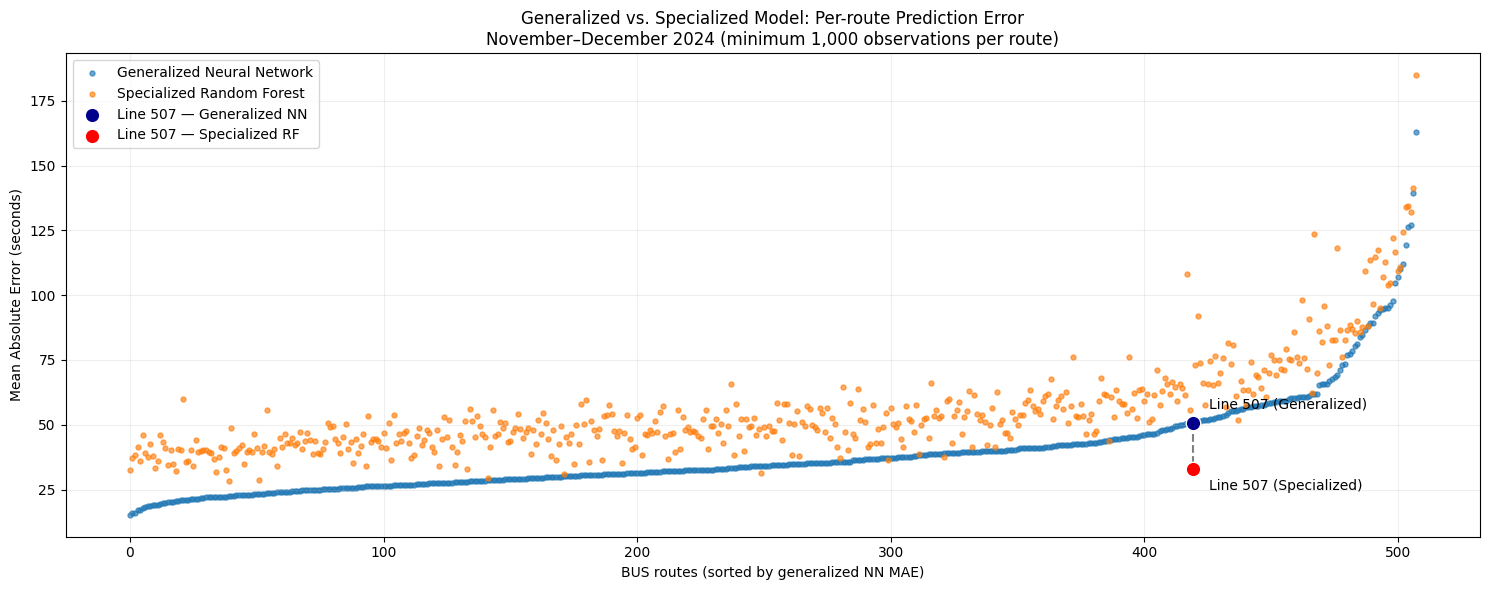

In [ ]:
# Use ONE common route ordering for both models
plot_comparison = comparison_eligible.sort_values(
    "generalized_MAE"
).reset_index(drop=True)

x = np.arange(len(plot_comparison))

plt.figure(figsize=(15, 6))

plt.scatter(
    x,
    plot_comparison["generalized_MAE"],
    s=13,
    alpha=0.65,
    label="Generalized Neural Network"
)

plt.scatter(
    x,
    plot_comparison["specialized_MAE"],
    s=13,
    alpha=0.65,
    label="Specialized Random Forest"
)

# Highlight Line 507 separately for each model
line_507 = plot_comparison[
    plot_comparison["route_id"] == LINE_507
]

assert len(line_507) == 1

idx = line_507.index[0]

generalized_507_mae = line_507["generalized_MAE"].iloc[0]
specialized_507_mae = line_507["specialized_MAE"].iloc[0]

# Generalized NN — Line 507
plt.scatter(
    idx,
    generalized_507_mae,
    color="darkblue",
    edgecolor="white",
    linewidth=1,
    s=110,
    zorder=6,
    label="Line 507 — Generalized NN"
)

# Specialized RF — Line 507
plt.scatter(
    idx,
    specialized_507_mae,
    color="red",
    edgecolor="white",
    linewidth=1,
    s=110,
    zorder=6,
    label="Line 507 — Specialized RF"
)

# Connect both Line 507 results to emphasize their difference
plt.plot(
    [idx, idx],
    [generalized_507_mae, specialized_507_mae],
    color="gray",
    linestyle="--",
    linewidth=1.5,
    zorder=4
)

plt.annotate(
    "Line 507 (Generalized)",
    (idx, generalized_507_mae),
    xytext=(12, 10),
    textcoords="offset points"
)

plt.annotate(
    "Line 507 (Specialized)",
    (idx, specialized_507_mae),
    xytext=(12, -15),
    textcoords="offset points"
)
plt.xlabel("BUS routes (sorted by generalized NN MAE)")
plt.ylabel("Mean Absolute Error (seconds)")

plt.title(
    "Generalized vs. Specialized Model: Per-route Prediction Error\n"
    "November–December 2024 (minimum 1,000 observations per route)"
)

plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()

# Save to Drive
plt.savefig(
    f"{RESULTS_PATH}/generalized_vs_specialized_per_route_mae.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Positive difference: generalized NN has lower MAE
# Negative difference: specialized RF has lower MAE

comparison_eligible["MAE_difference"] = (
    comparison_eligible["specialized_MAE"]
    - comparison_eligible["generalized_MAE"]
)

n_routes = len(comparison_eligible)

generalized_wins = (
    comparison_eligible["MAE_difference"] > 0
).sum()

specialized_wins = (
    comparison_eligible["MAE_difference"] < 0
).sum()

ties = (
    comparison_eligible["MAE_difference"] == 0
).sum()

print(f"Eligible BUS routes: {n_routes}")

print(
    f"Generalized NN lower MAE: {generalized_wins} routes "
    f"({generalized_wins / n_routes * 100:.2f}%)"
)

print(
    f"Specialized RF lower MAE: {specialized_wins} routes "
    f"({specialized_wins / n_routes * 100:.2f}%)"
)

print(f"Ties: {ties}")

print("\nLine 507 comparison:")

display(
    comparison_eligible.loc[
        comparison_eligible["route_id"] == LINE_507,
        [
            "route_id",
            "n_observations",
            "generalized_MAE",
            "specialized_MAE",
            "MAE_difference"
        ]
    ].round(4)
)

Eligible BUS routes: 508
Generalized NN lower MAE: 502 routes (98.82%)
Specialized RF lower MAE: 6 routes (1.18%)
Ties: 0

Line 507 comparison:


,route_id,n_observations,generalized_MAE,specialized_MAE,MAE_difference
429,9011001050700000,64223,50.8594,32.9796,-17.8798


In [ ]:
line_507_comparison = comparison.loc[
    comparison["route_id"] == LINE_507
]

line_507_metrics = pd.DataFrame({
    "Model": [
        "Generalized Neural Network",
        "Specialized Random Forest"
    ],
    "Observations": [
        int(line_507_comparison["n_observations"].iloc[0])
    ] * 2,
    "MAE (s)": [
        line_507_comparison["generalized_MAE"].iloc[0],
        line_507_comparison["specialized_MAE"].iloc[0]
    ],
    "RMSE (s)": [
        line_507_comparison["generalized_RMSE"].iloc[0],
        line_507_comparison["specialized_RMSE"].iloc[0]
    ],
    "R²": [
        line_507_comparison["generalized_R2"].iloc[0],
        line_507_comparison["specialized_R2"].iloc[0]
    ]
})

display(line_507_metrics.round(4))

,Model,Observations,MAE (s),RMSE (s),R²
0,Generalized Neural Network,64223,50.8594,88.4096,0.8563
1,Specialized Random Forest,64223,32.9796,69.8625,0.9102


#**7. Relationship Between Operational Anomalies and Delay-Prediction Errors**

This additional experiment investigates whether operational conditions identified as anomalous are associated with changes in arrival-delay prediction accuracy.

The validation-selected anomaly detections from Section 4 are linked to the predictions of the selected generalized Neural Network from Section 5 using route identifiers and scheduled 15-minute operational windows. Both analyses use the held-out November–December 2024 period.

Prediction performance is subsequently compared between anomalous and non-anomalous operational windows using MAE and RMSE. The statistical MAD detector is considered first, followed by the Isolation Forest and Autoencoder as complementary analyses.

The objective is to examine the relationship between unusual operational conditions and prediction difficulty, rather than to retrain the prediction model or establish a causal relationship.

In [ ]:
import os
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

PROJECT_PATH = "/content/drive/MyDrive/Project AI in Transportation"

EVALUATION_PATH = (
    f"{PROJECT_PATH}/bus_modeling/evaluation"
)

PROCESSED_PATH = (
    f"{PROJECT_PATH}/bus_delay_prediction/processed"
)

RESULTS_PATH = (
    f"{PROJECT_PATH}/bus_delay_prediction/results"
)

os.makedirs(RESULTS_PATH, exist_ok=True)

# Load the saved held-out anomaly results
anomaly_windows = pd.read_parquet(
    f"{EVALUATION_PATH}/test_route_windows.parquet"
)

anomaly_windows["route_id"] = (
    anomaly_windows["route_id"].astype(str)
)

anomaly_windows["window_start"] = pd.to_datetime(
    anomaly_windows["window_start"]
)

print("Anomaly dataset shape:", anomaly_windows.shape)

print("\nAvailable columns:")
print(anomaly_windows.columns.tolist())

print("\nTest period:")
print(
    anomaly_windows["window_start"].min(),
    "to",
    anomaly_windows["window_start"].max()
)

display(anomaly_windows.head())

Anomaly dataset shape: (1369322, 11)

Available columns:
['route_id', 'window_start', 'constituent_rows', 'total_observations', 'stat_anomaly_score', 'if_anomaly_score', 'ae_anomaly_score', 'stat_detected', 'if_detected', 'ae_detected', 'short_alert_overlap']

Test period:
2024-11-01 00:00:00 to 2025-01-01 01:15:00


,route_id,window_start,constituent_rows,total_observations,stat_anomaly_score,if_anomaly_score,ae_anomaly_score,stat_detected,if_detected,ae_detected,short_alert_overlap
0,9011001000100000,2024-11-01 00:00:00,2,53,0.832705,0.559717,0.240035,False,False,True,False
1,9011001000100000,2024-11-01 00:15:00,2,52,0.799396,0.577500,0.197221,False,True,True,False
2,9011001000100000,2024-11-01 00:30:00,1,32,0.000000,0.472678,0.073461,False,False,False,False
3,9011001000100000,2024-11-01 00:45:00,1,15,0.000000,0.440941,0.112899,False,False,False,False
4,9011001000100000,2024-11-01 05:15:00,1,26,0.000000,0.566835,0.138219,False,False,True,False


In [ ]:
anomaly_flags = [
    "stat_detected",
    "if_detected",
    "ae_detected"
]

assert all(
    col in anomaly_windows.columns
    for col in anomaly_flags
), "One or more anomaly-detection columns are missing."

# Verify unique route–window combinations
assert not anomaly_windows.duplicated(
    ["route_id", "window_start"]
).any(), "Duplicate route–window combinations detected."

print("Anomaly detection rates:")

display(
    (
        anomaly_windows[anomaly_flags]
        .mean()
        .mul(100)
        .rename("Detection rate (%)")
        .round(3)
    )
)

Anomaly detection rates:


,Detection rate (%)
stat_detected,3.090
if_detected,3.409
ae_detected,3.698


In [ ]:
november_file = (
    f"{PROCESSED_PATH}/bus_delay_202411.parquet"
)

prediction_schema = pq.read_schema(november_file)

print("Prediction dataset columns:")
print(prediction_schema.names)

# Read only the columns needed to inspect time alignment
time_sample = next(
    pq.ParquetFile(november_file).iter_batches(
        batch_size=10,
        columns=[
            "date",
            "route_id",
            "scheduled_arrival_time_sfm"
        ]
    )
).to_pandas()

print("\nPrediction time sample:")
display(time_sample)

print("\nAnomaly time sample:")
display(
    anomaly_windows[
        ["route_id", "window_start"]
    ].head(10)
)

Prediction dataset columns:
['date', 'LineNumber', 'route_id', 'direction_id', 'trip_id', 'stop_sequence', 'dist_traveled', 'scheduled_arrival_time_sfm', 'observed_arrival_delay', 'upstream_delay', 'month', 'weekday', 'is_weekend', 'hour', 'hour_sin', 'hour_cos']

Prediction time sample:


,date,route_id,scheduled_arrival_time_sfm
0,20241101,9011001000100000,20708
1,20241101,9011001000100000,20739
2,20241101,9011001000100000,20781
3,20241101,9011001000100000,20838
4,20241101,9011001000100000,20871
5,20241101,9011001000100000,21000
6,20241101,9011001000100000,21045
7,20241101,9011001000100000,21106
8,20241101,9011001000100000,21180
9,20241101,9011001000100000,21259



Anomaly time sample:


,route_id,window_start
0,9011001000100000,2024-11-01 00:00:00
1,9011001000100000,2024-11-01 00:15:00
2,9011001000100000,2024-11-01 00:30:00
3,9011001000100000,2024-11-01 00:45:00
4,9011001000100000,2024-11-01 05:15:00
5,9011001000100000,2024-11-01 05:30:00
6,9011001000100000,2024-11-01 05:45:00
7,9011001000100000,2024-11-01 06:00:00
8,9011001000100000,2024-11-01 06:15:00
9,9011001000100000,2024-11-01 06:30:00


In [ ]:
# Inspect scheduled time ranges in both held-out months
for month in [11, 12]:

    path = (
        f"{PROCESSED_PATH}/bus_delay_2024{month:02d}.parquet"
    )

    pf = pq.ParquetFile(path)

    min_sfm = np.inf
    max_sfm = -np.inf
    beyond_midnight = 0

    for batch in pf.iter_batches(
        batch_size=500_000,
        columns=["scheduled_arrival_time_sfm"]
    ):

        times = pd.to_numeric(
            batch.column(0).to_pandas(),
            errors="coerce"
        )

        min_sfm = min(min_sfm, times.min())
        max_sfm = max(max_sfm, times.max())

        beyond_midnight += int(
            (times >= 86_400).sum()
        )

    print(f"\n2024-{month:02d}")
    print("Minimum scheduled seconds:", min_sfm)
    print("Maximum scheduled seconds:", max_sfm)
    print("Observations at or beyond 24:00:", beyond_midnight)


# Reconstruct timestamps for the small sample from Cell 3
time_sample["scheduled_timestamp"] = (
    pd.to_datetime(
        time_sample["date"].astype(str),
        format="%Y%m%d"
    )
    + pd.to_timedelta(
        time_sample["scheduled_arrival_time_sfm"],
        unit="s"
    )
)

time_sample["window_start"] = (
    time_sample["scheduled_timestamp"].dt.floor("15min")
)

print("\nReconstructed scheduled windows:")

display(
    time_sample[
        [
            "date",
            "route_id",
            "scheduled_arrival_time_sfm",
            "scheduled_timestamp",
            "window_start"
        ]
    ]
)


2024-11
Minimum scheduled seconds: 24
Maximum scheduled seconds: 91260
Observations at or beyond 24:00: 65705

2024-12
Minimum scheduled seconds: 24
Maximum scheduled seconds: 91260
Observations at or beyond 24:00: 66340

Reconstructed scheduled windows:


,date,route_id,scheduled_arrival_time_sfm,scheduled_timestamp,window_start
0,20241101,9011001000100000,20708,2024-11-01 05:45:08,2024-11-01 05:45:00
1,20241101,9011001000100000,20739,2024-11-01 05:45:39,2024-11-01 05:45:00
2,20241101,9011001000100000,20781,2024-11-01 05:46:21,2024-11-01 05:45:00
3,20241101,9011001000100000,20838,2024-11-01 05:47:18,2024-11-01 05:45:00
4,20241101,9011001000100000,20871,2024-11-01 05:47:51,2024-11-01 05:45:00
5,20241101,9011001000100000,21000,2024-11-01 05:50:00,2024-11-01 05:45:00
6,20241101,9011001000100000,21045,2024-11-01 05:50:45,2024-11-01 05:45:00
7,20241101,9011001000100000,21106,2024-11-01 05:51:46,2024-11-01 05:45:00
8,20241101,9011001000100000,21180,2024-11-01 05:53:00,2024-11-01 05:45:00
9,20241101,9011001000100000,21259,2024-11-01 05:54:19,2024-11-01 05:45:00


In [ ]:
# Prepare the anomaly lookup table
anomaly_lookup = anomaly_windows[
    [
        "route_id",
        "window_start",
        "stat_detected",
        "if_detected",
        "ae_detected"
    ]
].copy()

anomaly_lookup["route_id"] = (
    anomaly_lookup["route_id"].astype(str)
)

anomaly_lookup["window_start"] = pd.to_datetime(
    anomaly_lookup["window_start"]
)

assert not anomaly_lookup.duplicated(
    ["route_id", "window_start"]
).any(), "Duplicate anomaly windows detected."


# Read a representative batch of November prediction observations
november_path = (
    f"{PROCESSED_PATH}/bus_delay_202411.parquet"
)

test_batch = next(
    pq.ParquetFile(november_path).iter_batches(
        batch_size=100_000,
        columns=[
            "date",
            "route_id",
            "scheduled_arrival_time_sfm"
        ]
    )
).to_pandas()

# Reconstruct the scheduled timestamp
test_batch["scheduled_timestamp"] = (
    pd.to_datetime(
        test_batch["date"].astype(str),
        format="%Y%m%d"
    )
    + pd.to_timedelta(
        test_batch["scheduled_arrival_time_sfm"],
        unit="s"
    )
)

# Assign each observation to a 15-minute window
test_batch["window_start"] = (
    test_batch["scheduled_timestamp"].dt.floor("15min")
)

test_batch["route_id"] = (
    test_batch["route_id"].astype(str)
)

# Match each stop-level observation to its route-level anomaly window
matched_sample = test_batch.merge(
    anomaly_lookup,
    on=["route_id", "window_start"],
    how="left",
    validate="many_to_one",
    indicator=True
)

# Evaluate matching coverage
n_total = len(matched_sample)

n_matched = (
    matched_sample["_merge"] == "both"
).sum()

n_unmatched = n_total - n_matched

print("Route–window matching test")
print("-" * 40)

print(f"Total observations: {n_total:,}")
print(f"Matched observations: {n_matched:,}")
print(f"Unmatched observations: {n_unmatched:,}")

print(
    f"Matching coverage: "
    f"{n_matched / n_total * 100:.2f}%"
)

print("\nExample matched observations:")

display(
    matched_sample.loc[
        matched_sample["_merge"] == "both",
        [
            "route_id",
            "scheduled_timestamp",
            "window_start",
            "stat_detected",
            "if_detected",
            "ae_detected"
        ]
    ].head(10)
)

Route–window matching test
----------------------------------------
Total observations: 100,000
Matched observations: 100,000
Unmatched observations: 0
Matching coverage: 100.00%

Example matched observations:


,route_id,scheduled_timestamp,window_start,stat_detected,if_detected,ae_detected
0,9011001000100000,2024-11-01 05:45:08,2024-11-01 05:45:00,False,False,False
1,9011001000100000,2024-11-01 05:45:39,2024-11-01 05:45:00,False,False,False
2,9011001000100000,2024-11-01 05:46:21,2024-11-01 05:45:00,False,False,False
3,9011001000100000,2024-11-01 05:47:18,2024-11-01 05:45:00,False,False,False
4,9011001000100000,2024-11-01 05:47:51,2024-11-01 05:45:00,False,False,False
5,9011001000100000,2024-11-01 05:50:00,2024-11-01 05:45:00,False,False,False
6,9011001000100000,2024-11-01 05:50:45,2024-11-01 05:45:00,False,False,False
7,9011001000100000,2024-11-01 05:51:46,2024-11-01 05:45:00,False,False,False
8,9011001000100000,2024-11-01 05:53:00,2024-11-01 05:45:00,False,False,False
9,9011001000100000,2024-11-01 05:54:19,2024-11-01 05:45:00,False,False,False


In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

from tensorflow import keras
from collections import defaultdict

# --------------------------------------------------
# 1. Load the frozen generalized NN
# --------------------------------------------------

GENERALIZED_MODEL_PATH = (
    f"{PROJECT_PATH}/models/generalized"
)

generalized_nn = keras.models.load_model(
    f"{GENERALIZED_MODEL_PATH}/generalized_nn.keras"
)

generalized_scaler = joblib.load(
    f"{GENERALIZED_MODEL_PATH}/generalized_nn_scaler.joblib"
)

generalized_features = list(
    joblib.load(
        f"{GENERALIZED_MODEL_PATH}/generalized_nn_features.joblib"
    )
)

target = "observed_arrival_delay"

anomaly_flags = [
    "stat_detected",
    "if_detected",
    "ae_detected"
]

assert generalized_nn.input_shape[-1] == len(generalized_features)

if hasattr(generalized_scaler, "feature_names_in_"):
    assert (
        list(generalized_scaler.feature_names_in_)
        == generalized_features
    )

print("Frozen generalized NN loaded successfully.")


# --------------------------------------------------
# 2. Prepare the saved anomaly lookup
# --------------------------------------------------

anomaly_lookup = anomaly_windows[
    ["route_id", "window_start"] + anomaly_flags
].copy()

anomaly_lookup["route_id"] = (
    anomaly_lookup["route_id"].astype(str)
)

anomaly_lookup["window_start"] = pd.to_datetime(
    anomaly_lookup["window_start"]
)

assert not anomaly_lookup.duplicated(
    ["route_id", "window_start"]
).any()

assert not anomaly_lookup[anomaly_flags].isna().any().any()

for flag in anomaly_flags:
    anomaly_lookup[flag] = anomaly_lookup[flag].astype(bool)


# --------------------------------------------------
# 3. Initialize error accumulators
# --------------------------------------------------

def empty_error_stats():
    return {
        "n": 0,
        "sum_abs_error": 0.0,
        "sum_sq_error": 0.0
    }


error_stats = defaultdict(empty_error_stats)

total_observations = 0
matched_observations = 0
unmatched_observations = 0

BATCH_SIZE = 100_000

required_columns = list(dict.fromkeys(
    generalized_features
    + [
        "date",
        "route_id",
        "scheduled_arrival_time_sfm",
        target
    ]
))


# --------------------------------------------------
# 4. Evaluate November and December
# --------------------------------------------------

for month in [11, 12]:

    file_path = (
        f"{PROCESSED_PATH}/bus_delay_2024{month:02d}.parquet"
    )

    parquet_file = pq.ParquetFile(file_path)

    month_total = 0
    month_matched = 0

    print(f"\nProcessing 2024-{month:02d}...")

    for batch in parquet_file.iter_batches(
        batch_size=BATCH_SIZE,
        columns=required_columns
    ):

        df = batch.to_pandas()

        # ------------------------------
        # Generalized NN predictions
        # ------------------------------

        X = df[generalized_features].astype(np.float64)

        X_scaled = generalized_scaler.transform(
            X
        ).astype(np.float32)

        y_true = df[target].to_numpy(
            dtype=np.float64
        )

        y_pred = generalized_nn.predict(
            X_scaled,
            batch_size=2048,
            verbose=0
        ).reshape(-1).astype(np.float64)

        assert len(y_true) == len(y_pred) == len(df)

        abs_error = np.abs(y_true - y_pred)
        sq_error = (y_true - y_pred) ** 2

        # ------------------------------
        # Reconstruct scheduled windows
        # ------------------------------

        scheduled_timestamp = (
            pd.to_datetime(
                df["date"].astype(str),
                format="%Y%m%d"
            )
            + pd.to_timedelta(
                df["scheduled_arrival_time_sfm"],
                unit="s"
            )
        )

        match_df = pd.DataFrame({
            "route_id": df["route_id"].astype(str).to_numpy(),
            "window_start": (
                scheduled_timestamp.dt.floor("15min").to_numpy()
            ),
            "abs_error": abs_error,
            "sq_error": sq_error
        })

        # ------------------------------
        # Attach anomaly flags
        # ------------------------------

        match_df = match_df.merge(
            anomaly_lookup,
            on=["route_id", "window_start"],
            how="left",
            validate="many_to_one",
            indicator=True,
            sort=False
        )

        is_matched = (
            match_df["_merge"] == "both"
        ).to_numpy()

        n_matched = int(is_matched.sum())
        n_unmatched = len(match_df) - n_matched

        total_observations += len(match_df)
        matched_observations += n_matched
        unmatched_observations += n_unmatched

        month_total += len(match_df)
        month_matched += n_matched

        # ------------------------------
        # Accumulate prediction errors
        # ------------------------------

        # Only observations with a matched anomaly
        # window enter the normal/anomalous comparison.

        for flag in anomaly_flags:

            for condition in [False, True]:

                mask = (
                    is_matched
                    & match_df[flag].eq(condition).fillna(False).to_numpy(dtype=bool)
                )

                stats = error_stats[(flag, condition)]

                stats["n"] += int(mask.sum())

                stats["sum_abs_error"] += float(
                    match_df.loc[mask, "abs_error"].sum()
                )

                stats["sum_sq_error"] += float(
                    match_df.loc[mask, "sq_error"].sum()
                )

    print(f"Processed: {month_total:,}")
    print(f"Matched: {month_matched:,}")

    print(
        "Matching coverage:",
        f"{month_matched / month_total * 100:.2f}%"
    )


# --------------------------------------------------
# 5. Verify full-dataset coverage
# --------------------------------------------------

print("\n" + "=" * 45)
print("FULL TEST DATASET MATCHING SUMMARY")
print("=" * 45)

print(f"Total observations: {total_observations:,}")
print(f"Matched observations: {matched_observations:,}")
print(f"Unmatched observations: {unmatched_observations:,}")

print(
    "Overall matching coverage:",
    f"{matched_observations / total_observations * 100:.2f}%"
)

assert total_observations == 23_956_255, (
    "Unexpected number of test observations."
)

for flag in anomaly_flags:

    n_normal = error_stats[(flag, False)]["n"]
    n_anomalous = error_stats[(flag, True)]["n"]

    assert n_normal + n_anomalous == matched_observations, (
        f"Missing or inconsistent classifications for {flag}."
    )

print("\nAll accumulation checks passed!")

Frozen generalized NN loaded successfully.

Processing 2024-11...
Processed: 12,051,223
Matched: 12,051,223
Matching coverage: 100.00%

Processing 2024-12...
Processed: 11,905,032
Matched: 11,905,032
Matching coverage: 100.00%

FULL TEST DATASET MATCHING SUMMARY
Total observations: 23,956,255
Matched observations: 23,956,255
Unmatched observations: 0
Overall matching coverage: 100.00%

All accumulation checks passed!


In [ ]:
# Convert accumulated errors into evaluation metrics

results = []

detector_names = {
    "stat_detected": "MAD",
    "if_detected": "Isolation Forest",
    "ae_detected": "Autoencoder"
}

for flag in anomaly_flags:

    for condition in [False, True]:

        stats = error_stats[(flag, condition)]

        n = stats["n"]

        mae = (
            stats["sum_abs_error"] / n
            if n > 0 else np.nan
        )

        rmse = (
            np.sqrt(stats["sum_sq_error"] / n)
            if n > 0 else np.nan
        )

        results.append({
            "Detector": detector_names[flag],
            "Condition": (
                "Anomalous" if condition else "Normal"
            ),
            "Observations": n,
            "MAE (s)": mae,
            "RMSE (s)": rmse
        })

anomaly_prediction_results = pd.DataFrame(results)

display(
    anomaly_prediction_results.round(4)
)

# Save results
output_path = (
    f"{RESULTS_PATH}/"
    "anomaly_vs_generalized_nn_prediction_error_2024.csv"
)

anomaly_prediction_results.to_csv(
    output_path,
    index=False
)

print("\nResults saved to:", output_path)

,Detector,Condition,Observations,MAE (s),RMSE (s)
0,MAD,Normal,23159256,34.5860,76.6091
1,MAD,Anomalous,796999,57.4993,196.1999
2,Isolation Forest,Normal,23485615,34.6013,75.3583
3,Isolation Forest,Anomalous,470640,72.6226,265.7139
4,Autoencoder,Normal,23201165,34.7217,69.6004
5,Autoencoder,Anomalous,755090,54.6000,267.9399



Results saved to: /content/drive/MyDrive/Project AI in Transportation/bus_delay_prediction/results/anomaly_vs_generalized_nn_prediction_error_2024.csv


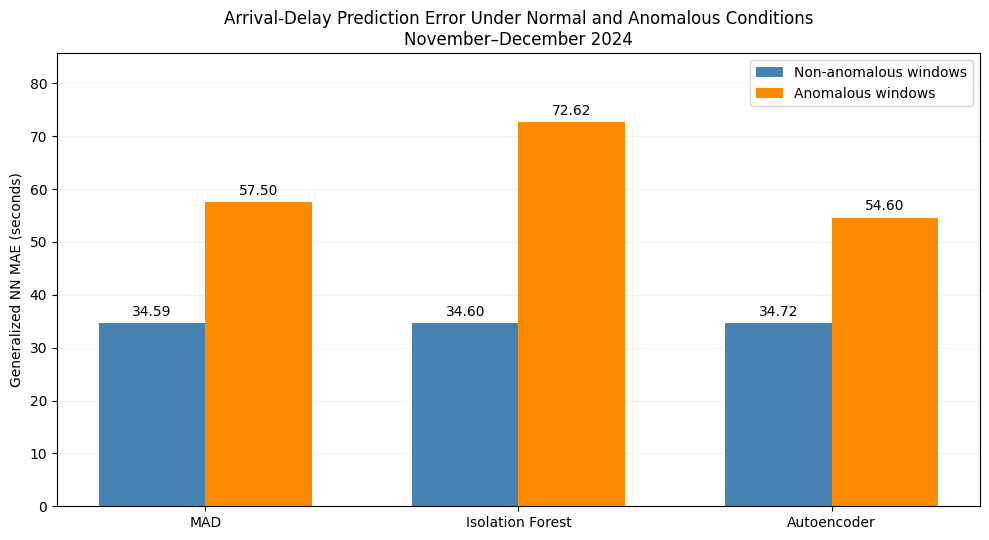

Figure saved to: /content/drive/MyDrive/Project AI in Transportation/bus_delay_prediction/results/anomaly_vs_generalized_nn_mae_2024.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Reshape existing results for visualization
mae_plot = anomaly_prediction_results.pivot(
    index="Detector",
    columns="Condition",
    values="MAE (s)"
)

# Ensure consistent detector ordering
mae_plot = mae_plot.loc[
    ["MAD", "Isolation Forest", "Autoencoder"]
]

x = np.arange(len(mae_plot))
width = 0.34

fig, ax = plt.subplots(figsize=(10, 5.5))

bars_normal = ax.bar(
    x - width / 2,
    mae_plot["Normal"],
    width,
    label="Non-anomalous windows",
    color="steelblue"
)

bars_anomalous = ax.bar(
    x + width / 2,
    mae_plot["Anomalous"],
    width,
    label="Anomalous windows",
    color="darkorange"
)

# Display exact MAE values above bars
ax.bar_label(
    bars_normal,
    fmt="%.2f",
    padding=3,
    fontsize=10
)

ax.bar_label(
    bars_anomalous,
    fmt="%.2f",
    padding=3,
    fontsize=10
)

ax.set_xticks(x)
ax.set_xticklabels(mae_plot.index)

ax.set_ylabel("Generalized NN MAE (seconds)")

ax.set_title(
    "Arrival-Delay Prediction Error Under Normal and Anomalous Conditions\n"
    "November–December 2024"
)

ax.legend()
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

ax.set_ylim(
    0,
    mae_plot.to_numpy().max() * 1.18
)

plt.tight_layout()

figure_path = (
    f"{RESULTS_PATH}/"
    "anomaly_vs_generalized_nn_mae_2024.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", figure_path)

In [ ]:
print("Reconstructed overall MAE by detector:\n")

for detector in anomaly_prediction_results["Detector"].unique():

    rows = anomaly_prediction_results[
        anomaly_prediction_results["Detector"] == detector
    ]

    overall_mae = np.average(
        rows["MAE (s)"],
        weights=rows["Observations"]
    )

    print(f"{detector}: {overall_mae:.6f} seconds")

print("\nPreviously reported NN test MAE: 35.3059 seconds")

Reconstructed overall MAE by detector:

MAD: 35.348298 seconds
Isolation Forest: 35.348298 seconds
Autoencoder: 35.348298 seconds

Previously reported NN test MAE: 35.3059 seconds
